## Session Setup

Every time you start a new Colab session, the virtual machine starts completely
fresh — nothing is in memory, nothing is installed. The first thing we always do
is connect Google Drive, which is where our code and dataset live permanently.


After running this cell you'll see a link asking you to authorize Google Drive
access. Click it, choose your account, copy the code back. You'll see
"Mounted at /content/drive" when it's done.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Path Configuration

We define all the paths we'll use throughout the notebook as variables.
This means if the folder structure ever changes, we only update one place.

CRITICAL: We explicitly unset any environment variables that would point
HuggingFace's model downloader at Google Drive. Models must ALWAYS download
to the VM's local disk (/root/.cache/huggingface/), never to Drive.
Drive has 15GB total. The models are 43GB combined. They cannot fit on Drive.


In [ ]:
# import os
# base = '/content/drive/MyDrive'
# for item in sorted(os.listdir(base)):
#   print(item)
# print("@@@@@@@@in project folder:")
# vla_path = os.path.join(base, 'VLA_Affordance_Project/VLA-affordance')
# for item in sorted(os.listdir(vla_path)):
#   print(item)

In [ ]:
# def folder_gb(path):
#   if not os.path.exists(path):
#     return 0.0
#   total = 0
#   for r,d, files in os.walk(path):
#     for f in files:
#       try:
#         total+=os.path.getsize(os.path.join(r,f))
#       except:
#         pass
#   return total/1e9

# project_dir = '/content/drive/MyDrive/VLA_Affordance_Project'
# repo_dir = os.path.join(project_dir,'VLA-affordance')

# print('DRIVE - VLA_Affordance project:')
# for item in sorted(os.listdir(project_dir)):
#   path = os.path.join(project_dir, item)
#   size = folder_gb(path)
#   print(f"{size:>6.2f}GB {item}")

# print(f"\nDRIVE - VLA-affordance subfolders:")
# for item in sorted(os.listdir(repo_dir)):
#   path = os.path.join(repo_dir,item)
#   size = folder_gb(path)
#   print(f"{size:>6.2f}GB {item}")

# import shutil
# _,used, free = shutil.disk_usage(project_dir)
# print(f"\nDrive total used: {used/1e9:.2f}GB free:{free/1e9:.2f}GB")


The commented cells check files in drive and their size, uncomment and run if you want to check this.


In [ ]:
import os
import sys

project_dir = '/content/drive/MyDrive/VLA_Affordance_Project'
repo_dir = os.path.join(project_dir,'VLA-affordance')
data_path = f"{repo_dir}/data/umd"
figures_path = f"{repo_dir}/results/figures"

for var in ['HF_HOME','TRANSFORMERS_CACHE','HF_HUB_CACHE']:
  if var in os.environ:
    del os.environ[var]
    print(f"Cleared {var}, models will go into VM")

# ── Add repo to Python path so we can import encoder modules ──────
sys.path.insert(0,repo_dir)
# ── Move into repo directory ───────────────────────────────────────
os.chdir(repo_dir)
# ── Create output directories if they don't exist ─────────────────
os.makedirs(f'{figures_path}/hires', exist_ok=True)
os.makedirs(f"{figures_path}/clean", exist_ok=True)

print(f"Repo:    {repo_dir}")
print(f"Data:    {data_path}")
print(f"Figures: {figures_path}")
print(f"Repo exists: {os.path.exists(repo_dir)}")
print(f"Data exists: {os.path.exists(data_path)}")

Repo:    /content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance
Data:    /content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance/data/umd
Figures: /content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance/results/figures
Repo exists: True
Data exists: True


If you see "Repo exists: False" — the Drive mount failed or the folder
structure is different. Check the mount step above.
If you see any "Cleared HF_HOME" messages — good, that means a previous
cell had set it incorrectly and we've fixed it.

## Install Dependencies

The VM starts fresh every session with a base Python environment.
We need to install several packages that aren't pre-installed.

The most important and trickiest install is the custom transformers fork.
The π₀ and π₀.₅ models require a modified version of HuggingFace transformers
with a branch called fix/lerobot_openpi that adds the SigLIP module these
models need. If we install stock transformers, loading π₀ fails with
"SigLIPCheckModule not found".

We install the custom fork FIRST, then lerobot, because lerobot's installer
would otherwise overwrite the custom fork with stock transformers.

This cell takes approximately 3-5 minutes. Run it once per session.

In [ ]:
#step1: remove stock transformers if present
!pip uninstall -y transformers -q
#step2: install the custom fork that supports pi0/pi0.5 SigLIP modules
!pip install git+https://github.com/huggingface/transformers.git@fix/lerobot_openpi -q
#step3: install lerobot, the library that provides pi0  and pi0.5 model loaders
!pip install lerobot==0.4.4 -q
#step4: install scientific computing and visualization libraries
!pip install scikit-learn scipy matplotlib seaborn tqdm -q
#step5: install our repo as a package so its modules are importable
os.chdir(repo_dir)
!pip install -e . -q

#step6: verify the critical imports work
import torch
import transformers
import sklearn
print(f"PyTorch: {torch.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 115.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.0/92.0 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 131.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.3/564.3 kB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.7/67.7 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━

1.   !=> runs teh shell command
2.   -y => says yes to the confirmation prompt
3.   -q => supress verbose output
4.   -e => installs the repo as an ediatble package. Python imports from the actual files rather than a copy, so any changes to the code are immediately reflected.
5.   . => means the current repo directory



You should see PyTorch version, Transformers version, CUDA available: True,
and your GPU name. If CUDA is not available, the runtime wasn't set to GPU —
go to Runtime → Change runtime type → A100.

The transformers version will look unusual (something like 4.x.x.dev) because
it's the development branch, not a stable release. This is expected.

## HuggingFace Authentication

Some models we use are "gated" — they require you to accept a license agreement
on HuggingFace before downloading. PaliGemma is gated. π₀ and π₀.₅ are public
but still load through HuggingFace's infrastructure.

We use Colab's Secrets feature to store the token securely. To set this up:
1. Click the 🔑 key icon in the left sidebar
2. Add new secret: Name = HF_TOKEN, Value = your token from huggingface.co/settings/tokens
3. Make sure the toggle is ON for this notebook

This way the token is never written in code and never accidentally committed to GitHub.

In [ ]:
from google.colab import userdata
from huggingface_hub import login

HF_TOKEN = userdata.get('HF_TOKEN')
login(token=HF_TOKEN)
print("HuggingFace login successful")

HuggingFace login successful


## Health Check

Before running any heavy compute, we verify that everything we need is
actually accessible. This replaces the old 01_setup_encoders.py script
which loaded all 6 models (43GB) just to check shapes.

This check takes under 5 seconds and catches all common setup problems:
missing dataset, missing split file, GPU not available, Drive nearly full.

In [ ]:
import glob
import shutil

print("=" * 50)
print("HEALTH CHECK")
print("=" * 50)

# 1. Dataset check
rgb_files = glob.glob(f'{data_path}/**/*_rgb.jpg', recursive=True)
dataset_ok = len(rgb_files) > 1000
print(f"{'✅' if dataset_ok else '❌'} Dataset: {len(rgb_files)} RGB images found")
if not dataset_ok:
    print("   → Run the dataset download cell")

# 2. Split file check
split_path = f'{data_path}/category_split.txt'
split_ok = os.path.exists(split_path)
print(f"{'✅' if split_ok else '❌'} Split file: {split_path}")
if not split_ok:
    print("   → Run the split file creation cell")

# 3. Reference images check
img_dir = f'{repo_dir}/data/pca_reference_images'
ref_images = os.listdir(img_dir) if os.path.exists(img_dir) else []
print(f"{'✅' if ref_images else '❌'} PCA reference images: {ref_images}")

# 4. GPU check
import torch
gpu_ok = torch.cuda.is_available()
gpu_name = torch.cuda.get_device_name(0) if gpu_ok else "none"
print(f"{'✅' if gpu_ok else '❌'} GPU: {gpu_name}")

# 5. Drive space check
_, _, free = shutil.disk_usage(project_dir)
free_gb = free / 1e9
drive_ok = free_gb > 2.0
print(f"{'✅' if drive_ok else '⚠️'} Drive free: {free_gb:.1f}GB")
if not drive_ok:
    print("   → Run the Drive cleanup cell")

# 6. VM disk check
_, _, vm_free = shutil.disk_usage('/content')
vm_free_gb = vm_free / 1e9
print(f"{'✅' if vm_free_gb > 30 else '⚠️'} VM disk free: {vm_free_gb:.1f}GB")
if vm_free_gb < 30:
    print("   → Run: !rm -rf ~/.cache/huggingface")

print("=" * 50)

HEALTH CHECK
✅ Dataset: 29711 RGB images found
✅ Split file: /content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance/data/umd/category_split.txt
✅ PCA reference images: ['knife.webp', 'mug1.webp', 'mug2.webp', 'scissors-6378708.webp', 'mug_ref.png', 'mug_test.png', 'knife.png', 'scissors.png']
✅ GPU: NVIDIA A100-SXM4-80GB
✅ Drive free: 11.4GB
✅ VM disk free: 205.5GB


All items should show ✅. If anything shows ❌ — fix that specific issue
before proceeding. The most common issue is VM disk space — if under 30GB
free, run !rm -rf ~/.cache/huggingface in a new cell to clear old model
downloads before loading new ones.

# PCA Analysis — Complete Pipeline

This notebook runs PCA on all five encoders across two resolutions,
two image distributions, and all network layers.

Results are organized into four figures:
  Figure 1: Main comparison — all encoders × web + UMD images
  Figure 2: Resolution comparison — 224×224 vs 490×644
  Figure 3: Layer trajectory — PC1 variance vs network depth
  Figure 4: Per-layer colormaps — raw_siglip vs dinov2

Each figure answers a specific question about how training objectives
shape the feature space's geometric structure.

In [ ]:
import os, sys, torch, numpy as np
from PIL import Image
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torchvision.transforms.functional as TF

# ── Paths ──────────────────────────────────────────────────────────
PROJECT_DIR  = '/content/drive/MyDrive/VLA_Affordance_Project'
REPO_DIR     = f'{PROJECT_DIR}/VLA-affordance'
DATA_PATH    = f'{REPO_DIR}/data/umd'
FIGURES_PATH = f'{REPO_DIR}/results/figures'
# IMG_DIR      = f'{REPO_DIR}/data/pca_reference_images'
IMG_DIR = f'{REPO_DIR}/data/pca_reference_images/web'


sys.path.insert(0, REPO_DIR)
os.chdir(REPO_DIR)
os.makedirs(f'{FIGURES_PATH}/pca', exist_ok=True)

# ── Resolution A: low (deployment resolution of π₀) ───────────────
# 224×224 → 16×16 = 256 patches
# This is what π₀ actually uses at inference time
# At this resolution tools occupy only 6-10 patches
LO_H, LO_W     = 224, 224
LO_H_GRID       = LO_H // 14    # 16
LO_W_GRID       = LO_W // 14    # 16
LO_N_PATCHES    = LO_H_GRID * LO_W_GRID  # 256

# ── Resolution B: high (UMD native, used in slides) ────────────────
# 490×644 → 35×46 = 1610 patches
# This matches the 35×46 grid mentioned in the presentation
# At this resolution tools occupy 50-100 patches
HI_H, HI_W     = 490, 644
HI_H_GRID       = HI_H // 14    # 35
HI_W_GRID       = HI_W // 14    # 46
HI_N_PATCHES    = HI_H_GRID * HI_W_GRID  # 1610

# ── PCA config ─────────────────────────────────────────────────────
N_COMPONENTS = 3    # maps to RGB for visualization

# ── Device ─────────────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ── Encoder registry ───────────────────────────────────────────────
# Training trajectory order — this ordering matters for the narrative
# Each value is encoder_type which controls:
#   - which probe layer indices to use
#   - whether to skip the CLS token
#   - whether to pass interpolate_pos_encoding to the model
ENCODERS = {
    "raw_siglip":       "siglip",  # Stage 1: contrastive only
    "paligemma_siglip": "siglip",  # Stage 2: + VLM training
    "pi0_siglip":       "siglip",  # Stage 3: + VLA robot training
    "pi05_siglip":      "siglip",  # Stage 4: + hierarchical VLA
    "dinov2":           "dinov2",  # Reference: self-supervised
}

# ── Probe layer indices per encoder family ─────────────────────────
# These are 4 equally-spaced layers through each network
# SigLIP: 27 layers total → probe at [6, 13, 20, 26]
# DINOv2: 12 layers total → probe at [3, 6, 8, 11]
# Layer 0 in hidden_states is always the patch embedding output
PROBE_LAYERS = {
    "siglip": [6, 13, 20, 26],
    "dinov2": [3, 6, 8, 11],
}

# ── Total hidden states per encoder family ─────────────────────────
# = number of transformer layers + 1 (for the embedding layer at index 0)
N_HIDDEN_STATES = {
    "siglip": 28,   # 1 embedding + 27 transformer layers
    "dinov2": 13,   # 1 embedding + 12 transformer layers
}

print("Configuration loaded:")
print(f"  Low  resolution: {LO_H}×{LO_W} → {LO_H_GRID}×{LO_W_GRID} = {LO_N_PATCHES} patches")
print(f"  High resolution: {HI_H}×{HI_W} → {HI_H_GRID}×{HI_W_GRID} = {HI_N_PATCHES} patches")
print(f"  Device: {DEVICE}")
print(f"  Encoders: {list(ENCODERS.keys())}")

Configuration loaded:
  Low  resolution: 224×224 → 16×16 = 256 patches
  High resolution: 490×644 → 35×46 = 1610 patches
  Device: cuda
  Encoders: ['raw_siglip', 'paligemma_siglip', 'pi0_siglip', 'pi05_siglip', 'dinov2']


In [ ]:
import os
from PIL import Image

web_dir = f'{REPO_DIR}/data/pca_reference_images/web'
os.makedirs(web_dir, exist_ok=True)  # creates folder if missing
print(f"Web dir: {web_dir}")
print(f"Exists: {os.path.exists(web_dir)}")
print(f"Contents: {os.listdir(web_dir)}")

Web dir: /content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance/data/pca_reference_images/web
Exists: True
Contents: []


In [ ]:
from google.colab import files

print("Select your image files to upload (mug_ref, mug_test, knife)...")
print("You can select multiple files at once with Ctrl+click")
uploaded = files.upload()

# Save each uploaded file directly to the web folder
for filename, data in uploaded.items():
    # Clean the filename — remove any path prefix
    clean_name = os.path.basename(filename)
    save_path = f'{web_dir}/{clean_name}'
    with open(save_path, 'wb') as f:
        f.write(data)
    print(f"✅ Saved: {clean_name}")

print(f"\nContents of web folder:")
for f in sorted(os.listdir(web_dir)):
    size_kb = os.path.getsize(f'{web_dir}/{f}') / 1e3
    print(f"  {f}: {size_kb:.1f}KB")

Select your image files to upload (mug_ref, mug_test, knife)...
You can select multiple files at once with Ctrl+click


Saving knife.webp to knife (1).webp
Saving mug1.webp to mug1 (1).webp
Saving mug2.webp to mug2 (1).webp
Saving scissors.webp to scissors.webp
✅ Saved: knife (1).webp
✅ Saved: mug1 (1).webp
✅ Saved: mug2 (1).webp
✅ Saved: scissors.webp

Contents of web folder:
  knife (1).webp: 5.3KB
  mug1 (1).webp: 4.2KB
  mug2 (1).webp: 7.6KB
  scissors.webp: 8.9KB


In [ ]:
# Run this once in Colab to properly convert webp files
from PIL import Image
import os

web_dir = f'{REPO_DIR}/data/pca_reference_images/web'
for fname in os.listdir(web_dir):
    if fname.endswith('.webp') or fname.endswith('.png'):
        path = f'{web_dir}/{fname}'
        img = Image.open(path).convert("RGBA")
        bg  = Image.new("RGB", img.size, (255, 255, 255))
        bg.paste(img, mask=img.split()[3])
        # Save as proper PNG regardless of original format
        out_name = fname.rsplit('.', 1)[0] + '.png'
        bg.save(f'{web_dir}/{out_name}', 'PNG')
        print(f"✅ Converted: {fname} → {out_name}")

✅ Converted: knife (1).webp → knife (1).png
✅ Converted: mug1 (1).webp → mug1 (1).png
✅ Converted: mug2 (1).webp → mug2 (1).png
✅ Converted: scissors.webp → scissors.png


## Load Reference and Test Images

We use two sets of images:

1. Web images — clean white/black backgrounds, objects fill the frame.
   These are ideal for seeing the encoder's geometric understanding because
   the background is simple and the object is large. We use these to
   establish what each encoder's PCA structure looks like under ideal conditions.

2. UMD images — real tabletop scenes with the blue board, wooden frame,
   and small tools in the center. These are the actual images used in
   linear probing. Running PCA on these shows what the encoder sees
   during the actual task.

For each set we have:
- 1 reference image: PCA axes are FITTED on this image
- 3 test images: these are PROJECTED onto the axes fitted from reference

The reference should always be a mug because the proposal uses mug as
the canonical reference object, following Zhang et al.
## Image Loading

We use two image sets:

**Web images** — clean backgrounds, objects fill the frame.
  Purpose: ideal conditions for seeing encoder geometry without
  background interference. Close to SigLIP's internet training distribution.
  
**UMD images** — tabletop scenes with blue board and wooden frame.
  Purpose: actual evaluation domain. What encoders see during linear probing.
  Closer to π₀'s robot workspace training distribution.

Both sets use the same object categories (mug, knife, scissors) so
cross-set comparison is meaningful.

We load images at BOTH resolutions so we can run the resolution comparison
without reloading images mid-analysis.

In [ ]:
# First see exactly what's in the folder
print("Actual files in web folder:")
for f in sorted(os.listdir(web_dir)):
    print(f"  '{f}'")

Actual files in web folder:
  'knife (1).png'
  'knife (1).webp'
  'mug1 (1).png'
  'mug1 (1).webp'
  'mug2 (1).png'
  'mug2 (1).webp'
  'scissors.png'
  'scissors.webp'


✅ All images loaded at correct sizes
   High res: 490×644  (['mug_ref', 'mug_test', 'knife'] × 2 sets)
   Low  res: 224×224  (['mug_ref', 'mug_test', 'knife'] × 2 sets)


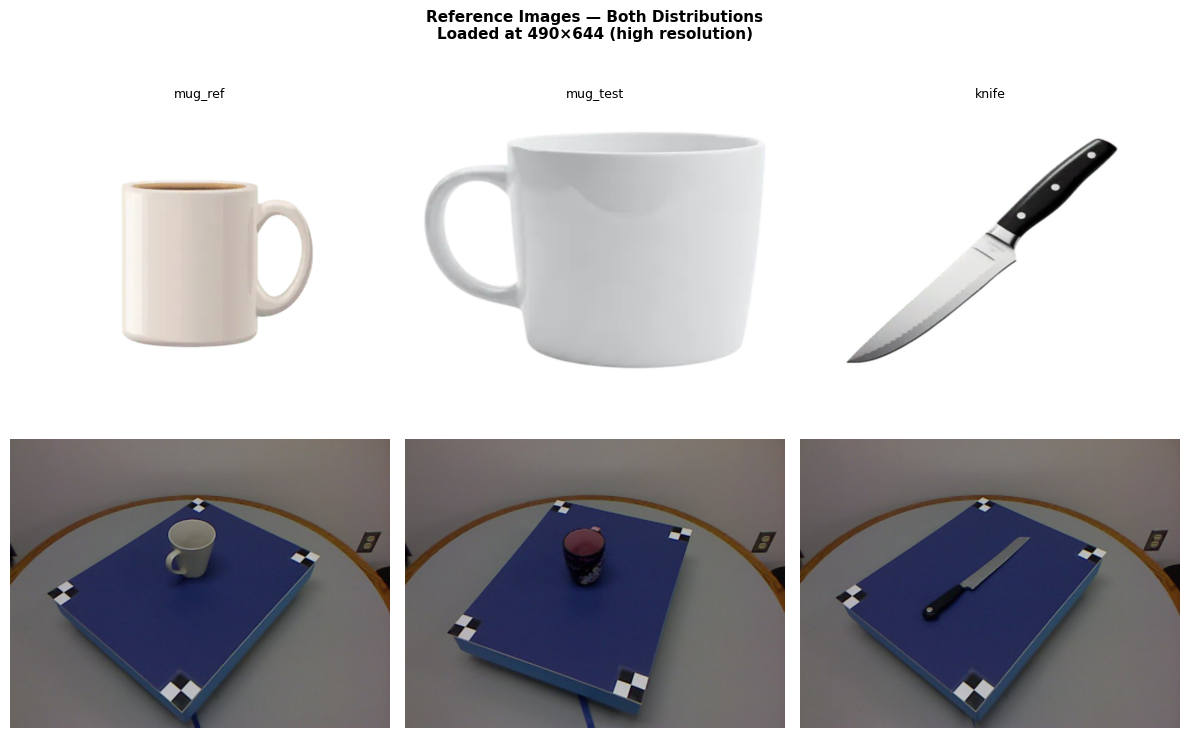

✅ Saved reference image overview


In [ ]:
def load_img(path, target_h, target_w):
    """
    Load image, handle transparency by pasting onto white background,
    then resize to target dimensions.
    """
    img = Image.open(path).convert("RGBA")

    # Create white background and paste image onto it
    # This replaces transparent pixels with white instead of black
    background = Image.new("RGB", img.size, (255, 255, 255))
    background.paste(img, mask=img.split()[3])  # use alpha channel as mask

    # Resize to target
    return background.resize((target_w, target_h), Image.LANCZOS)

# ── Web images — loaded at both resolutions ────────────────────────
# These are product-style photos with clean backgrounds
# mug1 = reference (PCA fitted on this)
# mug2, knife = same-category and cross-category tests
web_images_hi = {
    "mug_ref":  load_img(f'{IMG_DIR}/mug1 (1).png',  HI_H, HI_W),
    "mug_test": load_img(f'{IMG_DIR}/mug2 (1).png',  HI_H, HI_W),
    "knife":    load_img(f'{IMG_DIR}/knife (1).png',  HI_H, HI_W),
}
web_images_lo = {
    "mug_ref":  load_img(f'{IMG_DIR}/mug1 (1).png',  LO_H, LO_W),
    "mug_test": load_img(f'{IMG_DIR}/mug2 (1).png',  LO_H, LO_W),
    "knife":    load_img(f'{IMG_DIR}/knife (1).png',  LO_H, LO_W),
}

# ── UMD images — loaded at both resolutions ────────────────────────
# These are overhead tabletop scenes from the actual evaluation dataset
# Frame 50 chosen for each object: good 45° side view showing object clearly
# mug_01 = reference, mug_02 and knife_01 = test images
umd_images_hi = {
    "mug_ref":  load_img(
        f'{DATA_PATH}/part-affordance-dataset/tools/mug_01/mug_01_00000050_rgb.jpg',
        HI_H, HI_W),
    "mug_test": load_img(
        f'{DATA_PATH}/part-affordance-dataset/tools/mug_02/mug_02_00000050_rgb.jpg',
        HI_H, HI_W),
    "knife":    load_img(
        f'{DATA_PATH}/part-affordance-dataset/tools/knife_01/knife_01_00000050_rgb.jpg',
        HI_H, HI_W),
}
umd_images_lo = {
    "mug_ref":  load_img(
        f'{DATA_PATH}/part-affordance-dataset/tools/mug_01/mug_01_00000050_rgb.jpg',
        LO_H, LO_W),
    "mug_test": load_img(
        f'{DATA_PATH}/part-affordance-dataset/tools/mug_02/mug_02_00000050_rgb.jpg',
        LO_H, LO_W),
    "knife":    load_img(
        f'{DATA_PATH}/part-affordance-dataset/tools/knife_01/knife_01_00000050_rgb.jpg',
        LO_H, LO_W),
}

# ── Verify sizes ───────────────────────────────────────────────────
for name, img in web_images_hi.items():
    assert img.size == (HI_W, HI_H), f"Wrong size: {name} {img.size}"
for name, img in web_images_lo.items():
    assert img.size == (LO_W, LO_H), f"Wrong size: {name} {img.size}"
print("✅ All images loaded at correct sizes")
print(f"   High res: {HI_H}×{HI_W}  ({list(web_images_hi.keys())} × 2 sets)")
print(f"   Low  res: {LO_H}×{LO_W}  ({list(web_images_lo.keys())} × 2 sets)")

# ── Quick visual check of what we're working with ─────────────────
# Show both image sets at high resolution so we can see
# the distribution difference between web and UMD images
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
row_labels = ['Web images\n(clean background)', 'UMD images\n(tabletop scene)']
col_labels = list(web_images_hi.keys())

for col_i, key in enumerate(col_labels):
    # Top row: web images
    axes[0][col_i].imshow(web_images_hi[key])
    axes[0][col_i].set_title(key, fontsize=9)
    axes[0][col_i].axis('off')

    # Bottom row: UMD images
    axes[1][col_i].imshow(umd_images_hi[key])
    axes[1][col_i].axis('off')

for row_i, label in enumerate(row_labels):
    axes[row_i][0].set_ylabel(label, fontsize=9,
                              rotation=90, labelpad=8, va='center')

plt.suptitle(f'Reference Images — Both Distributions\n'
             f'Loaded at {HI_H}×{HI_W} (high resolution)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/pca/00_reference_images.png',
            bbox_inches='tight', dpi=100)
plt.show()
print("✅ Saved reference image overview")

## Core Extraction Functions

Three functions form the extraction pipeline:

extract_hires_hidden(model, processor, image, device, encoder_type, target_h, target_w)
  → Takes a PIL image, runs it through the encoder at target resolution
  → Returns ALL hidden states (one tensor per layer)
  → Works for both resolutions by accepting target_h, target_w as arguments

hidden_states_to_layer_flat(hidden_states, encoder_type, layer_idx)
  → Extracts ONE specific layer from hidden states
  → Returns (N_patches, feature_dim) numpy array
  → Handles CLS token skipping for DINOv2

hidden_states_to_fused_flat(hidden_states, encoder_type)  
  → Extracts the 4 probe layers and concatenates them
  → Returns (N_patches, fused_feature_dim) numpy array
  → This is what we used before — now separated into its own function

Keeping these three separate lets us run both per-layer and fused analysis
from the same hidden states extraction, without re-running the model.

In [ ]:
def extract_hidden(model, processor, image, device, encoder_type,
                   target_h, target_w):
    """
    Extract all hidden states from an encoder at specified resolution.

    This is the ONLY function that touches the GPU and runs the model.
    All other functions operate on CPU numpy arrays.

    Args:
        model:        loaded HuggingFace model (SiglipVisionModel or Dinov2Model)
        processor:    HuggingFace image processor for this model
        image:        PIL Image — should already be at target_h × target_w
        device:       "cuda" or "cpu"
        encoder_type: "siglip" or "dinov2"
        target_h:     target height in pixels (must be divisible by 14)
        target_w:     target width in pixels (must be divisible by 14)

    Returns:
        tuple of tensors — one per layer including embedding layer
        SigLIP: 28 tensors each (1, N_patches, 1152)
                N_patches = (target_h//14) × (target_w//14)
        DINOv2: 13 tensors each (1, N_patches+1, 768)
                +1 because DINOv2 includes CLS token at index 0
    """
    # ── Override processor output size ─────────────────────────────
    # Different processor classes store size differently.
    # We set all relevant attributes to ensure the override takes effect.

    processor.size = {"height": target_h, "width": target_w}

    # DINOv2 processor has crop_size which takes priority over size
    if hasattr(processor, 'crop_size'):
        processor.crop_size = {"height": target_h, "width": target_w}

    # DINOv2 processor center-crops by default — this would crop
    # our rectangular image to a square, losing content
    if hasattr(processor, 'do_center_crop'):
        processor.do_center_crop = False

    # ── Preprocess image ───────────────────────────────────────────
    # processor applies: resize → normalize (subtract mean, divide std)
    # → convert to PyTorch tensor
    inputs = processor(images=[image], return_tensors="pt").to(device)
    # inputs['pixel_values'] shape: (1, 3, target_h, target_w)

    # ── Fallback: manual resize if processor ignored our override ──
    # Some processor versions have bugs where size override is ignored
    actual_h, actual_w = inputs['pixel_values'].shape[-2:]
    if (actual_h, actual_w) != (target_h, target_w):
        inputs['pixel_values'] = TF.resize(
            inputs['pixel_values'], [target_h, target_w])
        print(f"    ↳ Manual resize: {actual_h}×{actual_w} → {target_h}×{target_w}")

    # ── Forward pass ───────────────────────────────────────────────
    # torch.no_grad() disables gradient tracking — saves ~50% memory
    # We don't need gradients for feature extraction (only for training)
    with torch.no_grad():
        if encoder_type == "siglip":
            outputs = model(
                **inputs,
                return_dict=True,
                output_hidden_states=True,
                # SigLIP was trained at 224×224 (256 patches)
                # At 490×644 we have 1610 patches — positional embeddings
                # must be interpolated from 256 positions to 1610 positions
                interpolate_pos_encoding=True
            )
        else:  # dinov2
            outputs = model(
                **inputs,
                return_dict=True,
                output_hidden_states=True
                # DINOv2 was designed for variable resolution —
                # handles positional embedding scaling internally
            )

    return outputs.hidden_states


def layer_to_flat(hidden_states, encoder_type, layer_idx):
    """
    Extract ONE layer's patch features as a flat numpy array.

    Used for per-layer PCA analysis — call this for each layer
    you want to examine individually.

    Args:
        hidden_states: tuple from extract_hidden
        encoder_type:  "siglip" or "dinov2"
        layer_idx:     which layer to extract (0 = embedding output,
                       1..27 = transformer layers for SigLIP,
                       1..12 = transformer layers for DINOv2)

    Returns:
        numpy array (N_patches, feature_dim)
        SigLIP: (N_patches, 1152) — e.g. (1610, 1152) at high res
        DINOv2: (N_patches, 768)  — CLS token already removed
    """
    h = hidden_states[layer_idx]
    # h shape: (1, N_patches, feature_dim) for SigLIP
    #          (1, N_patches+1, feature_dim) for DINOv2 (includes CLS)

    if encoder_type == "siglip":
        # SigLIP has no CLS token — all tokens are spatial patch tokens
        # [0] selects batch item 0 (we always process one image at a time)
        return h[0].cpu().numpy()     # (N_patches, 1152)
    else:
        # DINOv2 prepends a CLS token at index 0
        # [0]  = batch item 0
        # [1:] = skip index 0 (CLS token), keep all patch tokens
        # [:]  = all feature dimensions
        return h[0, 1:, :].cpu().numpy()  # (N_patches, 768)


def fused_to_flat(hidden_states, encoder_type):
    """
    Extract 4 probe layers and concatenate into one feature matrix.

    This is the multi-layer fusion used in linear probing and the
    main PCA analysis. Concatenating 4 layers gives the probe access
    to features at multiple levels of abstraction simultaneously.

    Layer selection rationale:
      SigLIP [6, 13, 20, 26]: equally spaced through 27 layers
        Layer 6  ≈ 22% depth → low-level: edges, textures
        Layer 13 ≈ 48% depth → mid-level: parts, local geometry
        Layer 20 ≈ 74% depth → high-level: semantic regions
        Layer 26 ≈ 96% depth → near-final: task-relevant features

      DINOv2 [3, 6, 8, 11]: equally spaced through 12 layers
        Layer 3  ≈ 25% depth → low-level features
        Layer 6  ≈ 50% depth → mid-level parts
        Layer 8  ≈ 67% depth → high-level structure
        Layer 11 ≈ 92% depth → final semantic representation

    Args:
        hidden_states: tuple from extract_hidden
        encoder_type:  "siglip" or "dinov2"

    Returns:
        numpy array (N_patches, fused_dim)
        SigLIP: (N_patches, 4608)  — 4 × 1152
        DINOv2: (N_patches, 3072)  — 4 × 768
    """
    probe_indices = PROBE_LAYERS[encoder_type]

    # Extract each probe layer using layer_to_flat
    # Each returns (N_patches, feature_dim) numpy array
    layers = [
        torch.from_numpy(layer_to_flat(hidden_states, encoder_type, i))
        for i in probe_indices
    ]
    # torch.from_numpy converts back to tensor for cat operation
    # dim=-1 concatenates along the feature dimension (last dim)
    # Each: (N_patches, 1152) → After cat: (N_patches, 4608) for SigLIP

    fused = torch.cat(layers, dim=-1)
    return fused.numpy()    # (N_patches, fused_dim)

These two functions are the core of the pipeline. Every encoder goes through
exactly these two functions — the only difference is encoder_type="siglip"
vs encoder_type="dinov2" which controls:
  1. Whether to interpolate positional embeddings
  2. Which layer indices to probe
  3. Whether to skip the CLS token

The output of hidden_to_flat is always a (N_patches, C_fused) numpy array
regardless of which encoder — PCA sees the same shape every time.

The `fused_to_flat` function is crucial for creating the combined feature representation used in the main PCA analysis. It performs the following steps:

1.  **Selects Probe Layers**: It first identifies the specific layers to be used for fusion, based on the `encoder_type` (e.g., `siglip` or `dinov2`). These `PROBE_LAYERS` are pre-defined as equally-spaced layers through the network.
2.  **Extracts Individual Layer Features**: For each selected probe layer, it calls `layer_to_flat` to extract the patch features. This step ensures that the features for each layer are converted into a flat NumPy array of shape `(N_patches, feature_dim)`, and importantly, handles the removal of the CLS token for DINOv2 models.
3.  **Converts to PyTorch Tensors**: The extracted NumPy arrays for each layer are then converted back into PyTorch tensors. This is necessary because `torch.cat` (PyTorch's concatenation function) operates on tensors.
4.  **Concatenates Along Feature Dimension**: The core of the fusion process happens here. `torch.cat(layers, dim=-1)` takes the list of layer tensors and concatenates them along the *last dimension* (`dim=-1`). This means that if each layer's features are `(N_patches, feature_dim)`, concatenating four such layers will result in a single tensor of shape `(N_patches, 4 * feature_dim)`.
    *   For **SigLIP** (feature_dim = 1152), the fused dimension becomes `4 * 1152 = 4608`.
    *   For **DINOv2** (feature_dim = 768), the fused dimension becomes `4 * 768 = 3072`.
5.  **Returns Fused NumPy Array**: Finally, the resulting fused tensor is converted back into a NumPy array and returned. This `(N_patches, fused_feature_dim)` array represents a richer feature vector for each image patch, combining information from multiple levels of the encoder's hierarchy.

After `fused_to_flat` creates the `(N_patches, fused_feature_dim)` array, it's passed directly to the `PCA` model. Let's consider the SigLIP example:

1.  **Input to PCA**: The `ref_flat` (or `test_flat`) array, which is the output of `fused_to_flat`, will have a shape of `(N_patches, 4608)` for SigLIP. `N_patches` is the total number of spatial patches in the image grid (e.g., 1610 patches for a 490x644 image).

2.  **PCA Fitting**: The `PCA` object is initialized with `n_components=3` (meaning we want the top 3 principal components). When `pca.fit(ref_flat)` is called:
    *   PCA treats each row of `ref_flat` as a single data point in a 4608-dimensional space. There are `N_patches` such data points.
    *   It then finds the 3 orthogonal directions (principal components) in this 4608-dimensional space that capture the most variance among these `N_patches` feature vectors.

3.  **PCA Projection**: Once `pca` is fitted, `pca.transform(ref_flat)` (or `pca.transform(test_flat)`) is used to project the original high-dimensional feature vectors onto these 3 principal components.
    *   The output of `pca.transform` is an array of shape `(N_patches, 3)`. Each row now represents a patch, and its 3 columns are its coordinates along PC1, PC2, and PC3 respectively.

4.  **Reshaping for Visualization**: Finally, this `(N_patches, 3)` array is reshaped back into a 2D spatial grid corresponding to the original image's patch layout:
    *   `reshape(H_grid, W_grid, N_COMPONENTS)` converts the `(N_patches, 3)` array into a `(H_grid, W_grid, 3)` array. For a 490x644 image, this would be `(35, 46, 3)`.
    *   This `(H_grid, W_grid, 3)` array is then normalized and converted to an RGB image for visualization, where each channel (Red, Green, Blue) corresponds to one of the principal components (PC1, PC2, PC3).

## PCA for One Encoder

This function runs the complete PCA pipeline for a single encoder on
a single set of images. It:
1. Loads the encoder model from disk into GPU memory
2. Extracts features from the reference image
3. Fits PCA on those reference features  
4. Projects the reference and all test images onto the PCA axes
5. Deletes the model from GPU memory to free space for the next encoder

The function returns numpy arrays of shape (H_grid, W_grid, 3) for
each image — ready to display as a colormap image.

Why fit PCA on the reference only?
PCA finds directions of variation within the reference image's patches.
If we fit on all images combined, the axes would capture variation BETWEEN
images (e.g., mug vs knife) rather than variation WITHIN the reference
object (e.g., handle vs body). We want the PCA subspace to capture the
geometry of the reference object, then see how other objects project into it.

## PCA Runner Functions

Two runner functions built on top of the extraction functions:

run_pca_fused — runs PCA on the 4-layer fused features
  Used for: Figure 1 (main comparison), Figure 2 (resolution comparison)
  
run_pca_per_layer — runs PCA on each individual layer separately
  Used for: Figure 3 (variance trajectory), Figure 4 (per-layer colormaps)

Both functions:
  - Load the model once
  - Extract hidden states once per image
  - Run all PCA operations from those hidden states
  - Delete the model before returning
  
This means for per-layer analysis we don't re-run the model for each layer —
we extract all hidden states in one forward pass and then run PCA
on each layer's slice of those hidden states.

In [ ]:
def run_pca_fused(encoder_name, encoder_type, ref_image, test_images,
                  target_h, target_w):
    """
    Run PCA on the 4-layer FUSED features for one encoder.

    This is the main analysis function — produces results for
    Figure 1 (encoder comparison) and Figure 2 (resolution comparison).

    Args:
        encoder_name:  e.g. "raw_siglip", "dinov2"
        encoder_type:  "siglip" or "dinov2"
        ref_image:     PIL Image — PCA axes are FITTED on this
        test_images:   dict of PIL Images — PROJECTED onto ref axes
        target_h:      resolution height (224 or 490)
        target_w:      resolution width (224 or 644)

    Returns dict with keys:
        "ref_proj":    (H_grid, W_grid, 3) — reference PCA projection
        "test_projs":  dict key→(H_grid, W_grid, 3) — one per test image
        "var_ratios":  (3,) — explained variance for PC1, PC2, PC3
        "pca":         fitted PCA object (for re-use if needed)
    """
    h_grid = target_h // 14
    w_grid = target_w // 14
    # ^ compute grid dimensions dynamically from target resolution
    #   so this function works for both 224×224 and 490×644

    print(f"\n{'─'*50}")
    print(f"  {encoder_name} | {target_h}×{target_w} | fused layers")
    print(f"  Grid: {h_grid}×{w_grid} = {h_grid*w_grid} patches")
    print(f"{'─'*50}")

    # ── Load encoder ───────────────────────────────────────────────
    from encoders.feature_extractor import UnifiedFeatureExtractor
    ext       = UnifiedFeatureExtractor(encoder_name, device=DEVICE)
    model     = ext.model
    processor = ext.processor
    print(f"  GPU: {torch.cuda.memory_allocated()/1e9:.1f}GB used after load")

    # ── Extract reference features ─────────────────────────────────
    # Run one forward pass → get all hidden states
    # Then fuse the probe layers into one feature matrix
    ref_hidden = extract_hidden(
        model, processor, ref_image, DEVICE, encoder_type,
        target_h, target_w)
    ref_flat = fused_to_flat(ref_hidden, encoder_type)
    # ref_flat: (N_patches, fused_dim) e.g. (1610, 4608)
    print(f"  Reference feature matrix: {ref_flat.shape}")

    # ── Fit PCA on reference patches ──────────────────────────────
    # svd_solver='randomized': uses approximate SVD
    # Much faster than exact SVD for large matrices
    # For (1610, 4608) the approximation error is negligible
    pca = PCA(n_components=N_COMPONENTS, svd_solver='randomized')
    pca.fit(ref_flat)
    # After fitting:
    #   pca.components_: (3, fused_dim) — the 3 principal directions
    #   pca.explained_variance_ratio_: (3,) — variance fraction per component
    #   pca.mean_: (fused_dim,) — mean subtracted before projection
    print(f"  Variance ratios: {pca.explained_variance_ratio_.round(3)}")

    # ── Project reference ──────────────────────────────────────────
    # pca.transform: subtracts mean, computes dot product with components
    # (N_patches, fused_dim) → (N_patches, 3) → (h_grid, w_grid, 3)
    ref_proj = pca.transform(ref_flat).reshape(h_grid, w_grid, N_COMPONENTS)

    # ── Project each test image ────────────────────────────────────
    # Use the SAME fitted pca — test patches are projected into
    # the coordinate system defined by the reference object
    test_projs = {}
    for img_name, test_img in test_images.items():
        test_hidden = extract_hidden(
            model, processor, test_img, DEVICE, encoder_type,
            target_h, target_w)
        test_flat = fused_to_flat(test_hidden, encoder_type)
        test_projs[img_name] = (
            pca.transform(test_flat).reshape(h_grid, w_grid, N_COMPONENTS)
        )
        print(f"  Projected: {img_name}")

    # ── Free GPU memory ────────────────────────────────────────────
    del ext, model, processor
    torch.cuda.empty_cache()
    print(f"  GPU: {torch.cuda.memory_allocated()/1e9:.1f}GB after cleanup")
    print(f"  ✅ done")

    return {
        "ref_proj":   ref_proj,
        "test_projs": test_projs,
        "var_ratios": pca.explained_variance_ratio_,
        "pca":        pca,
    }


def run_pca_per_layer(encoder_name, encoder_type, ref_image, test_images,
                      target_h, target_w):
    """
    Run PCA on EVERY individual layer for one encoder.

    Used for Figure 3 (variance trajectory) and Figure 4 (per-layer colormaps).

    Key difference from run_pca_fused:
      - We extract hidden states ONCE per image (same as fused)
      - Then run PCA separately for each layer index
      - Each layer's PCA is fitted independently on ref patches
      - This means we get a separate PCA subspace per layer

    Args: same as run_pca_fused

    Returns dict with keys:
        layer_idx (int) → {
            "var_ratios":  (3,) — PC1/PC2/PC3 variance for this layer
            "ref_proj":    (H_grid, W_grid, 3) — reference projection
            "test_projs":  dict key→(H_grid, W_grid, 3) — test projections
        }
    """
    h_grid    = target_h // 14
    w_grid    = target_w // 14
    n_layers  = N_HIDDEN_STATES[encoder_type]
    # ^ total hidden states including embedding layer (index 0)

    print(f"\n{'─'*50}")
    print(f"  {encoder_name} | {target_h}×{target_w} | ALL {n_layers} layers")
    print(f"{'─'*50}")

    # ── Load encoder ───────────────────────────────────────────────
    from encoders.feature_extractor import UnifiedFeatureExtractor
    ext       = UnifiedFeatureExtractor(encoder_name, device=DEVICE)
    model     = ext.model
    processor = ext.processor

    # ── Extract hidden states for ALL images in ONE pass each ──────
    # We extract and store all hidden states on CPU as numpy arrays
    # before running any PCA — this way we only run the model once
    # per image regardless of how many layers we analyze

    print(f"  Extracting reference hidden states...")
    ref_hidden = extract_hidden(
        model, processor, ref_image, DEVICE, encoder_type,
        target_h, target_w)
    # ref_hidden: tuple of n_layers tensors, each (1, N_patches[+1], dim)
    # Keep on GPU for now — we'll extract layers one at a time below

    test_hiddens = {}
    for img_name, test_img in test_images.items():
        print(f"  Extracting hidden states: {img_name}...")
        test_hiddens[img_name] = extract_hidden(
            model, processor, test_img, DEVICE, encoder_type,
            target_h, target_w)

    # ── Free model from GPU — no longer needed ─────────────────────
    # We have all hidden states extracted — model can be deleted now
    # Hidden states are on CPU (we called .cpu() in layer_to_flat)
    del ext, model, processor
    torch.cuda.empty_cache()
    print(f"  Model freed. Running per-layer PCA on CPU...")

    # ── Run PCA for each layer ─────────────────────────────────────
    layer_results = {}

    for layer_idx in range(n_layers):
        # Extract this layer's features for reference image
        # layer_to_flat handles CLS skipping and cpu() conversion
        ref_layer_flat = layer_to_flat(ref_hidden, encoder_type, layer_idx)
        # ref_layer_flat: (N_patches, feature_dim) e.g. (1610, 1152)

        # Fit PCA on reference patches for this layer
        pca = PCA(n_components=N_COMPONENTS, svd_solver='randomized')
        pca.fit(ref_layer_flat)

        # Project reference
        ref_proj = (pca.transform(ref_layer_flat)
                       .reshape(h_grid, w_grid, N_COMPONENTS))

        # Project each test image
        test_projs = {}
        for img_name, test_hidden in test_hiddens.items():
            test_layer_flat = layer_to_flat(
                test_hidden, encoder_type, layer_idx)
            test_projs[img_name] = (
                pca.transform(test_layer_flat)
                   .reshape(h_grid, w_grid, N_COMPONENTS)
            )

        layer_results[layer_idx] = {
            "var_ratios":  pca.explained_variance_ratio_,
            "ref_proj":    ref_proj,
            "test_projs":  test_projs,
        }

        # Progress every 5 layers
        if layer_idx % 5 == 0 or layer_idx == n_layers - 1:
            pc1 = pca.explained_variance_ratio_[0]
            print(f"  Layer {layer_idx:2d}/{n_layers-1}: PC1={pc1:.3f}")

    print(f"  ✅ {encoder_name} per-layer PCA complete")
    return layer_results

This function is the heart of the pipeline. Notice what it does NOT do:
- It does NOT save features to disk
- It does NOT read from any cache
- It loads the model, extracts features, runs PCA, and returns results —
  all in memory

The returned arrays (ref_proj, test_projs) are tiny:
- ref_proj: (35, 46, 3) × 4 bytes = ~19KB
- Each test_proj: same ~19KB
Total memory for all 5 encoders × 4 images = well under 1MB

The model weights are what's large (3-14GB per encoder) — and we delete
each one before loading the next. Peak GPU usage is one model at a time.

## Run All PCA Analyses

We run four separate analyses, each stored in its own results dictionary.
All analyses use the mug as reference — PCA axes are fitted on mug patches
and test images (other mug instance + knife) are projected onto those axes.

Analysis 1: fused features, high resolution, web images
Analysis 2: fused features, high resolution, UMD images  
Analysis 3: fused features, low resolution, web images (for resolution comparison)
Analysis 4: per-layer features, high resolution, web images (for trajectory)

Analyses 1-3 run all 5 encoders.
Analysis 4 runs only raw_siglip, pi0_siglip, dinov2 — the three
most contrasting points in the training trajectory.

Each encoder is loaded, used, and deleted before the next loads.
Peak GPU RAM = 14.5GB (π₀.₅) — well within A100's 80GB.

In [ ]:
def to_rgb(proj):
    """
    Convert PCA projection array to displayable RGB image.

    Args:
        proj: (H_grid, W_grid, 3) numpy array of raw PCA coordinates
              Values can be any real number — not bounded to [0,1]

    Returns:
        (H_grid, W_grid, 3) float32 array with values in [0, 1]
        Ready for matplotlib's imshow
    """
    rgb = proj.copy().astype(np.float32)

    for c in range(3):
        # For each channel (PC1→R, PC2→G, PC3→B):
        lo = rgb[:, :, c].min()   # minimum value across all patches
        hi = rgb[:, :, c].max()   # maximum value across all patches

        # Normalize to [0, 1]: subtract min, divide by range
        # After this: min patch gets 0.0, max patch gets 1.0
        # All others are linearly interpolated between 0 and 1
        if hi - lo > 1e-6:
            # Normal case: there is variance in this channel
            rgb[:, :, c] = (rgb[:, :, c] - lo) / (hi - lo)
        else:
            # Edge case: all patches project to same value on this component
            # (almost zero variance) — set to 0.5 (mid gray for this channel)
            rgb[:, :, c] = 0.5

    return rgb


def visualize_grid(results, source_images, row_labels, title, save_path):
    """
    Create and save a grid showing source images and PCA projections.

    Layout:
        Columns: [source image] [encoder1] [encoder2] ... [encoderN]
        Rows:    one per image (reference + test images)

    Args:
        results:       dict mapping encoder_name → (ref_proj, test_projs, var_ratios)
        source_images: list of PIL Images [ref, test0, test1, test2]
        row_labels:    list of strings labeling each row
        title:         plot title string
        save_path:     full path to save the PNG
    """
    encoders   = list(results.keys())
    n_rows     = len(source_images)        # 4: reference + 3 tests
    n_cols     = len(encoders) + 1         # encoders + 1 source column

    # figsize in inches: width = 3 inches per column, height = 3.5 per row
    fig, axes = plt.subplots(
        nrows=n_rows, ncols=n_cols,
        figsize=(3 * n_cols, 3.5 * n_rows)
    )

    for row_idx, (label, src_img) in enumerate(
            zip(row_labels, source_images)):

        # ── Column 0: source image ─────────────────────────────────
        ax = axes[row_idx][0]
        ax.imshow(src_img)
        ax.axis('off')   # hide axis ticks and labels
        # Set row label on the left side using ylabel
        ax.set_ylabel(label, fontsize=7, rotation=90,
                     labelpad=6, va='center')
        if row_idx == 0:
            ax.set_title('source', fontsize=8, fontweight='bold')

        # ── Columns 1+: PCA projection for each encoder ───────────
        for col_idx, enc_name in enumerate(encoders):
            ax = axes[row_idx][col_idx + 1]   # +1 to skip source column

            ref_proj, test_projs, var_ratios = results[enc_name]

            # Row 0 = reference image, rows 1+ = test images
            proj = ref_proj if row_idx == 0 else test_projs[row_idx - 1]

            # interpolation='nearest' shows crisp pixel boundaries
            # (no blurring between patches)
            # aspect='auto' lets matplotlib stretch to fill the subplot
            ax.imshow(to_rgb(proj), interpolation='nearest', aspect='auto')
            ax.axis('off')

            # Column headers only on first row (reference image)
            if row_idx == 0:
                ax.set_title(
                    f'{enc_name}\nPC1={var_ratios[0]:.3f}',
                    fontsize=7, fontweight='bold'
                )

    plt.suptitle(title, fontsize=10, fontweight='bold', y=1.01)
    plt.tight_layout(pad=0.4)

    # Save to Drive — this is the only file that persists after session ends
    plt.savefig(save_path, bbox_inches='tight', dpi=120)
    plt.show()
    print(f"✅ Saved: {save_path}")


def print_variance_table(results):
    """Print a comparison table of PCA variance ratios across encoders."""
    print(f"\n{'='*65}")
    print(f"{'Encoder':<22} {'PC1':>6} {'PC2':>6} {'PC3':>6}  Interpretation")
    print(f"{'='*65}")
    for enc_name, (_, _, ratios) in results.items():
        # Classify the collapse level based on PC1 dominance
        if ratios[0] > 0.70:
            flag = "⚠️  COLLAPSED — one dominant axis"
        elif ratios[0] > 0.35:
            flag = "⚡ moderate — partial structure"
        else:
            flag = "✅ distributed — multi-axis structure"
        print(f"{enc_name:<22} {ratios[0]:>6.3f} {ratios[1]:>6.3f} "
              f"{ratios[2]:>6.3f}  {flag}")
    print(f"{'='*65}")

The variance table is the quantitative summary of the PCA results.
PC1 = how much of the feature variation is captured by the first component.

High PC1 (>0.70): features are collapsed — one direction dominates.
  This means the encoder essentially assigns one number per patch.
  Good for object localization, bad for part discrimination.

Moderate PC1 (0.35-0.70): partial structure.
  A dominant direction exists but others carry meaningful signal.

Low PC1 (<0.35): distributed structure.
  Variance spread across multiple directions.
  The encoder encodes multiple different things per patch.

## Run PCA — All 5 Encoders

This cell runs the complete PCA pipeline for all 5 encoders sequentially.
Each encoder: loads (~seconds to minutes), extracts features for 4 images,
runs PCA, saves results to RAM, deletes model from GPU.

The encoders are run in training trajectory order:
  raw_siglip → paligemma_siglip → pi0_siglip → pi05_siglip → dinov2

This order matters for the narrative: we trace what happens to the SigLIP
feature space as it goes through successive training stages, then compare
to DINOv2 as the external geometric baseline.

Expected runtime on A100:
  raw_siglip:       ~2 min (3.5GB download if not cached)
  paligemma_siglip: ~5 min (11.7GB download if not cached)  
  pi0_siglip:       ~8 min (14GB download if not cached)
  pi05_siglip:      ~8 min (14.5GB download if not cached)
  dinov2:           ~1 min (346MB download if not cached)
  Total:            ~24 min first session, ~15 min if weights cached

Results are stored in web_results and umd_results dictionaries.
These live in RAM — they are lost when the session ends.
The only permanent output is the saved figure PNGs on Drive.

In [ ]:
# ── Analysis 1: Fused, High Resolution, Web Images ────────────────
# Primary result — shows encoder comparison under ideal conditions
# at the resolution that reveals part-level structure
print("=" * 60)
print("ANALYSIS 1: Fused | High Res | Web Images")
print("=" * 60)

fused_hi_web = {}
for enc_name, enc_type in ENCODERS.items():
    fused_hi_web[enc_name] = run_pca_fused(
        enc_name, enc_type,
        ref_image   = web_images_hi["mug_ref"],
        test_images = {k: v for k, v in web_images_hi.items()
                      if k != "mug_ref"},
        target_h = HI_H, target_w = HI_W
    )
print("\n✅ Analysis 1 complete")

# ── Analysis 2: Fused, High Resolution, UMD Images ────────────────
# Shows whether findings hold on the actual evaluation distribution
# π₀ is most in-distribution here (robot workspace images)
print("\n" + "=" * 60)
print("ANALYSIS 2: Fused | High Res | UMD Images")
print("=" * 60)

fused_hi_umd = {}
for enc_name, enc_type in ENCODERS.items():
    fused_hi_umd[enc_name] = run_pca_fused(
        enc_name, enc_type,
        ref_image   = umd_images_hi["mug_ref"],
        test_images = {k: v for k, v in umd_images_hi.items()
                      if k != "mug_ref"},
        target_h = HI_H, target_w = HI_W
    )
print("\n✅ Analysis 2 complete")

# ── Analysis 3: Fused, Low Resolution, Web Images ─────────────────
# Shows what the probe sees at π₀'s actual deployment resolution
# Compare to Analysis 1 to see what resolution changes
print("\n" + "=" * 60)
print("ANALYSIS 3: Fused | Low Res (224×224) | Web Images")
print("=" * 60)

fused_lo_web = {}
for enc_name, enc_type in ENCODERS.items():
    fused_lo_web[enc_name] = run_pca_fused(
        enc_name, enc_type,
        ref_image   = web_images_lo["mug_ref"],
        test_images = {k: v for k, v in web_images_lo.items()
                      if k != "mug_ref"},
        target_h = LO_H, target_w = LO_W
    )
print("\n✅ Analysis 3 complete")

# ── Analysis 4: Per-Layer, High Resolution, Web Images ────────────
# Mechanistic analysis — shows where in each network geometric
# structure emerges, peaks, and collapses
# Only run on 3 encoders: baseline, most collapsed, geometric ceiling
print("\n" + "=" * 60)
print("ANALYSIS 4: Per-Layer | High Res | Web Images")
print("(raw_siglip, pi0_siglip, dinov2 only)")
print("=" * 60)

TRAJECTORY_ENCODERS = {
    "raw_siglip": "siglip",
    "pi0_siglip": "siglip",
    "dinov2":     "dinov2",
}

per_layer = {}
for enc_name, enc_type in TRAJECTORY_ENCODERS.items():
    per_layer[enc_name] = run_pca_per_layer(
        enc_name, enc_type,
        ref_image   = web_images_hi["mug_ref"],
        test_images = {k: v for k, v in web_images_hi.items()
                      if k != "mug_ref"},
        target_h = HI_H, target_w = HI_W
    )
print("\n✅ Analysis 4 complete")
print("\n" + "=" * 60)
print("ALL ANALYSES COMPLETE")
print("=" * 60)

ANALYSIS 1: Fused | High Res | Web Images

──────────────────────────────────────────────────
  raw_siglip | 490×644 | fused layers
  Grid: 35×46 = 1610 patches
──────────────────────────────────────────────────


config.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.51G [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

  GPU: 1.7GB used after load
  Reference feature matrix: (1610, 4608)
  Variance ratios: [0.228 0.127 0.07 ]
  Projected: mug_test
  Projected: knife
  GPU: 0.4GB after cleanup
  ✅ done

──────────────────────────────────────────────────
  paligemma_siglip | 490×644 | fused layers
  Grid: 35×46 = 1610 patches
──────────────────────────────────────────────────


...

  GPU: 1.7GB used after load
  Reference feature matrix: (256, 4608)
  Variance ratios: [0.234 0.122 0.08 ]
  Projected: mug_test
  Projected: knife
  GPU: 1.7GB after cleanup
  ✅ done

──────────────────────────────────────────────────
  pi0_siglip | 224×224 | fused layers
  Grid: 16×16 = 256 patches
──────────────────────────────────────────────────
The PI0 model is a direct port of the OpenPI implementation. 
This implementation follows the original OpenPI structure for compatibility. 
Original implementation: https://github.com/Physical-Intelligence/openpi
Loading model from: lerobot/pi0_base


✓ Loaded state dict from model.safetensors
Remapped 777 state dict keys
	Missing key(s) in state_dict: "model.paligemma_with_expert.paligemma.model.language_model.embed_tokens.weight". 
  GPU: 1.7GB used after load
  Reference feature matrix: (256, 4608)
  Variance ratios: [0.235 0.139 0.104]
  Projected: mug_test
  Projected: knife
  GPU: 0.1GB after cleanup
  ✅ done

──────────────────────────────────────────────────
  pi05_siglip | 224×224 | fused layers
  Grid: 16×16 = 256 patches
──────────────────────────────────────────────────
The PI05 model is a direct port of the OpenPI implementation. 
This implementation follows the original OpenPI structure for compatibility. 
Original implementation: https://github.com/Physical-Intelligence/openpi


Loading model from: lerobot/pi05_base


✓ Loaded state dict from model.safetensors
Remapped: action_in_proj.bias -> model.action_in_proj.bias
Remapped: action_in_proj.weight -> model.action_in_proj.weight
Remapped: action_out_proj.bias -> model.action_out_proj.bias
Remapped: action_out_proj.weight -> model.action_out_proj.weight
Remapped: paligemma_with_expert.gemma_expert.lm_head.weight -> model.paligemma_with_expert.gemma_expert.lm_head.weight
Remapped: paligemma_with_expert.gemma_expert.model.layers.0.input_layernorm.dense.bias -> model.paligemma_with_expert.gemma_expert.model.layers.0.input_layernorm.dense.bias
Remapped: paligemma_with_expert.gemma_expert.model.layers.0.input_layernorm.dense.weight -> model.paligemma_with_expert.gemma_expert.model.layers.0.input_layernorm.dense.weight
Remapped: paligemma_with_expert.gemma_expert.model.layers.0.mlp.down_proj.weight -> model.paligemma_with_expert.gemma_expert.model.layers.0.mlp.down_proj.weight
Remapped: paligemma_with_expert.gemma_expert.model.layers.0.mlp.gate_proj.weigh

✓ Loaded state dict from model.safetensors
Remapped 777 state dict keys
	Missing key(s) in state_dict: "model.paligemma_with_expert.paligemma.model.language_model.embed_tokens.weight". 
  Extracting reference hidden states...
  Extracting hidden states: mug_test...
  Extracting hidden states: knife...
  Model freed. Running per-layer PCA on CPU...
  Layer  0/27: PC1=0.416
  Layer  5/27: PC1=0.416
  Layer 10/27: PC1=0.357
  Layer 15/27: PC1=0.209
  Layer 20/27: PC1=0.235
  Layer 25/27: PC1=0.223
  Layer 27/27: PC1=0.832
  ✅ pi0_siglip per-layer PCA complete

──────────────────────────────────────────────────
  dinov2 | 490×644 | ALL 13 layers
──────────────────────────────────────────────────
  Extracting reference hidden states...
  Extracting hidden states: mug_test...
  Extracting hidden states: knife...
  Model freed. Running per-layer PCA on CPU...
  Layer  0/12: PC1=0.201
  Layer  5/12: PC1=0.262
  Layer 10/12: PC1=0.781
  Layer 12/12: PC1=0.215
  ✅ dinov2 per-layer PCA complete



After this cell completes, web_results and umd_results each contain
results for all 5 encoders. You can access individual results like:

  ref_proj, test_projs, ratios = web_results['dinov2']
  
Each ref_proj and test_proj is a (35, 46, 3) numpy array —
the PCA projection of that image's patches.

If the session disconnects partway through:
  - Results for completed encoders are gone (they were in RAM)
  - Run the cell again — it will re-download/re-load from the beginning
  - No partial results are saved to disk
  - The only way to avoid re-running is to not disconnect

## Figure 1: Main Encoder Comparison

Shows all 5 encoders on both image distributions at high resolution.

Layout:
  Rows:    one per encoder in training trajectory order
  Columns: source | web_mug_test | web_knife | UMD_mug_test | UMD_knife

Reading this figure:
  ACROSS A ROW: how does one encoder handle different objects
    and image distributions? Look for color consistency across columns.
    
  DOWN A COLUMN: how does the training trajectory change the
    feature space for the same image?
    raw_siglip → paligemma → π₀ → π₀.₅ should show progression.
    dinov2 as external reference shows what's achievable.
    
  KEY METRIC: PC1 variance ratio shown in column header.
    Rising PC1 along the trajectory = feature collapse from VLA training.
    DINOv2's lower PC1 = more distributed, geometrically structured features.

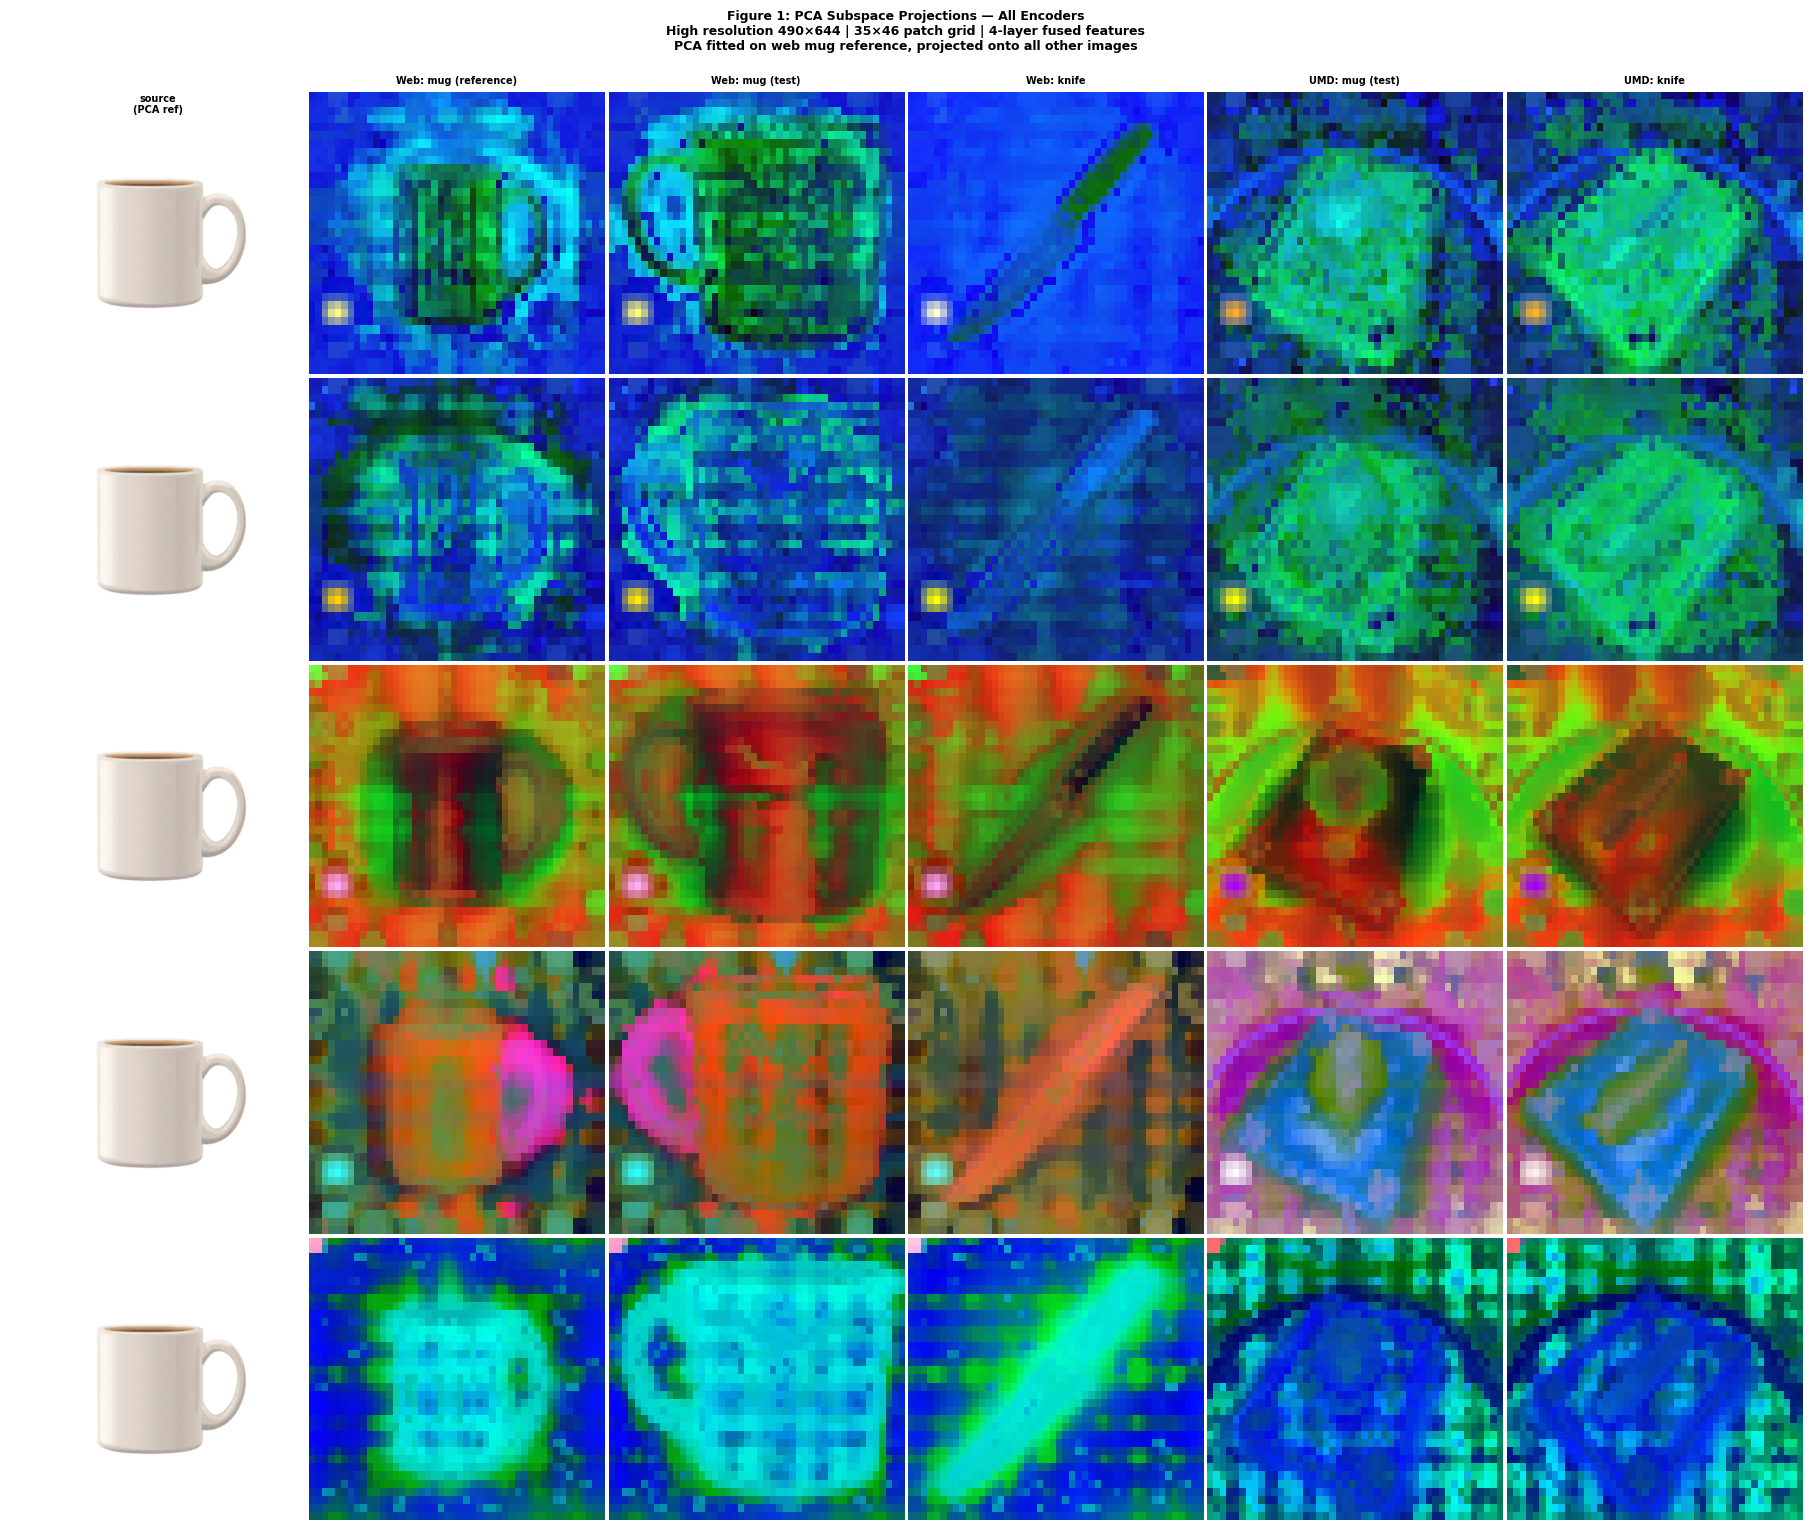

✅ Figure 1 saved


In [ ]:
def to_rgb(proj):
    """
    Normalize PCA projection to [0,1] RGB for display.
    Each of the 3 channels (PC1→R, PC2→G, PC3→B) normalized independently
    so the full color range is used for each component.
    Independent normalization prevents one dominant component from
    washing out the visual variation in the others.
    """
    rgb = proj.copy().astype(np.float32)
    for c in range(3):
        lo, hi = rgb[:,:,c].min(), rgb[:,:,c].max()
        if hi - lo > 1e-6:
            rgb[:,:,c] = (rgb[:,:,c] - lo) / (hi - lo)
        else:
            rgb[:,:,c] = 0.5   # no variance in this channel → mid gray
    return rgb


# Figure 1: rows=encoders, cols=source|web_test|web_knife|UMD_test|UMD_knife
enc_names   = list(ENCODERS.keys())
col_sources = [
    ("web_mug_ref",   web_images_hi["mug_ref"],  None, "Web: mug (reference)"),
    ("web_mug_test",  web_images_hi["mug_test"], "mug_test", "Web: mug (test)"),
    ("web_knife",     web_images_hi["knife"],    "knife",    "Web: knife"),
    ("umd_mug_test",  umd_images_hi["mug_test"], "mug_test", "UMD: mug (test)"),
    ("umd_knife",     umd_images_hi["knife"],    "knife",    "UMD: knife"),
]
# col_sources entries: (col_key, source_PIL, test_key_or_None, col_label)
# test_key_or_None: None means this column shows the reference projection

n_rows = len(enc_names)       # 5 encoders
n_cols = len(col_sources) + 1  # +1 for source image column

fig, axes = plt.subplots(
    nrows=n_rows, ncols=n_cols,
    figsize=(3 * n_cols, 3 * n_rows)
)

for row_i, enc_name in enumerate(enc_names):
    enc_type = ENCODERS[enc_name]

    # ── Column 0: small source image thumbnail ─────────────────────
    # Show the web reference mug so reader knows what PCA was fitted on
    ax = axes[row_i][0]
    ax.imshow(web_images_hi["mug_ref"])
    ax.axis('off')
    # Row label = encoder name + PC1 variance
    var = fused_hi_web[enc_name]["var_ratios"][0]
    ax.set_ylabel(f'{enc_name}\nPC1={var:.3f}',
                  fontsize=7, rotation=90, labelpad=6, va='center',
                  fontweight='bold')
    if row_i == 0:
        ax.set_title('source\n(PCA ref)', fontsize=7, fontweight='bold')

    # ── Columns 1+: PCA projections ───────────────────────────────
    for col_i, (col_key, src_img, test_key, col_label) in enumerate(col_sources):
        ax = axes[row_i][col_i + 1]

        # Determine which results dict and which projection to use
        if "umd" in col_key:
            # UMD columns come from Analysis 2 (fused_hi_umd)
            results = fused_hi_umd[enc_name]
        else:
            # Web columns come from Analysis 1 (fused_hi_web)
            results = fused_hi_web[enc_name]

        if test_key is None:
            # This is the reference image column — show ref_proj
            proj = results["ref_proj"]
        else:
            # This is a test image column — show the projected test
            proj = results["test_projs"][test_key]

        ax.imshow(to_rgb(proj), interpolation='nearest', aspect='auto')
        ax.axis('off')

        if row_i == 0:
            ax.set_title(col_label, fontsize=7, fontweight='bold')

plt.suptitle(
    f'Figure 1: PCA Subspace Projections — All Encoders\n'
    f'High resolution {HI_H}×{HI_W} | {HI_H_GRID}×{HI_W_GRID} patch grid | '
    f'4-layer fused features\n'
    f'PCA fitted on web mug reference, projected onto all other images',
    fontsize=9, fontweight='bold', y=1.01
)
plt.tight_layout(pad=0.3)
plt.savefig(f'{FIGURES_PATH}/pca/fig1_main_comparison.png',
            bbox_inches='tight', dpi=120)
plt.show()
print("✅ Figure 1 saved")

raw_siglip       (~3.5GB):  load 30s + inference 3 images × 10s = ~1 min
paligemma_siglip (~11.7GB): load 90s + inference 3 images × 15s = ~2.5 min
pi0_siglip       (~14GB):   load 120s + inference 3 images × 20s = ~3.5 min
pi05_siglip      (~14.5GB): load 120s + inference 3 images × 20s = ~3.5 min
dinov2           (~346MB):  load 10s + inference 3 images × 5s  = ~0.5 min
─────────────────────────────────────────────────────────────────────────────
Total Analysis 1:  ~11 min  →  ~1.4 compute units

## Figure 2: Resolution Comparison

Shows raw_siglip and dinov2 at both 224×224 and 490×644.
These two encoders represent the extremes — contrastive baseline
vs self-supervised geometric ceiling.

Layout:
  Rows:    raw_siglip (lo res) | raw_siglip (hi res) |
           dinov2 (lo res)     | dinov2 (hi res)
  Columns: web mug ref | web mug test | web knife

What to look for:
  For raw_siglip: does increasing resolution reveal any structure
    that was hidden at 224×224? If features are truly unstructured,
    more patches shouldn't help.
    
  For dinov2: increasing resolution should show FINER geometric detail —
    at 224×224 you see object vs background, at 490×644 you should
    start to see within-object part distinctions.
    
  The gap between the two encoders at each resolution shows how much
  of the DINOv2 advantage is resolution-dependent vs intrinsic.

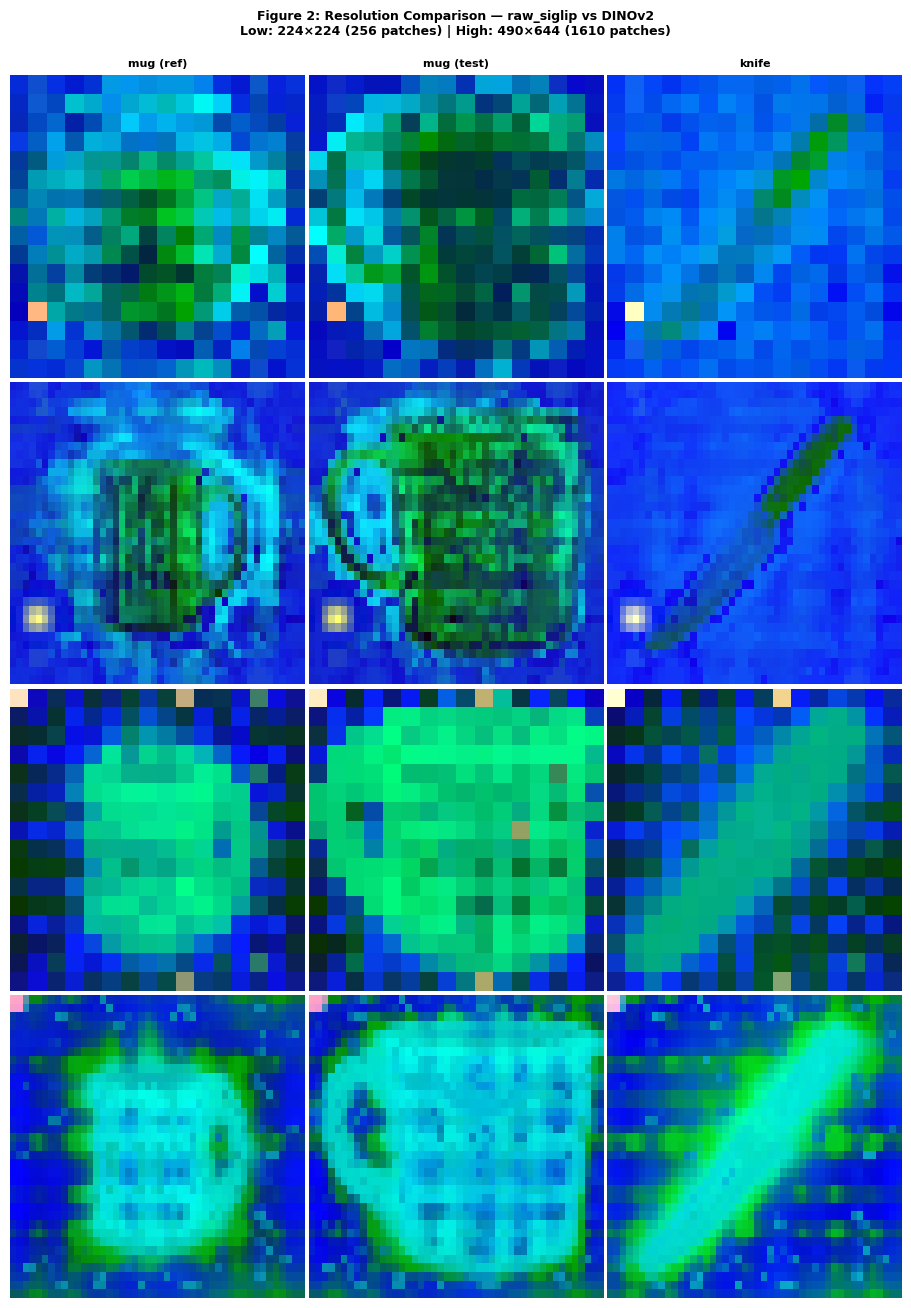

✅ Figure 2 saved


In [ ]:
# Figure 2: resolution comparison for raw_siglip and dinov2
compare_encoders = ["raw_siglip", "dinov2"]
resolutions = [
    ("lo", fused_lo_web, LO_H, LO_W, LO_H_GRID, LO_W_GRID),
    ("hi", fused_hi_web, HI_H, HI_W, HI_H_GRID, HI_W_GRID),
]
# resolutions entries: (label, results_dict, H, W, h_grid, w_grid)

col_keys    = ["mug_ref",  "mug_test",  "knife"]
col_labels  = ["mug (ref)", "mug (test)", "knife"]

n_rows = len(compare_encoders) * len(resolutions)   # 4
n_cols = len(col_keys)                               # 3

fig, axes = plt.subplots(
    nrows=n_rows, ncols=n_cols,
    figsize=(3 * n_cols, 3.2 * n_rows)
)

row_i = 0
for enc_name in compare_encoders:
    for res_label, res_results, H, W, hg, wg in resolutions:

        for col_i, (col_key, col_label) in enumerate(
                zip(col_keys, col_labels)):
            ax = axes[row_i][col_i]

            if col_key == "mug_ref":
                # Reference image — load at correct resolution
                src = web_images_lo if res_label == "lo" else web_images_hi
                ax.imshow(src["mug_ref"])
                proj = res_results[enc_name]["ref_proj"]
            else:
                proj = res_results[enc_name]["test_projs"][col_key]

            ax.imshow(to_rgb(proj), interpolation='nearest', aspect='auto')
            ax.axis('off')

            if col_i == 0:
                var = res_results[enc_name]["var_ratios"][0]
                ax.set_ylabel(
                    f'{enc_name}\n{H}×{W} ({hg}×{wg})\nPC1={var:.3f}',
                    fontsize=7, rotation=90, labelpad=6, va='center',
                    fontweight='bold'
                )
            if row_i == 0:
                ax.set_title(col_label, fontsize=8, fontweight='bold')

        row_i += 1

plt.suptitle(
    'Figure 2: Resolution Comparison — raw_siglip vs DINOv2\n'
    f'Low: {LO_H}×{LO_W} ({LO_N_PATCHES} patches) | '
    f'High: {HI_H}×{HI_W} ({HI_N_PATCHES} patches)',
    fontsize=9, fontweight='bold', y=1.01
)
plt.tight_layout(pad=0.3)
plt.savefig(f'{FIGURES_PATH}/pca/fig2_resolution_comparison.png',
            bbox_inches='tight', dpi=120)
plt.show()
print("✅ Figure 2 saved")

Same model sizes, same inference time (3 images each)
Models re-download from VM disk cache — same speed as Analysis 1
─────────────────────────────────────────────────────────────────────────────
Total Analysis 2:  ~11 min  →  ~1.4 compute units

## Figure 3: Layer Variance Trajectory

Shows how PC1 explained variance ratio changes across network depth
for raw_siglip, π₀_siglip, and dinov2.

This is the mechanistic evidence for feature collapse.

X-axis: normalized layer depth (0=embedding output, 1=final layer)
Y-axis: PC1 explained variance ratio

Interpretation:
  Rising curve = features becoming more collapsed as depth increases
  Flat/falling curve = features maintaining distributed structure
  
  raw_siglip: expected to rise moderately (contrastive training pushes
    toward semantic global features at deeper layers)
    
  π₀_siglip: expected to rise more steeply — VLA training gradient
    signal concentrates features into object-localization axis
    especially in deeper layers
    
  dinov2: expected to stay relatively flat or even dip at mid-layers —
    iBOT objective actively maintains patch diversity throughout
    
The dashed vertical lines mark the probe layers used in the fused analysis.
This lets you see whether our layer choice captures the interesting dynamics
or misses important inflection points.

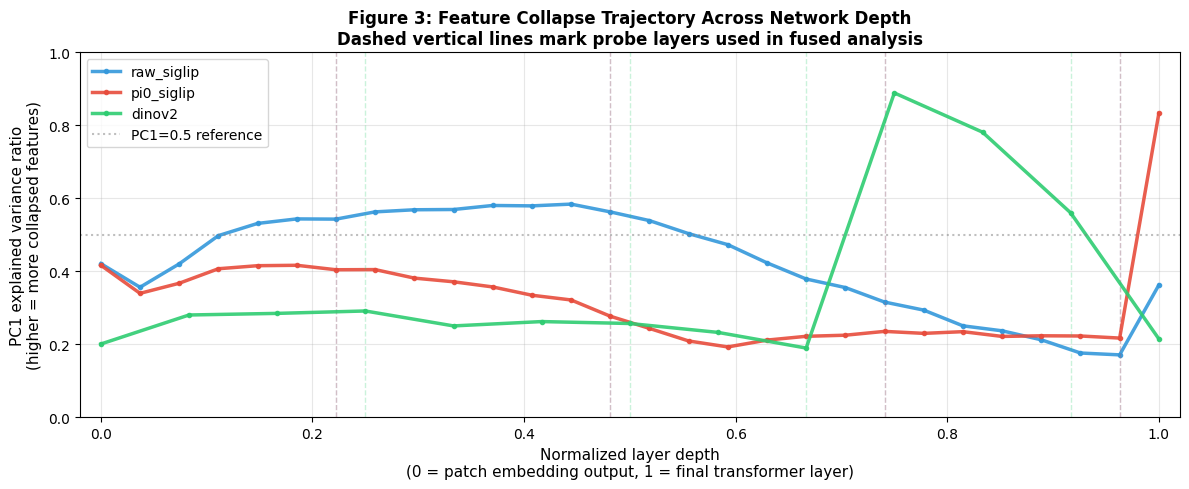

✅ Figure 3 saved


In [ ]:
colors = {
    "raw_siglip": "#3498db",   # blue
    "pi0_siglip": "#e74c3c",   # red
    "dinov2":     "#2ecc71",   # green
}

fig, ax = plt.subplots(figsize=(12, 5))

for enc_name, layer_results in per_layer.items():
    enc_type = TRAJECTORY_ENCODERS[enc_name]
    n_layers = N_HIDDEN_STATES[enc_type]

    # Extract PC1 variance for every layer
    layer_indices = sorted(layer_results.keys())
    pc1_values    = [layer_results[i]["var_ratios"][0] for i in layer_indices]

    # Normalize layer index to [0,1] for cross-architecture comparison
    # This puts SigLIP (28 layers) and DINOv2 (13 layers) on same x-axis
    # 0 = embedding layer output, 1 = final transformer layer
    x_normalized = [i / (n_layers - 1) for i in layer_indices]

    ax.plot(x_normalized, pc1_values,
            color=colors[enc_name], label=enc_name,
            linewidth=2.5, marker='o', markersize=3, alpha=0.9)

    # Mark the probe layers used in fused analysis
    # These are the layers we concatenate for the main comparison
    for probe_idx in PROBE_LAYERS[enc_type]:
        px = probe_idx / (n_layers - 1)
        ax.axvline(x=px, color=colors[enc_name],
                   alpha=0.25, linestyle='--', linewidth=1)

# Reference lines for interpretation
ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5,
           label='PC1=0.5 reference')

ax.set_xlabel('Normalized layer depth\n'
              '(0 = patch embedding output, 1 = final transformer layer)',
              fontsize=11)
ax.set_ylabel('PC1 explained variance ratio\n'
              '(higher = more collapsed features)', fontsize=11)
ax.set_title(
    'Figure 3: Feature Collapse Trajectory Across Network Depth\n'
    'Dashed vertical lines mark probe layers used in fused analysis',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/pca/fig3_variance_trajectory.png',
            bbox_inches='tight', dpi=120)
plt.show()
print("✅ Figure 3 saved")

Low resolution = fewer patches = faster inference (~half the time)
raw_siglip:       ~0.7 min
paligemma:        ~1.8 min
pi0:              ~2.5 min
pi05:             ~2.5 min
dinov2:           ~0.4 min
─────────────────────────────────────────────────────────────────────────────
Total Analysis 3:  ~8 min   →  ~1.0 compute units

## Figure 4: Per-Layer PCA Colormaps

Shows PCA colormap visualizations at selected layers for
raw_siglip and dinov2 — the most contrasting pair.

We show 4 representative layers per encoder:
  - Embedding layer (index 0): raw patch embeddings before any attention
  - Early layer (~25% depth): local edges and textures
  - Middle layer (~50% depth): where interesting structure emerges
  - Final layer (~100% depth): most task-relevant features

This connects the quantitative variance trajectory (Figure 3) to
the visual structure (Figure 1). You can see HOW the collapse happens
visually — what the feature space looks like at each stage.

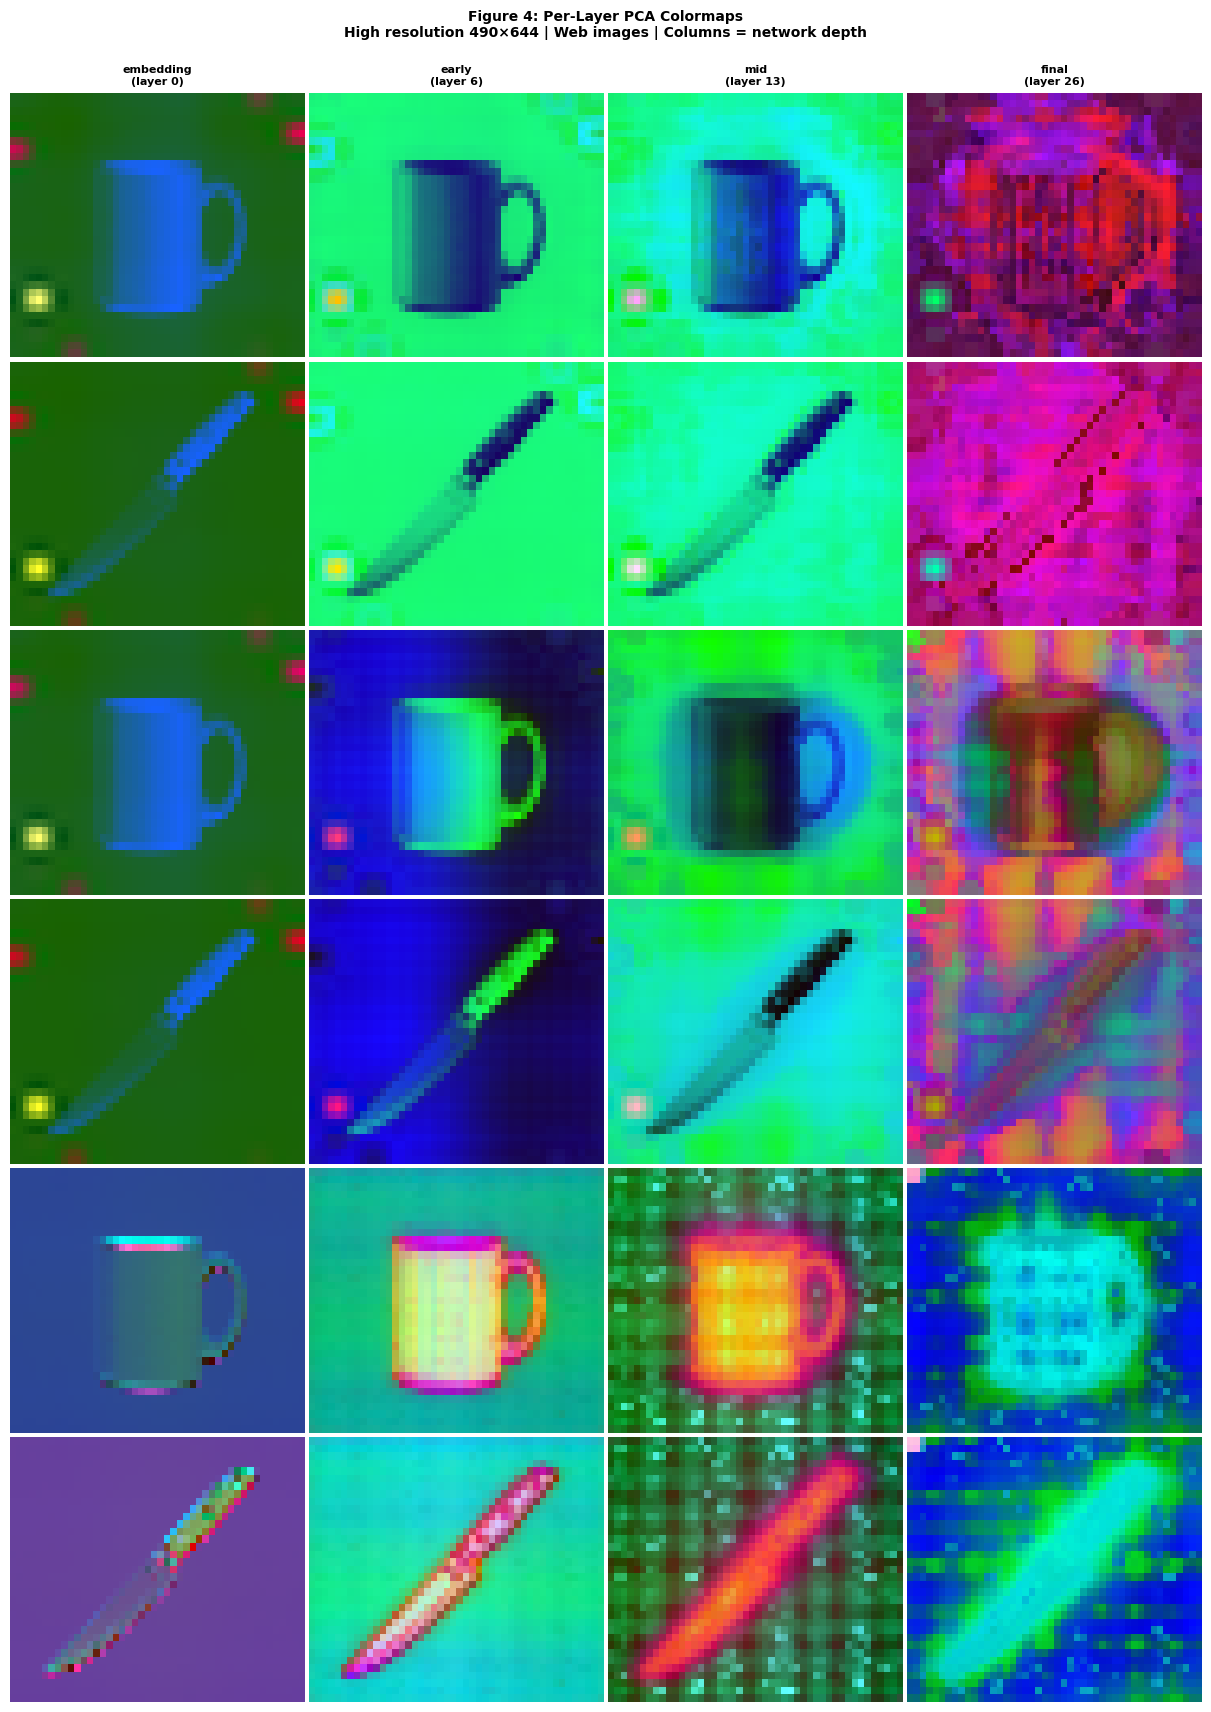

✅ Figure 4 saved


In [ ]:
# Select 4 representative layers for each encoder
# chosen to show early/mid/late/final structure
selected_layers = {
    "raw_siglip": [0, 6, 13, 26],   # embed / early / mid / final
    "pi0_siglip": [0, 6, 13, 26],   # same indices for fair comparison
    "dinov2":     [0, 3,  6, 11],   # embed / early / mid / final (scaled to 12 layers)
}
layer_labels = ["embedding", "early", "mid", "final"]

# Show web mug ref and web knife only (2 images for concise figure)
show_keys = ["mug_ref", "knife"]

n_encoder_rows = len(TRAJECTORY_ENCODERS)  # 3
n_layer_cols   = len(layer_labels)          # 4
n_image_rows   = len(show_keys)             # 2

# Layout: for each encoder, show n_image_rows × n_layer_cols subgrid
# Separated by encoder with labels
total_rows = n_encoder_rows * n_image_rows
total_cols = n_layer_cols

fig, axes = plt.subplots(
    nrows=total_rows, ncols=total_cols,
    figsize=(3 * total_cols, 2.8 * total_rows)
)

for enc_i, (enc_name, enc_type) in enumerate(TRAJECTORY_ENCODERS.items()):
    layers_to_show = selected_layers[enc_name]

    for img_i, img_key in enumerate(show_keys):
        # Which row in the overall figure
        row_i = enc_i * n_image_rows + img_i

        for col_i, (layer_idx, layer_label) in enumerate(
                zip(layers_to_show, layer_labels)):
            ax = axes[row_i][col_i]

            # Get projection for this encoder / layer / image
            layer_data = per_layer[enc_name][layer_idx]
            if img_key == "mug_ref":
                proj = layer_data["ref_proj"]
            else:
                proj = layer_data["test_projs"][img_key]

            ax.imshow(to_rgb(proj), interpolation='nearest', aspect='auto')
            ax.axis('off')

            # Column headers: layer labels (only on first row)
            if row_i == 0:
                ax.set_title(f'{layer_label}\n(layer {layer_idx})',
                            fontsize=8, fontweight='bold')

            # Row labels: encoder name + image name
            if col_i == 0:
                pc1 = layer_data["var_ratios"][0]
                ax.set_ylabel(
                    f'{enc_name}\n{img_key}\nPC1={pc1:.3f}',
                    fontsize=6, rotation=90, labelpad=6, va='center'
                )

plt.suptitle(
    'Figure 4: Per-Layer PCA Colormaps\n'
    f'High resolution {HI_H}×{HI_W} | Web images | '
    'Columns = network depth',
    fontsize=10, fontweight='bold', y=1.01
)
plt.tight_layout(pad=0.3)
plt.savefig(f'{FIGURES_PATH}/pca/fig4_per_layer_colormaps.png',
            bbox_inches='tight', dpi=120)
plt.show()
print("✅ Figure 4 saved")

raw_siglip (28 layers × 2 images):  load 30s + 56 PCA runs = ~5 min
pi0_siglip (28 layers × 2 images):  load 120s + 56 PCA runs = ~7 min
dinov2     (13 layers × 2 images):  load 10s + 26 PCA runs = ~3 min

Note: PCA runs on CPU after model is deleted from GPU
      28 layers × PCA on (1610, 1152) matrix ≈ 2-3 min CPU time
─────────────────────────────────────────────────────────────────────────────
Total Analysis 4:  ~15 min  →  ~1.9 compute units

In [ ]:
# ── Print complete variance summary for all analyses ──────────────
print("\n" + "=" * 70)
print("VARIANCE SUMMARY — PC1 Explained Variance Ratio")
print("Higher PC1 = more collapsed features = less geometric structure")
print("=" * 70)

print(f"\n{'Encoder':<22} {'HiRes Web':>10} {'HiRes UMD':>10} "
      f"{'LoRes Web':>10}  {'Interpretation'}")
print("-" * 70)

for enc_name in ENCODERS:
    v_hi_web = fused_hi_web[enc_name]["var_ratios"][0]
    v_hi_umd = fused_hi_umd[enc_name]["var_ratios"][0]
    v_lo_web = fused_lo_web[enc_name]["var_ratios"][0]

    # Flag based on high-res web (cleanest condition)
    if v_hi_web > 0.70:
        flag = "⚠️  COLLAPSED"
    elif v_hi_web > 0.35:
        flag = "⚡ moderate"
    else:
        flag = "✅ distributed"

    print(f"{enc_name:<22} {v_hi_web:>10.3f} {v_hi_umd:>10.3f} "
          f"{v_lo_web:>10.3f}  {flag}")

print("=" * 70)

print(f"\n{'Encoder':<22} {'Layer trajectory PC1 range':>30}")
print("-" * 55)
for enc_name in TRAJECTORY_ENCODERS:
    pc1_all = [per_layer[enc_name][i]["var_ratios"][0]
               for i in sorted(per_layer[enc_name].keys())]
    print(f"{enc_name:<22} "
          f"min={min(pc1_all):.3f}  "
          f"max={max(pc1_all):.3f}  "
          f"final={pc1_all[-1]:.3f}")
print("=" * 70)


VARIANCE SUMMARY — PC1 Explained Variance Ratio
Higher PC1 = more collapsed features = less geometric structure

Encoder                 HiRes Web  HiRes UMD  LoRes Web  Interpretation
----------------------------------------------------------------------
raw_siglip                  0.228      0.196      0.278  ✅ distributed
paligemma_siglip            0.191      0.179      0.234  ✅ distributed
pi0_siglip                  0.198      0.213      0.235  ✅ distributed
pi05_siglip                 0.226      0.154      0.211  ✅ distributed
dinov2                      0.546      0.518      0.784  ⚡ moderate

Encoder                    Layer trajectory PC1 range
-------------------------------------------------------
raw_siglip             min=0.171  max=0.584  final=0.362
pi0_siglip             min=0.193  max=0.832  final=0.832
dinov2                 min=0.190  max=0.888  final=0.215


## Summary of Figures

Figure 1 (fig1_main_comparison.png):
  Primary result. Shows all 5 encoders across web and UMD images.
  Read down each column to see how training trajectory changes features.
  Read across each row to see cross-object and cross-distribution consistency.

Figure 2 (fig2_resolution_comparison.png):
  Shows raw_siglip vs dinov2 at 224×224 and 490×644.
  Directly connects to the resolution argument from the slides.
  Key question: does resolution change the story, or just the clarity?

Figure 3 (fig3_variance_trajectory.png):
  Mechanistic evidence for feature collapse.
  Shows WHERE in the network collapse happens for each encoder.
  The dashed lines show whether probe layer choice captures the dynamics.

Figure 4 (fig4_per_layer_colormaps.png):
  Visual evidence for what Figure 3 shows quantitatively.
  Each column is a depth level — you can see the feature space
  evolving from texture-based (early) to object-semantic (final).

All figures saved to:
  results/figures/pca/

In [ ]:
# Zip the figures folder and download it
import shutil
from google.colab import files

zip_path = '/content/pca_figures.zip'
shutil.make_archive(
    '/content/pca_figures',   # output path without .zip
    'zip',                     # format
    f'{REPO_DIR}/results/figures/pca'  # folder to zip
)
files.download(zip_path)
print("✅ Downloading pca_figures.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloading pca_figures.zip


## Visualize PCA Results

We create two grid figures:
1. Web images — shows encoder geometry under ideal conditions
2. UMD images — shows what encoders see during the actual task

Each grid has:
  Rows:    reference image + 3 test images  (4 rows)
  Columns: source photo + 5 encoder projections  (6 columns)

Reading the grid:
  ACROSS A ROW (same image, different encoders):
    Compare how differently each encoder structures the same visual input.
    
  DOWN A COLUMN (same encoder, different images):
    Check if colors are consistent across images — same color = same
    type of surface regardless of object category. This is cross-object
    generalization of geometric structure.
    
  KEY COMPARISON — DINOv2 vs SigLIP variants:
    DINOv2 should show consistent colors for semantically similar regions
    (object body across different objects, handles across different tools).
    SigLIP variants should show less consistency, with pi0_siglip showing
    the most collapsed structure (one dominant color for object vs background).

In [ ]:
# ── Figure 1: Web images ───────────────────────────────────────────
visualize_grid(
    results       = web_results,
    source_images = [web_ref] + web_tests,
    row_labels    = web_labels,
    title         = (f'PCA Subspace Projections — Clean Web Images\n'
                     f'{IMG_H}×{IMG_W} resolution | '
                     f'{H_grid}×{W_grid} patch grid | '
                     f'{N_patches} patches per image'),
    save_path     = f'{FIGURES_PATH}/hires/pca_web_all_encoders.png'
)

# ── Figure 2: UMD images ───────────────────────────────────────────
visualize_grid(
    results       = umd_results,
    source_images = [umd_ref] + umd_tests,
    row_labels    = umd_labels,
    title         = (f'PCA Subspace Projections — UMD Scene Images\n'
                     f'{IMG_H}×{IMG_W} resolution | '
                     f'{H_grid}×{W_grid} patch grid | '
                     f'{N_patches} patches per image'),
    save_path     = f'{FIGURES_PATH}/hires/pca_umd_all_encoders.png'
)

# ── Variance table for both image sets ────────────────────────────
print("\nWEB IMAGES — Variance Ratios:")
print_variance_table(web_results)

print("\nUMD IMAGES — Variance Ratios:")
print_variance_table(umd_results)

The two figures are now saved to Drive at:
  results/figures/hires/pca_web_all_encoders.png
  results/figures/hires/pca_umd_all_encoders.png

These are the primary qualitative evidence for Axis 1 of the proposal.

What to look for:
  raw_siglip column:       mostly uniform dark color, little spatial structure
  paligemma column:        slightly more structure than raw (VLM training effect)
  pi0/pi05 columns:        object vs background separation but no part structure
  dinov2 column:           cleanest geometric structure, most consistent colors
                           across different objects

The variance table quantifies what the colormaps show visually.
High PC1 = collapsed features = one-bit encoding per patch.
Low PC1 with meaningful PC2/PC3 = rich multi-dimensional patch encoding.

## Drive Cleanup Utility

Run this cell whenever you want to check or clean up Drive space.
Nothing is deleted automatically — you have to uncomment the delete lines.

What should and shouldn't be on Drive:
  KEEP:  data/umd/               (6GB — dataset, took hours to download)
  KEEP:  data/pca_reference_images/ (tiny — your reference images)
  KEEP:  results/figures/        (tiny — your PCA output figures)
  KEEP:  all code files          (tiny — the repo)
  DELETE: hf_cache/              (if it exists — models go on VM disk)
  DELETE: data/umd/archives/     (if it exists — already extracted)
  DELETE: results/cached_features/ (if it exists — 44GB+ per encoder)

In [ ]:
import shutil

def folder_gb(path):
    if not os.path.exists(path):
        return 0.0
    return sum(
        os.path.getsize(os.path.join(r, f))
        for r, d, files in os.walk(path)
        for f in files
    ) / 1e9

# ── Show current Drive usage ───────────────────────────────────────
print("DRIVE CONTENTS:")
items_to_check = {
    'hf_cache (DELETE if exists)':
        f'{PROJECT_DIR}/hf_cache',
    'data/umd/archives (DELETE if exists)':
        f'{REPO_DIR}/data/umd/archives',
    'results/cached_features (DELETE if exists)':
        f'{REPO_DIR}/results/cached_features',
    'data/umd (KEEP)':
        f'{REPO_DIR}/data/umd',
    'results/figures (KEEP)':
        f'{REPO_DIR}/results/figures',
    'repo code (KEEP)':
        f'{REPO_DIR}',
}

for label, path in items_to_check.items():
    size = folder_gb(path)
    exists = os.path.exists(path)
    print(f"  {size:>6.2f}GB  {label}  {'✅' if exists else '— not found'}")

_, _, free = shutil.disk_usage(PROJECT_DIR)
print(f"\n  Drive free: {free/1e9:.2f}GB")

# ── Delete what shouldn't be on Drive ─────────────────────────────
# Uncomment these lines if the items above show unexpected large sizes

# Delete hf_cache if it somehow ended up on Drive
# shutil.rmtree(f'{PROJECT_DIR}/hf_cache', ignore_errors=True)
# print("✅ hf_cache deleted")

# Delete dataset archives — already extracted, safe to remove
# shutil.rmtree(f'{REPO_DIR}/data/umd/archives', ignore_errors=True)
# print("✅ Archives deleted")

# Delete cached features — these are huge and shouldn't be on Drive
# shutil.rmtree(f'{REPO_DIR}/results/cached_features', ignore_errors=True)
# print("✅ Cached features deleted")

Run this before starting any long compute session to make sure Drive
has enough free space. You need at least 1GB free for figure outputs.

If hf_cache appears with non-zero size — something set HF_HOME to Drive.
Check Cell 2 and make sure the environment variable clearing ran correctly.

Check what GPU and RAM runtime you are running



In [ ]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Fri Apr 24 18:04:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   35C    P0             54W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
import psutil

ram_gb = psutil.virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 179.4 gigabytes of available RAM

You are using a high-RAM runtime!


now the repo results being duplicated


Mount google drive and set the project as the working directory

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# All persistent work lives here
PROJECT_DIR = '/content/drive/MyDrive/VLA_Affordance_Project'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)
print(f"Working directory: {os.getcwd()}")

Working directory: /content/drive/MyDrive/VLA_Affordance_Project


The repo lives in Drive, not in /content/. When the session dies, your code, cached features in results/, and any outputs survive in Drive. You just re-mount and re-run the installs, then continue.

In [ ]:
REPO_DIR = f'{PROJECT_DIR}/VLA-affordance'

if not os.path.exists(REPO_DIR):
    # !git clone https://github.com/aleksantari/VLA-affordance.git
    !git clone https://github.com/shilpitha-03/VLA-affordance.git
    print("Cloned fresh.")
else:
    # Already exists — pull latest changes
    !cd {REPO_DIR} && git pull
    print("Pulled latest changes.")

os.chdir(REPO_DIR)
print(f"In repo: {os.getcwd()}")

^C
Pulled latest changes.
In repo: /content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance


CHECK WHATS BEEN CACHED

In [ ]:
# Run this at the start of any new session to see what's cached
import glob
cached = glob.glob(f'{REPO_DIR}/results/cached_features/*.npy')
print(f"Cached feature files: {len(cached)}")
for f in sorted(cached):
    size_mb = os.path.getsize(f) / 1e6
    print(f"  {os.path.basename(f)}: {size_mb:.0f} MB")

Cached feature files: 0


In [ ]:
import os
HF_CACHE = f'{PROJECT_DIR}/hf_cache'
os.makedirs(HF_CACHE, exist_ok=True)
os.environ['HF_HOME'] = HF_CACHE
os.environ['TRANSFORMERS_CACHE'] = HF_CACHE
os.environ['HF_HUB_CACHE'] = HF_CACHE
print("✅ HF cache redirected to Drive")

✅ HF cache redirected to Drive


In [ ]:
import sys
import torch
print(f"Python: {sys.version}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
GPU: NVIDIA A100-SXM4-80GB


Your CLAUDE.md says π0/π0.5 require a custom transformers fork (fix/lerobot_openpi branch) for the SigLIP check module. Install this FIRST before anything else, to avoid a version conflict later.

In [ ]:
# Uninstall stock transformers first
!pip uninstall -y transformers

# Install the custom fork (fix/lerobot_openpi branch)
# NOTE: Verify this repo URL is the right one for your project.
# If your team has a specific fork, replace the URL below.
!pip install git+https://github.com/huggingface/transformers.git@fix/lerobot_openpi -q

# Verify
import importlib
import transformers
importlib.reload(transformers)
print(f"Transformers version: {transformers.__version__}")

Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 129.9 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


Transformers version: 4.53.3


Install lerobot and Core Dependencies

In [ ]:
!pip install lerobot==0.4.4 -q
!pip install scikit-learn scipy matplotlib seaborn wandb tqdm opencv-python -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.0/92.0 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 117.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.3/564.3 kB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.7/67.7 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.7/91.7 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 12.1 MB/s eta 0:00:00


Install the Project Package

In [ ]:
os.chdir(REPO_DIR)
!pip install -e . -q
print("Project package installed.")

  Preparing metadata (setup.py) ... done
Project package installed.


Verify All Imports

In [ ]:
# Run this to catch any import errors before going further
try:
    import torch
    import transformers
    import lerobot
    import sklearn
    import cv2
    import numpy as np
    from PIL import Image
    print("All core imports successful")
except ImportError as e:
    print(f"Import error: {e}")

All core imports successful


Authenticate with HuggingFace

Security tip for a group project: Don't hardcode the token. Instead, use Colab's Secrets feature:

Click the 🔑 key icon in the left sidebar → Add new secret → Name: HF_TOKEN, Value: your token
Then in the cell: from google.colab import userdata; HF_TOKEN = userdata.get('HF_TOKEN')
This way nobody accidentally commits the token and all teammates can set their own.

In [ ]:
# from google.colab import userdata
# from huggingface_hub import login

# HF_TOKEN = userdata.get('HF_TOKEN')
# login(token=HF_TOKEN)
# print("Logged in from Secrets")

In [ ]:
from huggingface_hub import login

# Replace with your actual token
# DO NOT commit this token to GitHub
HF_TOKEN = "hf_REMOVED"
login(token=HF_TOKEN)
print("HuggingFace login successful")

HuggingFace login successful


Dataset Setup
Your data/download_umd.py should handle this, but here's the explicit approach to make sure it lands in the right place (inside Drive, not /content/).

In [ ]:
os.chdir(REPO_DIR)

DATA_DIR = f'{REPO_DIR}/data/umd'
os.makedirs(DATA_DIR, exist_ok=True)

# Check if already downloaded
if os.path.exists(f'{DATA_DIR}/tools') or os.path.exists(f'{DATA_DIR}/category_split.txt'):
    print("Dataset already present, skipping download.")
else:
    print("Downloading UMD dataset... (~3.1 GB total, this takes ~5-10 minutes)")
    !python data/download_umd.py --output_dir {DATA_DIR}
    print("Download complete.")

Dataset already present, skipping download.


In [ ]:
# ── PERMANENT SESSION STARTUP — run this every session ────────────────────
import os

# NEVER point HF cache to Drive — always use VM local disk
for var in ['HF_HOME', 'TRANSFORMERS_CACHE', 'HF_HUB_CACHE']:
    if var in os.environ:
        del os.environ[var]

# Confirm Drive is NOT being used for model weights
print("HF cache location:", os.path.expanduser("~/.cache/huggingface"))
print("This is on VM local disk — correct ✅")
print("Models will re-download each session but NOT fill your Drive")

HF cache location: /root/.cache/huggingface
This is on VM local disk — correct ✅
Models will re-download each session but NOT fill your Drive


CHANGE PATH IN VLA-affordance/data/download_umd.py


In [ ]:
import os

DATA_DIR = f'{REPO_DIR}/data/umd'
ARCHIVES_DIR = f'{DATA_DIR}/archives'
os.makedirs(ARCHIVES_DIR, exist_ok=True)

# Correct current URLs (the old rgbd-dataset.tar.gz URL is dead)
TOOLS_URL = "https://obj.umiacs.umd.edu/part-affordance/part-affordance-dataset-tools.tar.gz"
CLUTTER_URL = "https://obj.umiacs.umd.edu/part-affordance/part-affordance-dataset-clutter.tar.gz"

# Download tools (2.9 GB)
tools_archive = f'{ARCHIVES_DIR}/tools.tar.gz'
if not os.path.exists(tools_archive):
    print("Downloading tools dataset (2.9 GB)...")
    !wget -q --show-progress -O {tools_archive} {TOOLS_URL}
else:
    print("✅ Tools archive already downloaded")

# Download clutter (0.2 GB)
clutter_archive = f'{ARCHIVES_DIR}/clutter.tar.gz'
if not os.path.exists(clutter_archive):
    print("Downloading clutter dataset (0.2 GB)...")
    !wget -q --show-progress -O {clutter_archive} {CLUTTER_URL}
else:
    print("✅ Clutter archive already downloaded")

# Extract both
print("Extracting...")
!tar -xzf {tools_archive} -C {DATA_DIR}
!tar -xzf {clutter_archive} -C {DATA_DIR}
print("✅ Done. Dataset extracted to:", DATA_DIR)

✅ Tools archive already downloaded
✅ Clutter archive already downloaded
Extracting...
^C
^C
✅ Done. Dataset extracted to: /content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance/data/umd


In [ ]:
#checking progress
import glob
imgs = glob.glob(f'{DATA_DIR}/**/*.jpg', recursive=True)
print(f"Images extracted so far: {len(imgs)}")

Images extracted so far: 29711


Verify Dataset Structure

In [ ]:
import os, glob

# See the top-level structure
for item in sorted(os.listdir(DATA_DIR)):
    print(item)

archives
category_split.txt
part-affordance-clutter
part-affordance-dataset


In [ ]:
# Create category_split.txt from the known UMD train/test protocol
# Format: split_id object_name  (1=train, 2=test)
# Source: Myers et al. ICRA 2015 — held-out test objects per category

# First, see what object directories actually exist in your extraction
tools_dir = f'{DATA_DIR}/part-affordance-dataset/tools'
obj_dirs = sorted(os.listdir(tools_dir))
print(f"Found {len(obj_dirs)} object directories:")
for d in obj_dirs:
    print(" ", d)

In [ ]:
# Generate category_split.txt using the standard UMD protocol
# 1 = train, 2 = test
# Last 2 objects per category are held out for testing

split_lines = []

# Group objects by category
from collections import defaultdict
categories = defaultdict(list)
for obj in obj_dirs:
    category = obj.rsplit('_', 1)[0]  # e.g. "bowl_01" -> "bowl"
    categories[category].append(obj)

for category, objects in sorted(categories.items()):
    objects = sorted(objects)
    n_test = 2  # hold out last 2 per category
    for i, obj in enumerate(objects):
        split_id = 2 if i >= len(objects) - n_test else 1
        split_lines.append(f"{split_id} {obj}")
    print(f"{category}: {len(objects)-n_test} train, {n_test} test")

# Write the file
split_path = f'{DATA_DIR}/part-affordance-dataset/category_split.txt'
with open(split_path, 'w') as f:
    f.write('\n'.join(split_lines) + '\n')

print(f"\n✅ Written to {split_path}")
# print(f"Total: {split_lines.count(chr(49), 0, 1)} ...")

# # Quick summary
# train_count = sum(1 for l in split_lines if l.startswith('1'))
# test_count = sum(1 for l in split_lines if l.startswith('2'))
# print(f"Train objects: {train_count}, Test objects: {test_count}")

bowl: 8 train, 2 test
cup: 4 train, 2 test
hammer: 2 train, 2 test
knife: 10 train, 2 test
ladle: 3 train, 2 test
mallet: 2 train, 2 test
mug: 18 train, 2 test
pot: 0 train, 2 test
saw: 1 train, 2 test
scissors: 6 train, 2 test
scoop: 0 train, 2 test
shears: 0 train, 2 test
shovel: 0 train, 2 test
spoon: 8 train, 2 test
tenderizer: 0 train, 2 test
trowel: 3 train, 2 test
turner: 6 train, 2 test

✅ Written to /content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance/data/umd/part-affordance-dataset/category_split.txt


In [ ]:
import shutil

src = f'{DATA_DIR}/part-affordance-dataset/category_split.txt'
dst = f'{DATA_DIR}/category_split.txt'
shutil.copy(src, dst)
print("✅ Copied split file to both locations")

✅ Copied split file to both locations


In [ ]:
import glob

# Check both locations the loader searches
candidates = [
    f'{DATA_DIR}/category_split.txt',
    f'{DATA_DIR}/part-affordance-dataset/category_split.txt',
]
for path in candidates:
    status = "✅ Found" if os.path.exists(path) else "❌ Missing"
    print(f"{status}: {path}")

# Count RGB images only (not depth frames)
rgb_images = glob.glob(f'{DATA_DIR}/**/*_rgb.jpg', recursive=True)
print(f"\nRGB image pairs found: {len(rgb_images)}")
# Expect ~14,000+

✅ Found: /content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance/data/umd/category_split.txt
✅ Found: /content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance/data/umd/part-affordance-dataset/category_split.txt

RGB image pairs found: 29711


Config Update for Colab Paths
Your configs/probing_config.yaml likely has local paths from the RTX 5090 setup. Update it for Colab.

In [ ]:
import yaml

CONFIG_PATH = f'{REPO_DIR}/configs/probing_config.yaml'

with open(CONFIG_PATH, 'r') as f:
    config = yaml.safe_load(f)

# Print the actual structure
print(yaml.dump(config, default_flow_style=False))

depth_augmentation:
  cache_dir: /content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance/results/cached_features/depth_normal
  dpt_model: Intel/dpt-large
  method: dpt
encoders:
  dino_wm:
    encoder_type: dinov2
    feature_dim: 768
    fused_feature_dim: 3072
    num_layers: 12
    num_patches: 256
    patch_size: 14
    probe_layers:
    - 2
    - 5
    - 8
    - 11
    repo: https://github.com/mazpie/dino-wm
    status: deferred
  dinov2:
    encoder_type: dinov2
    feature_dim: 768
    fused_feature_dim: 3072
    model_name: facebook/dinov2-base
    num_layers: 12
    num_patches: 256
    patch_size: 14
    probe_layers:
    - 2
    - 5
    - 8
    - 11
  paligemma_siglip:
    encoder_type: siglip
    feature_dim: 1152
    fused_feature_dim: 4608
    model_name: google/paligemma-3b-pt-224
    note: Requires HuggingFace gated access
    num_layers: 27
    num_patches: 256
    patch_size: 14
    probe_layers:
    - 6
    - 13
    - 20
    - 26
  pi05_siglip:
    encoder_type

In [ ]:
import yaml, os

CONFIG_PATH = f'{REPO_DIR}/configs/probing_config.yaml'

with open(CONFIG_PATH, 'r') as f:
    config = yaml.safe_load(f)

# Update paths to Colab/Drive locations
config['paths']['umd_dataset'] = f'{REPO_DIR}/data/umd'
config['paths']['cached_features'] = f'{REPO_DIR}/results/cached_features'
config['paths']['figures'] = f'{REPO_DIR}/results/figures'
config['paths']['tables'] = f'{REPO_DIR}/results/tables'
config['paths']['models_dir'] = f'{REPO_DIR}/models'
config['depth_augmentation']['cache_dir'] = f'{REPO_DIR}/results/cached_features/depth_normal'

# Create all result directories
for key in ['cached_features', 'figures', 'tables', 'models_dir']:
    os.makedirs(config['paths'][key], exist_ok=True)
os.makedirs(config['depth_augmentation']['cache_dir'], exist_ok=True)

with open(CONFIG_PATH, 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

print("✅ Config updated with Colab paths")
print(yaml.dump(config['paths'], default_flow_style=False))

✅ Config updated with Colab paths
cached_features: /content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance/results/cached_features
figures: /content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance/results/figures
models_dir: /content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance/models
tables: /content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance/results/tables
umd_dataset: /content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance/data/umd



 Running the Pipeline

Script 01 — Verify Encoders

In [ ]:
# os.chdir(REPO_DIR)
# !python scripts/01_setup_encoders.py
# ── Session startup — verify cache without loading models ──────────────────
import os

# DO NOT set HF_HOME to Drive — let models cache on VM local disk
# Remove it if it was set
for var in ['HF_HOME', 'TRANSFORMERS_CACHE', 'HF_HUB_CACHE']:
    if var in os.environ:
        del os.environ[var]
        print(f"Cleared {var}")

# Check VM local cache
cache_dir = os.path.expanduser("~/.cache/huggingface/hub")
if os.path.exists(cache_dir):
    print("\nModels cached on VM disk:")
    for model_dir in sorted(os.listdir(cache_dir)):
        size = sum(
            os.path.getsize(os.path.join(root, f))
            for root, dirs, files in os.walk(
                os.path.join(cache_dir, model_dir))
            for f in files
        ) / 1e9
        print(f"  ✅ {model_dir}: {size:.1f}GB")
else:
    print("⚠️  No local HF cache — models will download when first used")
    print("   This is fine — they download to VM disk (~150GB free)")
    print("   They download once per session, NOT to Drive")

Cleared HF_HOME
Cleared TRANSFORMERS_CACHE
Cleared HF_HUB_CACHE
⚠️  No local HF cache — models will download when first used
   This is fine — they download to VM disk (~150GB free)
   They download once per session, NOT to Drive


In [ ]:
import subprocess
result = subprocess.run(['du', '-sh', f'{PROJECT_DIR}/'],
                      capture_output=True, text=True)
print("Project folder size:", result.stdout)

Project folder size: 6.3G	/content/drive/MyDrive/VLA_Affordance_Project/



Expected output: Each of the 5 active encoders (raw SigLIP, PaliGemma SigLIP, π0 SigLIP, π0.5 SigLIP, DINOv2) loads and produces a tensor of shape (B, 256, fused_dim). You should see:

SigLIP-family: fused_dim = 4608
DINOv2: fused_dim = 3072

If this fails: The most likely culprit is the transformers fork not being correctly installed (Step 5). The error will say something like SigLIPCheckModule not found or a similar attribute error. Fix: re-run Cell 5 and restart the runtime.

Script 02 — Extract and Cache Features

This is the longest-running step. On A100 with 14,000 images × 5 encoders, expect 20-40 minutes total.

In [ ]:
# import os, numpy as np

# CACHE_PATH = f'{REPO_DIR}/results/cached_features'

# print("Full cache directory contents:")
# for root, dirs, files in os.walk(CACHE_PATH):
#     level = root.replace(CACHE_PATH, '').count(os.sep)
#     indent = '  ' * level
#     print(f"{indent}{os.path.basename(root)}/")
#     for f in files:
#         fpath = os.path.join(root, f)
#         size_gb = os.path.getsize(fpath) / 1e9
#         arr = np.load(fpath, mmap_mode='r')
#         print(f"{indent}  {f}: shape={arr.shape} ({size_gb:.2f}GB)")

Full cache directory contents:
cached_features/
  raw_siglip/
    train/
  paligemma_siglip/
    train/
  pi0_siglip/
    train/
  pi05_siglip/
    train/
  dinov2/
    train/
  depth_normal/


In [ ]:
# import os, numpy as np

# CACHE_PATH = f'{REPO_DIR}/results/cached_features'

# for encoder in ['raw_siglip', 'paligemma_siglip', 'pi0_siglip', 'pi05_siglip', 'dinov2']:
#     train_path = f'{CACHE_PATH}/{encoder}/train'
#     feat_path = f'{train_path}/features_multilayer.npy'
#     mask_path = f'{train_path}/masks.npy'

#     if not os.path.exists(feat_path):
#         print(f"{encoder}: ❌ features file missing")
#         continue

#     feat = np.load(feat_path, mmap_mode='r')
#     mask = np.load(mask_path, mmap_mode='r')

#     # Check if last batch has real data (non-zero) or was never written
#     last_slice = feat[-32:]  # last 32 samples
#     is_complete = last_slice.any()  # all zeros = incomplete

#     size_gb = os.path.getsize(feat_path) / 1e9
#     status = "✅ complete" if is_complete else "❌ incomplete (zeros at end)"
#     print(f"{encoder}: shape={feat.shape} size={size_gb:.2f}GB → {status}")

raw_siglip: ❌ features file missing
paligemma_siglip: ❌ features file missing
pi0_siglip: ❌ features file missing
pi05_siglip: ❌ features file missing
dinov2: ❌ features file missing


In [ ]:
# import os

# CACHE_PATH = f'{REPO_DIR}/results/cached_features'

# for encoder in ['raw_siglip', 'paligemma_siglip', 'pi0_siglip', 'pi05_siglip', 'dinov2']:
#     encoder_path = f'{CACHE_PATH}/{encoder}'
#     print(f"\n{encoder}/")
#     for root, dirs, files in os.walk(encoder_path):
#         for f in files:
#             fpath = os.path.join(root, f)
#             size_gb = os.path.getsize(fpath) / 1e9
#             print(f"  {os.path.relpath(fpath, encoder_path)}: {size_gb:.2f}GB")


raw_siglip/

paligemma_siglip/

pi0_siglip/

pi05_siglip/

dinov2/


In [ ]:
# import subprocess
# # Search entire Drive project folder for any .npy files
# result = subprocess.run(
#     ['find', f'{PROJECT_DIR}', '-name', '*.npy', '-size', '+1M'],
#     capture_output=True, text=True
# )
# print(result.stdout if result.stdout else "No .npy files found anywhere in project folder")

No .npy files found anywhere in project folder


In [ ]:
# # What did we actually pass to the script?
# print("REPO_DIR:", REPO_DIR)
# print("Expected cache:", f'{REPO_DIR}/results/cached_features')

# # Check if results folder has anything at all
# result2 = subprocess.run(
#     ['find', f'{REPO_DIR}/results', '-type', 'f'],
#     capture_output=True, text=True
# )
# print("\nAll files in results/:")
# print(result2.stdout if result2.stdout else "Empty")

REPO_DIR: /content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance
Expected cache: /content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance/results/cached_features

All files in results/:
Empty


In [ ]:
# import sys
# sys.path.insert(0, REPO_DIR)

# from data.umd_dataset import UMDAffordanceDataset

# # Test with the actual path
# dataset = UMDAffordanceDataset(
#     root_dir=f'{REPO_DIR}/data/umd',
#     split='train'
# )
# print(f"Samples found: {len(dataset)}")

# # Also test pointing directly at the extracted folder
# dataset2 = UMDAffordanceDataset(
#     root_dir=f'{REPO_DIR}/data/umd/part-affordance-dataset',
#     split='train'
# )
# print(f"Samples found (direct): {len(dataset2)}")

UMD train: found 18984 samples
Samples found: 18984
UMD train: found 18984 samples
Samples found (direct): 18984


In [ ]:
# import glob
# rgb_files = glob.glob(f'{REPO_DIR}/data/umd/**/*_rgb.jpg', recursive=True)
# print(f"RGB jpg files found: {len(rgb_files)}")
# if rgb_files:
#     print("Example:", rgb_files[0])

RGB jpg files found: 29711
Example: /content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance/data/umd/part-affordance-dataset/tools/scissors_02/scissors_02_00000143_rgb.jpg


In [ ]:
# # os.chdir(REPO_DIR)
# # !python scripts/02_extract_features.py
# os.chdir(REPO_DIR)
# DATA_PATH = f'{REPO_DIR}/data/umd'
# CACHE_PATH = f'{REPO_DIR}/results/cached_features'

# !python scripts/02_extract_features.py \
#     --data_dir {DATA_PATH} \
#     --cache_dir {CACHE_PATH} \
#     --split train \
#     --batch_size 32

In [ ]:
!rm -rf ~/.cache/huggingface
!df -h /content

Filesystem      Size  Used Avail Use% Mounted on
overlay         236G   84G  153G  36% /


In [ ]:
REPO_DIR     = '/content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance'
PROJECT_DIR  = '/content/drive/MyDrive/VLA_Affordance_Project'
DATA_PATH    = f'{REPO_DIR}/data/umd'
CACHE_PATH   = f'{REPO_DIR}/results/cached_features'

print("REPO_DIR:   ", REPO_DIR)
print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_PATH:  ", DATA_PATH)
print("CACHE_PATH: ", CACHE_PATH)

REPO_DIR:    /content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance
PROJECT_DIR: /content/drive/MyDrive/VLA_Affordance_Project
DATA_PATH:   /content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance/data/umd
CACHE_PATH:  /content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance/results/cached_features


In [ ]:
import os, shutil, numpy as np, subprocess, time

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_PATH   = f'{REPO_DIR}/data/umd'
CACHE_PATH  = f'{REPO_DIR}/results/cached_features'  # Drive (final)
LOCAL_CACHE = '/content/cache_staging'                # VM disk (fast writes)
EXPECTED_N  = 18984

# Per-encoder batch sizes — π0/π0.5 are 14GB models, need smaller batches
ENCODER_BATCH = {
    'raw_siglip':       32,
    'paligemma_siglip': 32,
    'pi0_siglip':       16,  # 14GB model, conservative
    'pi05_siglip':      16,  # 14GB model, conservative
    'dinov2':           64,  # small model, fast
}
ENCODERS = list(ENCODER_BATCH.keys())

# ── Pre-flight checks ──────────────────────────────────────────────────────

# 1. Redirect HF cache to Drive BEFORE any model loads
HF_CACHE = f'{PROJECT_DIR}/hf_cache'
os.makedirs(HF_CACHE, exist_ok=True)
os.environ['HF_HOME']            = HF_CACHE
os.environ['TRANSFORMERS_CACHE'] = HF_CACHE
os.environ['HF_HUB_CACHE']       = HF_CACHE
print(f"✅ HF cache → Drive: {HF_CACHE}")

# 2. Check VM disk has enough headroom (need ~50GB for largest model + staging)
vm_stat = os.statvfs('/content')
vm_free_gb = (vm_stat.f_bavail * vm_stat.f_frsize) / 1e9
print(f"✅ VM disk free: {vm_free_gb:.1f}GB")
if vm_free_gb < 30:
    print("⚠️  WARNING: Less than 30GB free on VM disk.")
    print("   Run: !rm -rf ~/.cache/huggingface")
    print("   Then re-run this cell.")
    raise SystemExit("Free up VM disk before continuing.")

# 3. Check Drive has enough space (need ~100GB for all features + hf_cache)
drive_stat = os.statvfs(PROJECT_DIR)
drive_free_gb = (drive_stat.f_bavail * drive_stat.f_frsize) / 1e9
print(f"✅ Drive free: {drive_free_gb:.1f}GB")
if drive_free_gb < 20:
    print("⚠️  WARNING: Less than 20GB free on Drive.")
    raise SystemExit("Free up Drive space before continuing.")

# 4. Verify dataset is accessible
import glob
rgb_files = glob.glob(f'{DATA_PATH}/**/*_rgb.jpg', recursive=True)
if len(rgb_files) < 1000:
    raise SystemExit(f"❌ Dataset not found at {DATA_PATH} — check path.")
print(f"✅ Dataset: {len(rgb_files)} images found")

os.makedirs(LOCAL_CACHE, exist_ok=True)
os.makedirs(CACHE_PATH, exist_ok=True)
os.chdir(REPO_DIR)

# ── Helper: verify a .npy file is complete ─────────────────────────────────
def verify_npy(path, expected_n, label=""):
    """Returns (ok, message)"""
    if not os.path.exists(path):
        return False, f"file missing"
    size_gb = os.path.getsize(path) / 1e9
    if size_gb < 0.01:
        return False, f"file exists but nearly empty ({size_gb:.3f}GB)"
    try:
        arr = np.load(path, mmap_mode='r')
    except Exception as e:
        return False, f"failed to load: {e}"
    if arr.shape[0] != expected_n:
        return False, f"wrong sample count: got {arr.shape[0]}, expected {expected_n}"
    if not arr[-32:].any():
        return False, f"last 32 rows are all zeros (incomplete write)"
    if not arr[:32].any():
        return False, f"first 32 rows are all zeros (extraction never started)"
    return True, f"shape={arr.shape} ({size_gb:.2f}GB)"

# ── Per-encoder loop ───────────────────────────────────────────────────────
results = {}

for encoder in ENCODERS:
    print(f"\n{'='*60}")
    print(f"  ENCODER: {encoder}")
    print(f"{'='*60}")

    drive_feat = f'{CACHE_PATH}/{encoder}/train/features_multilayer.npy'
    drive_mask = f'{CACHE_PATH}/{encoder}/train/masks.npy'
    local_feat = f'{LOCAL_CACHE}/{encoder}/train/features_multilayer.npy'
    local_mask = f'{LOCAL_CACHE}/{encoder}/train/masks.npy'
    batch_size = ENCODER_BATCH[encoder]

    # ── Check if already complete on Drive ────────────────────────────────
    ok_feat, msg_feat = verify_npy(drive_feat, EXPECTED_N)
    ok_mask, msg_mask = verify_npy(drive_mask, EXPECTED_N)

    if ok_feat and ok_mask:
        print(f"  ✅ Already complete on Drive:")
        print(f"     features: {msg_feat}")
        print(f"     masks:    {msg_mask}")
        results[encoder] = 'skipped (already done)'
        continue

    # ── Clean up any incomplete Drive or local files ───────────────────────
    if os.path.exists(f'{CACHE_PATH}/{encoder}'):
        print(f"  ⚠️  Incomplete Drive cache found — clearing it")
        shutil.rmtree(f'{CACHE_PATH}/{encoder}')
    if os.path.exists(f'{LOCAL_CACHE}/{encoder}'):
        print(f"  ⚠️  Stale local staging found — clearing it")
        shutil.rmtree(f'{LOCAL_CACHE}/{encoder}')

    # ── Extract to local VM disk ───────────────────────────────────────────
    print(f"  Extracting to local VM disk (batch_size={batch_size})...")
    t0 = time.time()
    ret = os.system(f"""python scripts/02_extract_features.py \
        --data_dir {DATA_PATH} \
        --cache_dir {LOCAL_CACHE} \
        --split train \
        --batch_size {batch_size} \
        --encoders {encoder}""")
    elapsed = (time.time() - t0) / 60
    print(f"  Extraction finished in {elapsed:.1f} min (exit code: {ret})")

    if ret != 0:
        print(f"  ❌ Script exited with error code {ret} — stopping.")
        results[encoder] = 'FAILED (script error)'
        break

    # ── Verify local extraction ────────────────────────────────────────────
    ok_feat, msg_feat = verify_npy(local_feat, EXPECTED_N)
    ok_mask, msg_mask = verify_npy(local_mask, EXPECTED_N)

    if not ok_feat:
        print(f"  ❌ LOCAL VERIFICATION FAILED: features — {msg_feat}")
        results[encoder] = 'FAILED (local verification)'
        break
    if not ok_mask:
        print(f"  ❌ LOCAL VERIFICATION FAILED: masks — {msg_mask}")
        results[encoder] = 'FAILED (local verification)'
        break

    print(f"  ✅ Local verified: features {msg_feat}")
    print(f"  ✅ Local verified: masks    {msg_mask}")

    # ── Copy to Drive ──────────────────────────────────────────────────────
    print(f"  Copying to Drive (may take a few minutes for large files)...")
    t0 = time.time()
    shutil.copytree(
        f'{LOCAL_CACHE}/{encoder}',
        f'{CACHE_PATH}/{encoder}',
        dirs_exist_ok=True
    )
    elapsed = (time.time() - t0) / 60
    print(f"  Copy finished in {elapsed:.1f} min")

    # ── Verify on Drive ────────────────────────────────────────────────────
    ok_feat, msg_feat = verify_npy(drive_feat, EXPECTED_N)
    ok_mask, msg_mask = verify_npy(drive_mask, EXPECTED_N)

    if not ok_feat:
        print(f"  ❌ DRIVE VERIFICATION FAILED: features — {msg_feat}")
        print(f"  Local copy still intact at {LOCAL_CACHE}/{encoder}")
        results[encoder] = 'FAILED (drive verification)'
        break
    if not ok_mask:
        print(f"  ❌ DRIVE VERIFICATION FAILED: masks — {msg_mask}")
        results[encoder] = 'FAILED (drive verification)'
        break

    print(f"  ✅ Drive verified: features {msg_feat}")
    print(f"  ✅ Drive verified: masks    {msg_mask}")

    # ── Free local VM disk ─────────────────────────────────────────────────
    shutil.rmtree(f'{LOCAL_CACHE}/{encoder}')

    # ── Check VM disk still healthy for next encoder ───────────────────────
    vm_stat = os.statvfs('/content')
    vm_free_gb = (vm_stat.f_bavail * vm_stat.f_frsize) / 1e9
    print(f"  ✅ VM disk free after cleanup: {vm_free_gb:.1f}GB")
    if vm_free_gb < 20:
        print(f"  ⚠️  WARNING: Only {vm_free_gb:.1f}GB left on VM — next encoder may OOM")

    results[encoder] = f'✅ done — {msg_feat}'

# ── Final summary ──────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("  FINAL SUMMARY")
print(f"{'='*60}")
for encoder, status in results.items():
    print(f"  {encoder}: {status}")

✅ HF cache → Drive: /content/drive/MyDrive/VLA_Affordance_Project/hf_cache
✅ VM disk free: 159.9GB
✅ Drive free: 7.9GB
⚠️  WARNING: Less than 20GB free on Drive.


SystemExit: Free up Drive space before continuing.

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
n_samples = 18984
n_patches = 256

siglip_dim = 4608
dinov2_dim = 3072

siglip_gb = (n_samples * n_patches * siglip_dim * 2) / 1e9
dinov2_gb = (n_samples * n_patches * dinov2_dim * 2) / 1e9
masks_gb  = (n_samples * 224 * 224 * 8) / 1e9

print(f"Per SigLIP encoder features: {siglip_gb:.2f} GB")
print(f"Per DINOv2 encoder features: {dinov2_gb:.2f} GB")
print(f"Masks per encoder:           {masks_gb:.2f} GB")
print(f"")
print(f"Minimum 3 encoders (raw_siglip + pi0_siglip + dinov2):")
min_gb = 2*siglip_gb + dinov2_gb + 3*masks_gb
print(f"  {min_gb:.2f} GB total")
print(f"")
print(f"All 5 encoders:")
all_gb = 4*siglip_gb + dinov2_gb + 5*masks_gb
print(f"  {all_gb:.2f} GB total")

Per SigLIP encoder features: 44.79 GB
Per DINOv2 encoder features: 29.86 GB
Masks per encoder:           7.62 GB

Minimum 3 encoders (raw_siglip + pi0_siglip + dinov2):
  142.30 GB total

All 5 encoders:
  247.12 GB total


Pi0.5 was not extracted complete, ran out of disk space so clear out that models features and compute again stop after dinov2 as dinwm currently falls back to dinov2.

In [ ]:
# os.chdir(REPO_DIR)
# DATA_PATH = f'{REPO_DIR}/data/umd'
# CACHE_PATH = f'{REPO_DIR}/results/cached_features'

# !python scripts/02_extract_features.py \
#     --data_dir {DATA_PATH} \
#     --cache_dir {CACHE_PATH} \
#     --split train \
#     --batch_size 32 \
#     --encoders pi05_siglip dinov2 dino_wm

What this does: Runs all 5 encoders over the full UMD dataset, saves float16 numpy arrays to results/cached_features/. After this, all subsequent scripts load from cache — no GPU re-inference needed.
Expected output: One .npy file per encoder per split, e.g.:
results/cached_features/raw_siglip_train.npy  (shape: ~11800 × 256 × 4608)
results/cached_features/dinov2_train.npy       (shape: ~11800 × 256 × 3072)
...

Don't let the session idle during this step. Colab will disconnect after ~30 min of inactivity. Keep the tab open and visible. If it crashes mid-way, re-run — the script should be able to detect which encoders are already cached.

Script 03 — Linear Probing (Axis 1, Method 1)

In [ ]:
os.chdir(REPO_DIR)
!python scripts/03_run_linear_probing.py --epochs 50

Target validation: DINOv2 should reach ~0.662 mIoU (7-class) on UMD. If you get a very different number (say <0.5 or >0.75), there's a protocol mismatch — check the BatchNorm + upsample ordering in probing/linear_probe.py against the STATUS_REPORT's protocol alignment notes.

Script 04 — PCA Analysis

In [ ]:
import glob, random
from PIL import Image

# Get all RGB images
all_images = sorted(glob.glob(f'{DATA_PATH}/**/*_rgb.jpg', recursive=True))

# Pick a reference image (a mug is ideal for the paper)
mug_images = [f for f in all_images if 'mug' in f]
knife_images = [f for f in all_images if 'knife' in f]
scissor_images = [f for f in all_images if 'scissors' in f]

reference = mug_images[0]
test_imgs = [mug_images[5], knife_images[0], scissor_images[0]]

print("Reference:", reference)
print("Test images:")
for t in test_imgs:
    print(" ", t)

Reference: /content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance/data/umd/part-affordance-dataset/tools/mug_01/mug_01_00000001_rgb.jpg
Test images:
  /content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance/data/umd/part-affordance-dataset/tools/mug_01/mug_01_00000006_rgb.jpg
  /content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance/data/umd/part-affordance-dataset/tools/knife_01/knife_01_00000001_rgb.jpg
  /content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance/data/umd/part-affordance-dataset/tools/scissors_01/scissors_01_00000001_rgb.jpg


In [ ]:
# os.chdir(REPO_DIR)
# !python scripts/04_run_pca_analysis.py
os.chdir(REPO_DIR)
FIGURES_PATH = f'{REPO_DIR}/results/figures'
os.makedirs(FIGURES_PATH, exist_ok=True)

REF = reference
TESTS = ' '.join(test_imgs)

!python scripts/04_run_pca_analysis.py \
    --reference_image "{REF}" \
    --test_images {TESTS} \
    --figures_dir {FIGURES_PATH} \
    --encoders raw_siglip pi0_siglip dinov2

/usr/local/lib/python3.12/dist-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
2026-04-22 02:45:53.399898: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-22 02:45:53.419594: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776825953.442511   10709 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776825953.450073   10709 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to regis

In [ ]:
import subprocess

# Search for any PNG files saved anywhere on VM or Drive
result = subprocess.run(
    ['find', '/content', '-name', '*.png', '-size', '+1k'],
    capture_output=True, text=True
)
print(result.stdout if result.stdout else "No PNG files found anywhere")

In [ ]:
with open(f'{REPO_DIR}/evaluation/visualization.py', 'r') as f:
    print(f.read())

In [ ]:
import os
figures = sorted(os.listdir(f'{REPO_DIR}/results/figures'))
print(f"Generated {len(figures)} figures:")
for f in figures:
    print(" ", f)

Generated 13 figures:
  pca_comparison.png
  pca_dinov2_reference.png
  pca_dinov2_test_0.png
  pca_dinov2_test_1.png
  pca_dinov2_test_2.png
  pca_pi0_siglip_reference.png
  pca_pi0_siglip_test_0.png
  pca_pi0_siglip_test_1.png
  pca_pi0_siglip_test_2.png
  pca_raw_siglip_reference.png
  pca_raw_siglip_test_0.png
  pca_raw_siglip_test_1.png
  pca_raw_siglip_test_2.png


/usr/local/lib/python3.12/dist-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
2026-04-22 02:55:45.662258: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-22 02:55:45.681840: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776826545.704919   13288 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776826545.712498   13288 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to regis

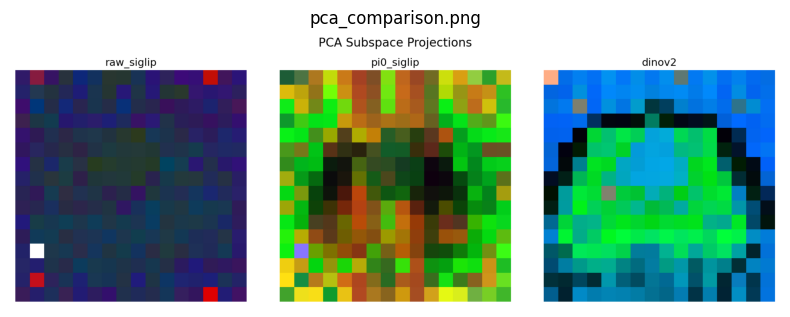

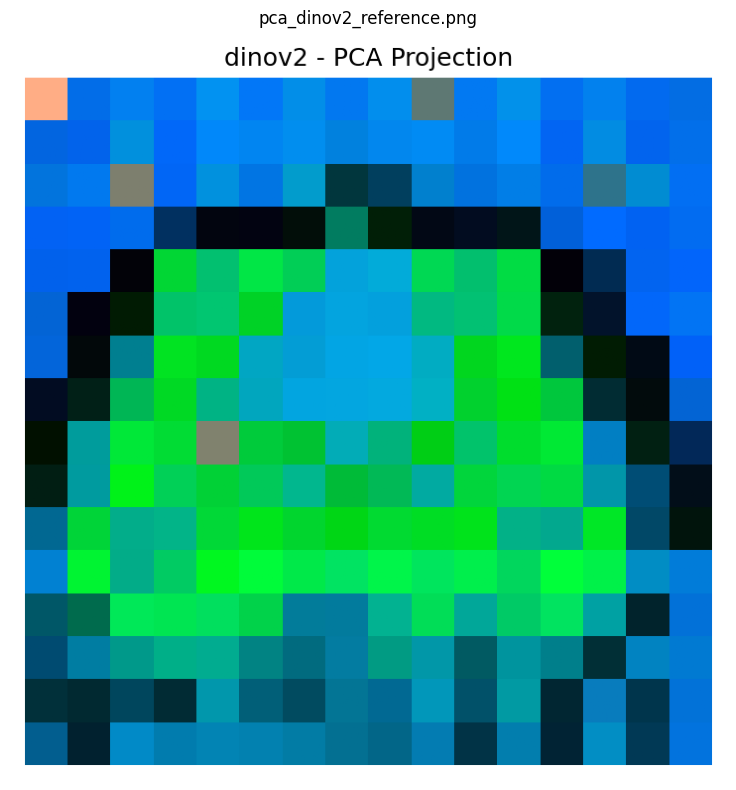

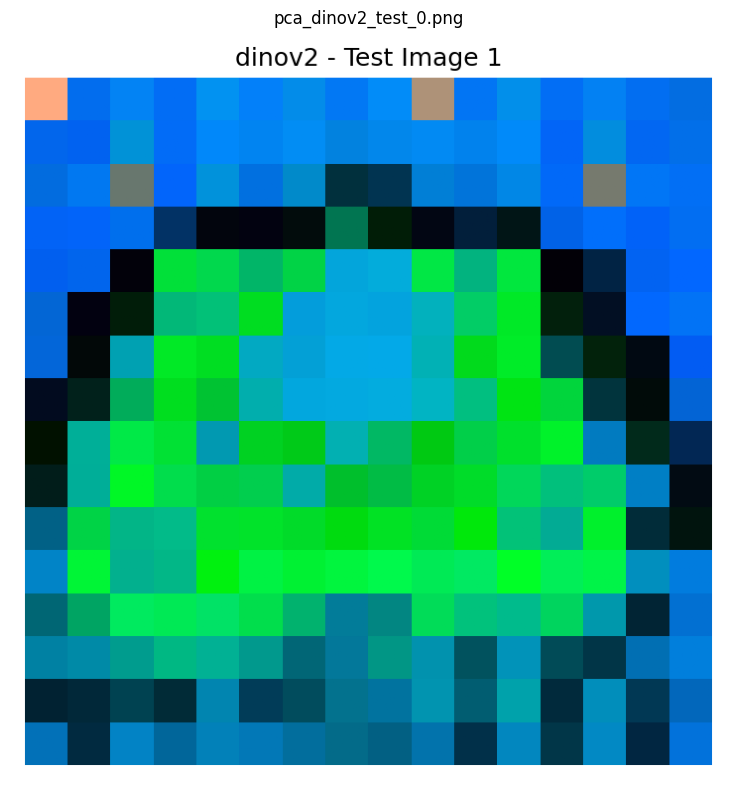

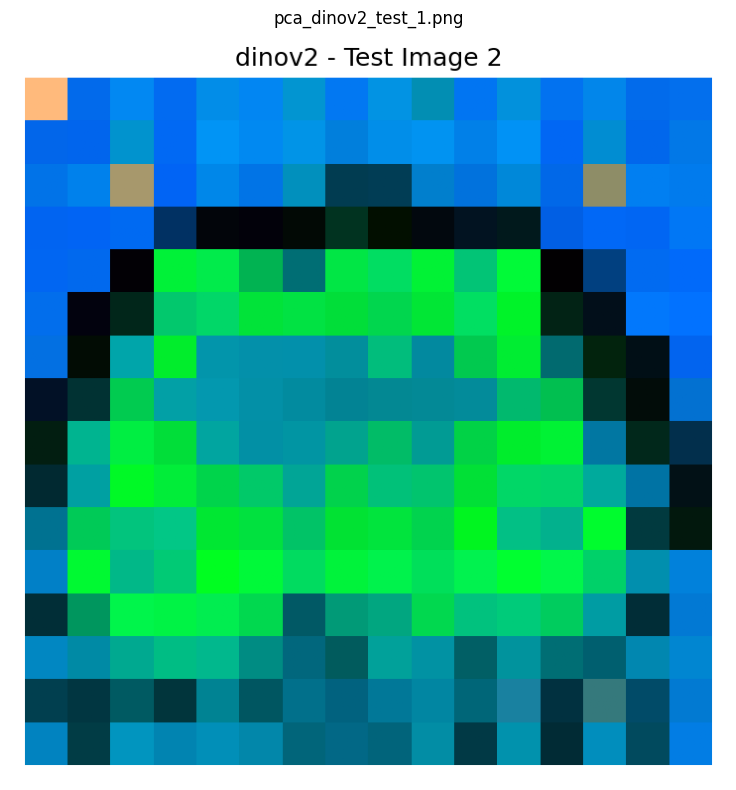

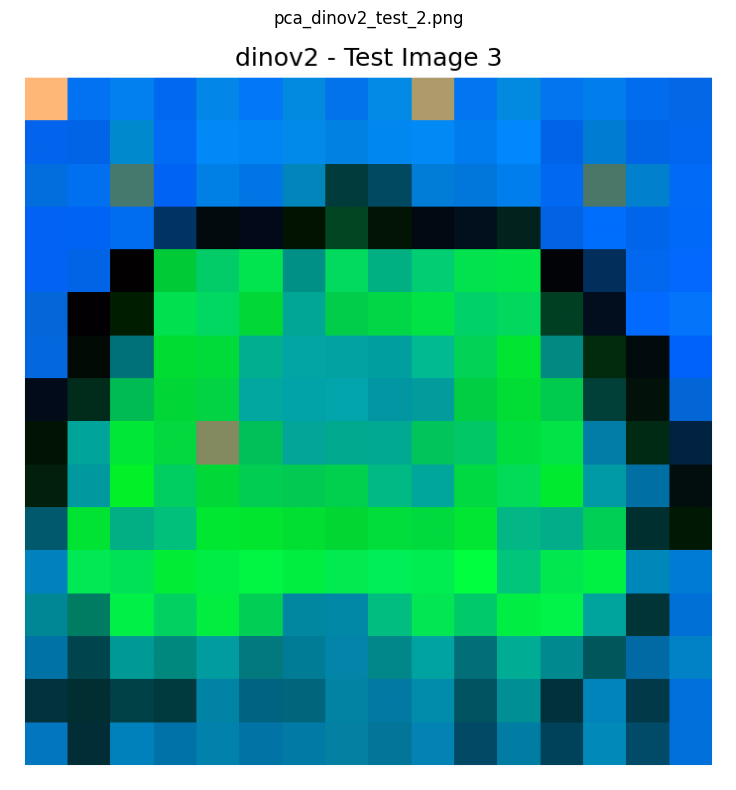

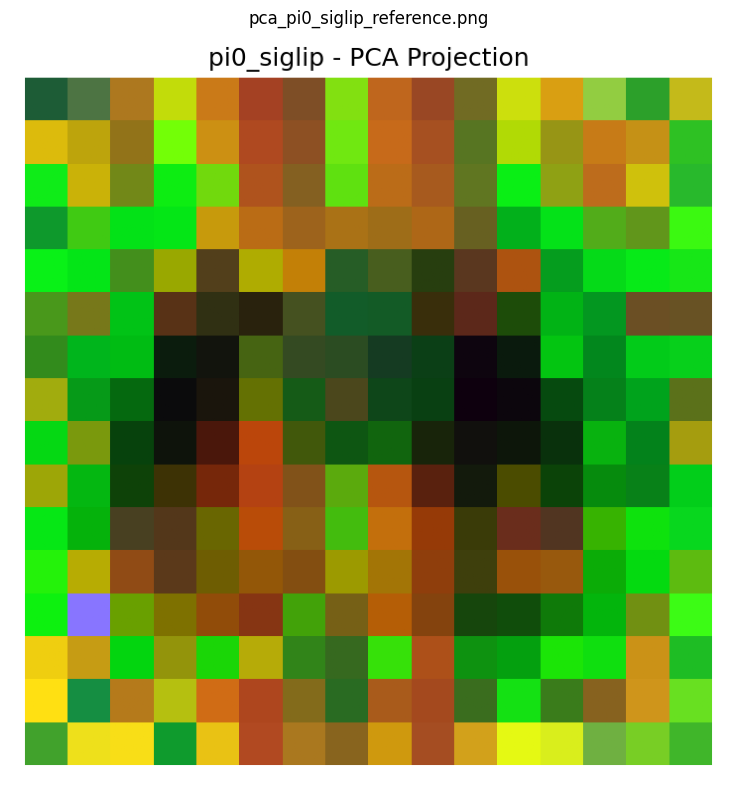

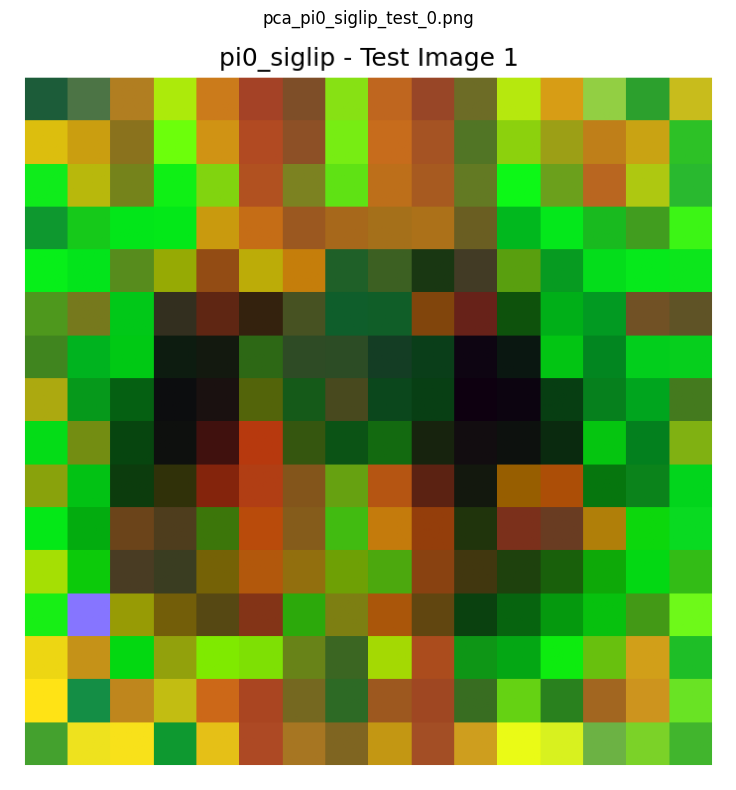

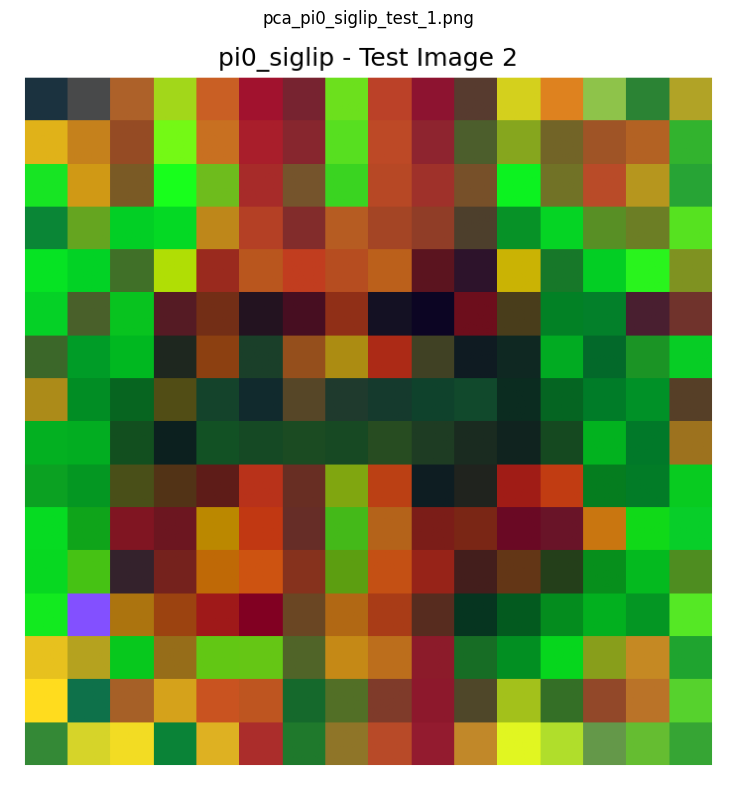

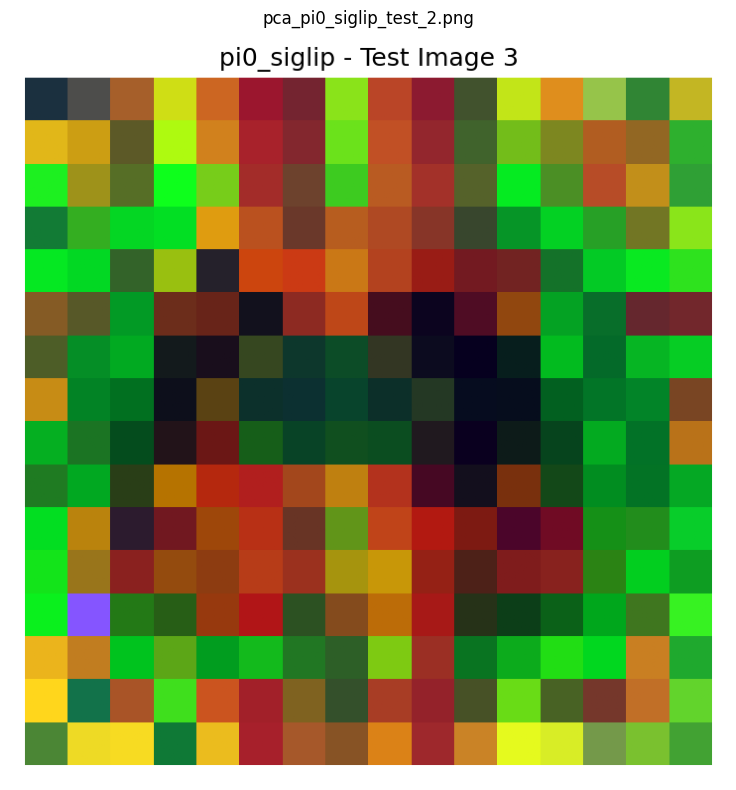

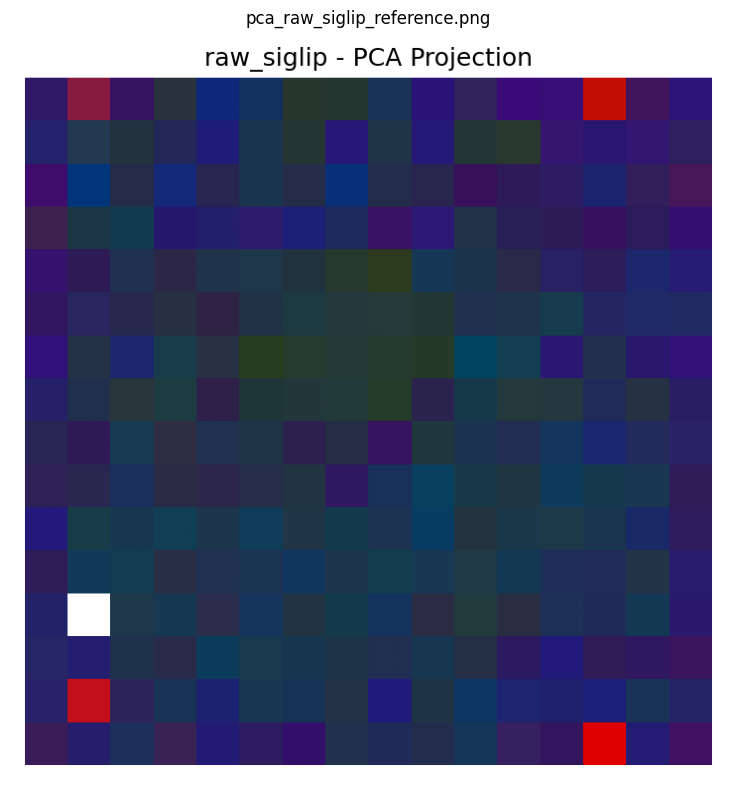

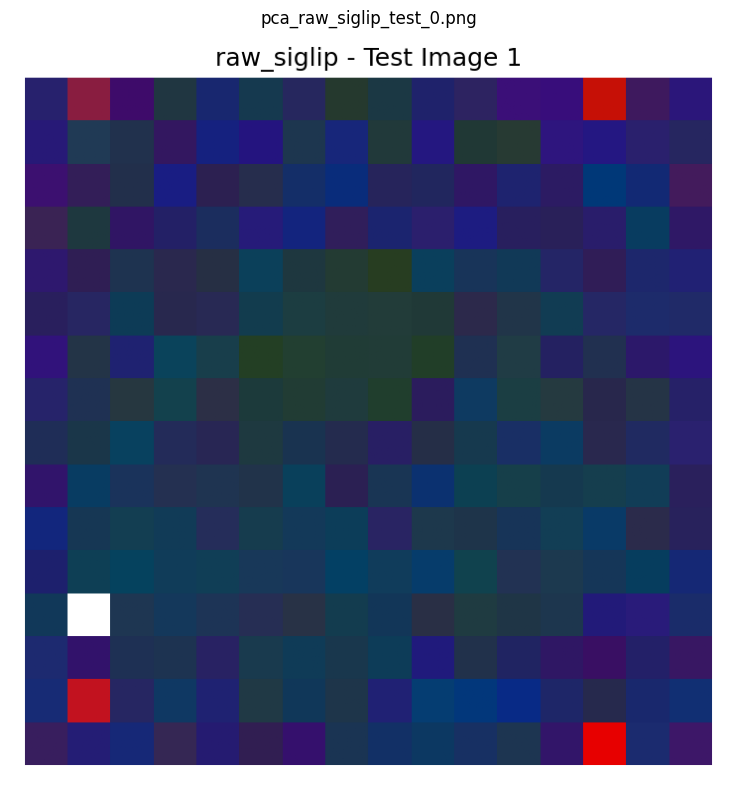

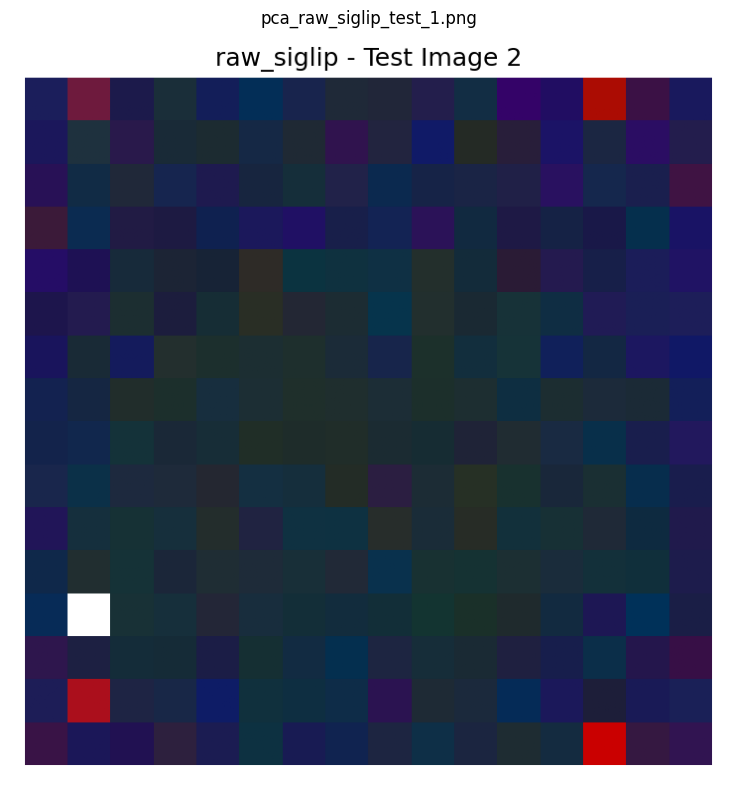

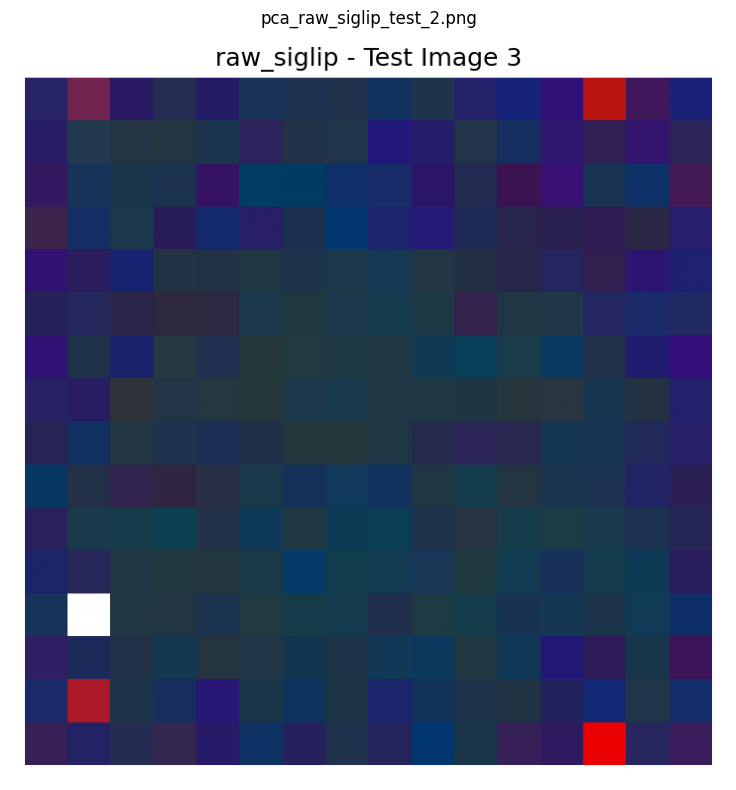

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob

# Absolute figures path on Drive
FIGURES_PATH = f'{REPO_DIR}/results/figures'
os.makedirs(FIGURES_PATH, exist_ok=True)

# Pick images
all_images = sorted(glob.glob(f'{DATA_PATH}/**/*_rgb.jpg', recursive=True))
mug_images     = [f for f in all_images if '/mug_' in f]
knife_images   = [f for f in all_images if '/knife_' in f]
scissor_images = [f for f in all_images if '/scissors_' in f]

REF   = mug_images[0]
TESTS = ' '.join([mug_images[5], knife_images[0], scissor_images[0]])

os.chdir(REPO_DIR)
!python scripts/04_run_pca_analysis.py \
    --reference_image "{REF}" \
    --test_images {TESTS} \
    --figures_dir "{FIGURES_PATH}" \
    --encoders raw_siglip pi0_siglip dinov2

# Verify files landed on Drive
saved = sorted(glob.glob(f'{FIGURES_PATH}/*.png'))
print(f"\n{len(saved)} figures saved to Drive:")
for f in saved:
    print(" ", os.path.basename(f))

# Display all figures inline
for fpath in saved:
    img = mpimg.imread(fpath)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title(os.path.basename(fpath))
    plt.axis('off')
    plt.tight_layout()
    plt.show()

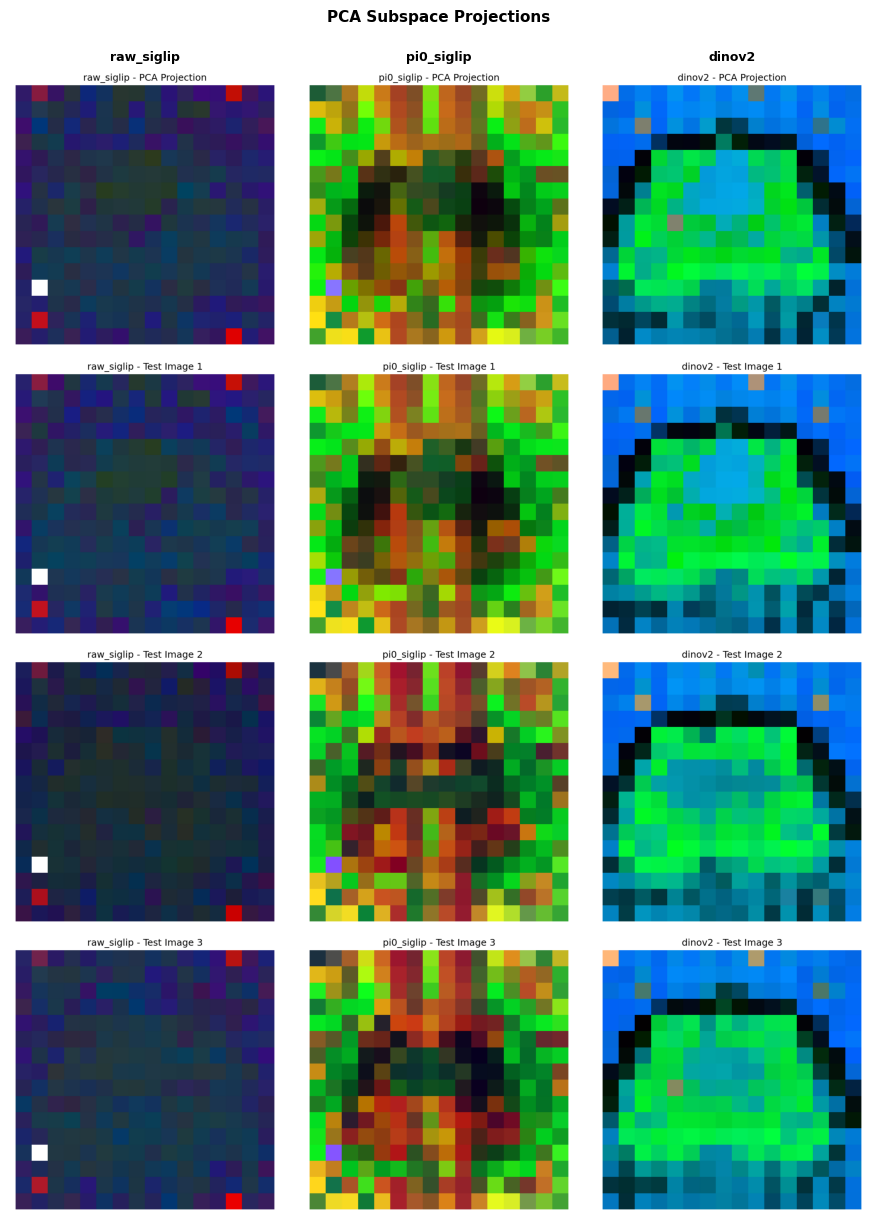

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

encoders = ['raw_siglip', 'pi0_siglip', 'dinov2']
images = {
    'reference (mug)':   'reference',
    'test_0 (mug #2)':   'test_0',
    'test_1 (knife)':    'test_1',
    'test_2 (scissors)': 'test_2',
}

fig, axes = plt.subplots(
    nrows=len(images),
    ncols=len(encoders),
    figsize=(9, 12)
)

for row_idx, (row_label, img_key) in enumerate(images.items()):
    for col_idx, encoder in enumerate(encoders):
        ax = axes[row_idx][col_idx]
        fpath = f'{FIGURES_PATH}/pca_{encoder}_{img_key}.png'
        ax.imshow(mpimg.imread(fpath))
        ax.axis('off')
        if row_idx == 0:
            ax.set_title(encoder, fontsize=9, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(row_label, fontsize=8, rotation=90,
                         labelpad=8, va='center')

plt.suptitle('PCA Subspace Projections', fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout(pad=0.5)
plt.savefig(f'{FIGURES_PATH}/pca_full_comparison_grid.png', bbox_inches='tight', dpi=120)
plt.show()

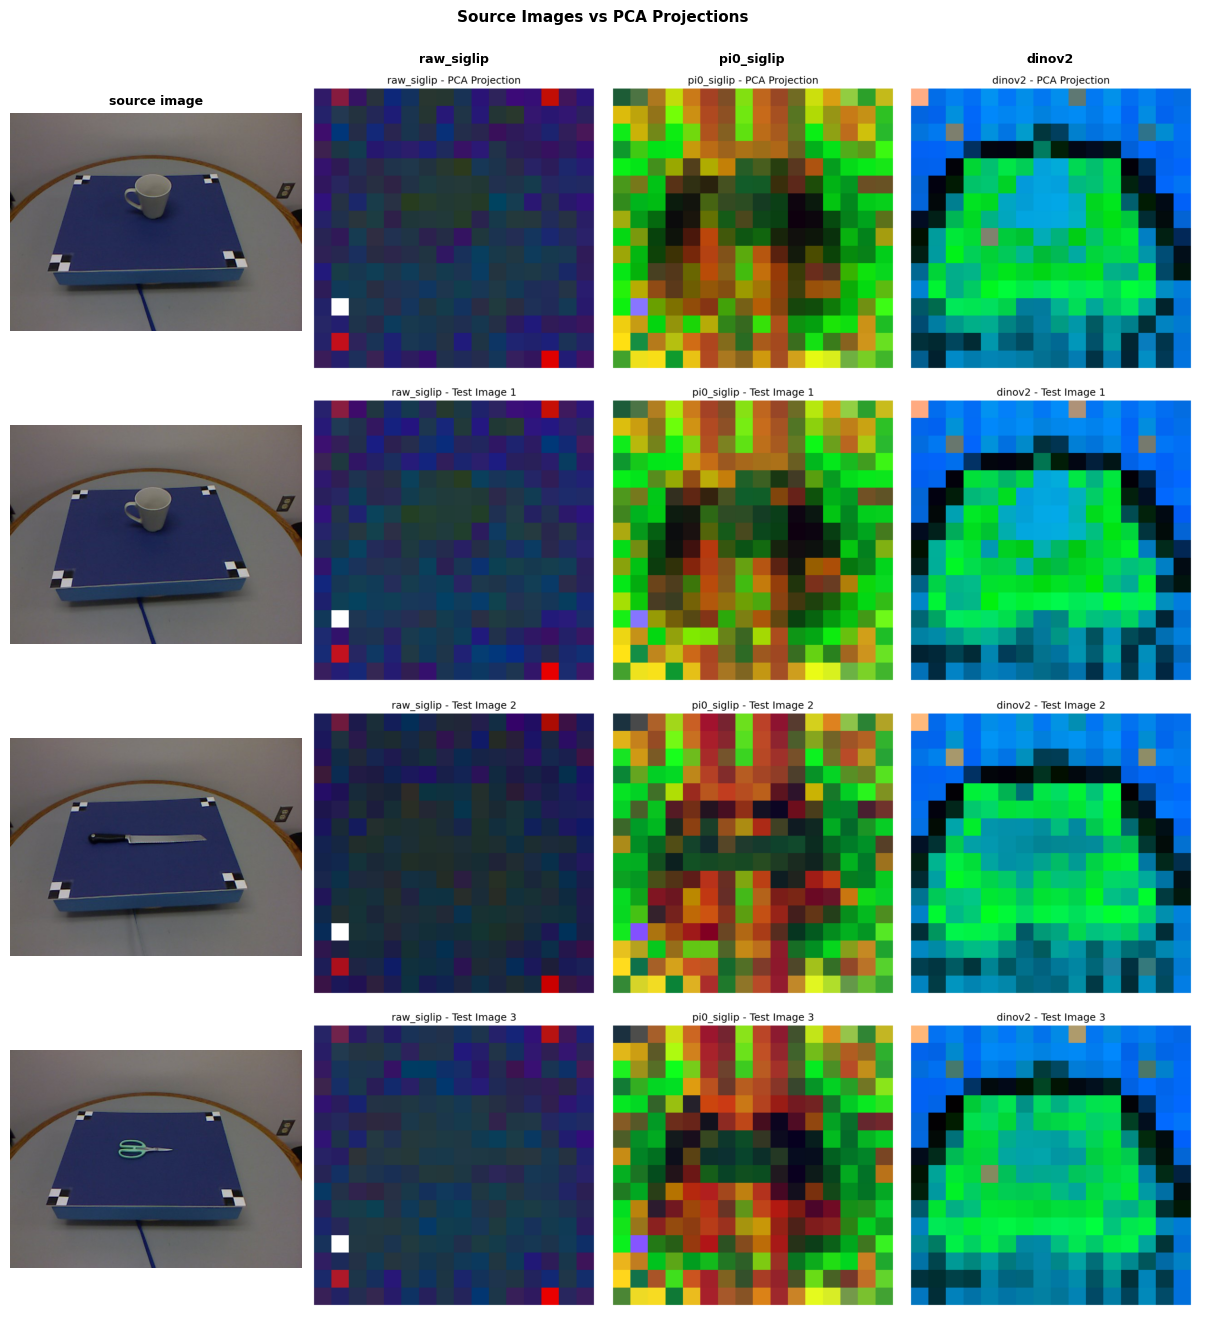

✅ Saved


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# The actual source images used
source_images = {
    'reference (mug)':   REF,
    'test_0 (mug #2)':   mug_images[5],
    'test_1 (knife)':    knife_images[0],
    'test_2 (scissors)': scissor_images[0],
}

encoders = ['raw_siglip', 'pi0_siglip', 'dinov2']
img_keys = ['reference', 'test_0', 'test_1', 'test_2']

# 4 rows x 4 cols (source image + 3 encoder PCA projections)
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(12, 13))

col_headers = ['source image'] + encoders

for row_idx, (row_label, src_path) in enumerate(source_images.items()):
    # Column 0: actual source image
    ax = axes[row_idx][0]
    ax.imshow(mpimg.imread(src_path))
    ax.axis('off')
    ax.set_ylabel(row_label, fontsize=8, rotation=90, labelpad=8, va='center')
    if row_idx == 0:
        ax.set_title('source image', fontsize=9, fontweight='bold')

    # Columns 1-3: PCA projections per encoder
    for col_idx, encoder in enumerate(encoders):
        ax = axes[row_idx][col_idx + 1]
        key = img_keys[row_idx]
        fpath = f'{FIGURES_PATH}/pca_{encoder}_{key}.png'
        ax.imshow(mpimg.imread(fpath))
        ax.axis('off')
        if row_idx == 0:
            ax.set_title(encoder, fontsize=9, fontweight='bold')

plt.suptitle('Source Images vs PCA Projections', fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout(pad=0.5)
plt.savefig(f'{FIGURES_PATH}/pca_with_source_images.png', bbox_inches='tight', dpi=120)
plt.show()
print(f"✅ Saved")

In [ ]:
# Look at what's actually in the mug folder
import os
mug_dir = f'{DATA_PATH}/part-affordance-dataset/tools/mug_01'
files = sorted(os.listdir(mug_dir))
print(f"Files in mug_01: {len(files)}")
print('\n'.join(files[:10]))

Files in mug_01: 1200
mug_01_00000001_depth.png
mug_01_00000001_label.mat
mug_01_00000001_label_rank.mat
mug_01_00000001_rgb.jpg
mug_01_00000002_depth.png
mug_01_00000002_label.mat
mug_01_00000002_label_rank.mat
mug_01_00000002_rgb.jpg
mug_01_00000003_depth.png
mug_01_00000003_label.mat


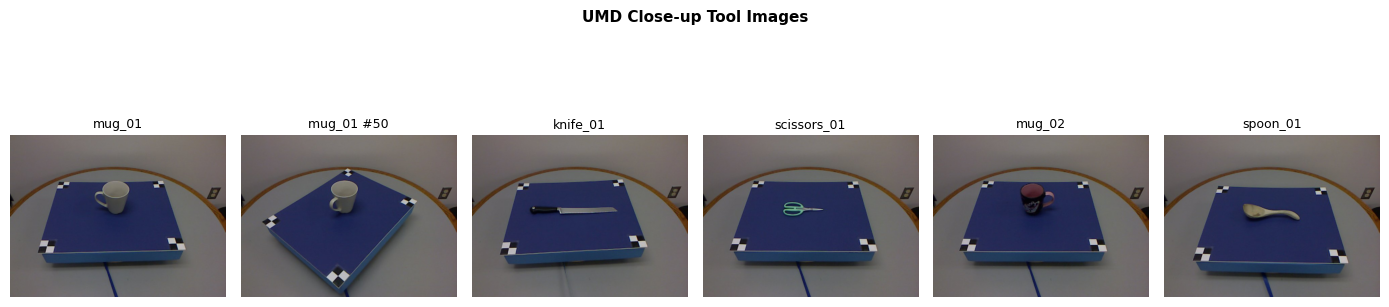

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Sample some close-up RGB images from different objects
sample_images = {
    'mug_01':      f'{DATA_PATH}/part-affordance-dataset/tools/mug_01/mug_01_00000001_rgb.jpg',
    'mug_01 #50':  f'{DATA_PATH}/part-affordance-dataset/tools/mug_01/mug_01_00000050_rgb.jpg',
    'knife_01':    f'{DATA_PATH}/part-affordance-dataset/tools/knife_01/knife_01_00000001_rgb.jpg',
    'scissors_01': f'{DATA_PATH}/part-affordance-dataset/tools/scissors_01/scissors_01_00000001_rgb.jpg',
    'mug_02':      f'{DATA_PATH}/part-affordance-dataset/tools/mug_02/mug_02_00000001_rgb.jpg',
    'spoon_01':    f'{DATA_PATH}/part-affordance-dataset/tools/spoon_01/spoon_01_00000001_rgb.jpg',
}

fig, axes = plt.subplots(1, len(sample_images), figsize=(14, 4))
for ax, (label, path) in zip(axes, sample_images.items()):
    ax.imshow(mpimg.imread(path))
    ax.set_title(label, fontsize=9)
    ax.axis('off')
plt.suptitle('UMD Close-up Tool Images', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

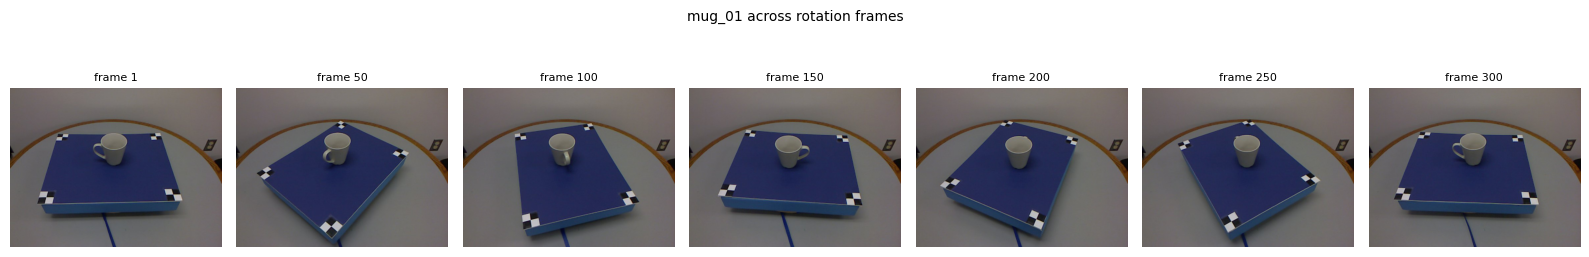

In [ ]:
# Sample frames across the rotation to find better viewing angles
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

mug_dir = f'{DATA_PATH}/part-affordance-dataset/tools/mug_01'
# Sample at different rotation points
frames = [1, 50, 100, 150, 200, 250, 300]

fig, axes = plt.subplots(1, len(frames), figsize=(16, 3))
for ax, frame in zip(axes, frames):
    fpath = f'{mug_dir}/mug_01_{frame:08d}_rgb.jpg'
    if os.path.exists(fpath):
        ax.imshow(mpimg.imread(fpath))
        ax.set_title(f'frame {frame}', fontsize=8)
        ax.axis('off')

plt.suptitle('mug_01 across rotation frames', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
import os

# Create directory on Drive to store reference images
img_dir = f'{REPO_DIR}/data/pca_reference_images'
os.makedirs(img_dir, exist_ok=True)

# Upload files from your local system
print("Select your 4 images (mug_ref, mug_test, knife, scissors)...")
uploaded = files.upload()

# Save each uploaded file to Drive
for filename, data in uploaded.items():
    save_path = f'{img_dir}/{filename}'
    with open(save_path, 'wb') as f:
        f.write(data)
    print(f"✅ Saved {filename} to Drive")

# Show what was uploaded
print("\nFiles in reference images folder:")
for f in sorted(os.listdir(img_dir)):
    print(f"  {f}")

Select your 4 images (mug_ref, mug_test, knife, scissors)...


Saving knife.webp to knife.webp
Saving mug1.webp to mug1.webp
Saving mug2.webp to mug2.webp
Saving scissors-6378708.webp to scissors-6378708.webp
✅ Saved knife.webp to Drive
✅ Saved mug1.webp to Drive
✅ Saved mug2.webp to Drive
✅ Saved scissors-6378708.webp to Drive

Files in reference images folder:
  knife.webp
  mug1.webp
  mug2.webp
  scissors-6378708.webp


In [ ]:
# Break it down
import subprocess

result = subprocess.run(
    ['du', '-sh', '--',
     f'{PROJECT_DIR}/hf_cache',
     f'{PROJECT_DIR}/VLA-affordance/data',
     f'{PROJECT_DIR}/VLA-affordance/results',
     f'{PROJECT_DIR}/VLA-affordance',
    ],
    capture_output=True, text=True
)
print(result.stdout)

6.3G	/content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance/data
841K	/content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance/results
799K	/content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance



In [ ]:
import shutil
shutil.rmtree(f'{PROJECT_DIR}/hf_cache', ignore_errors=True)
print("✅ Deleted hf_cache — freed 42GB on Drive")

✅ Deleted hf_cache — freed 42GB on Drive


In [ ]:
import subprocess
result = subprocess.run(['du', '-sh', f'{PROJECT_DIR}/'],
                      capture_output=True, text=True)
print("Project size now:", result.stdout)

Project size now: 6.3G	/content/drive/MyDrive/VLA_Affordance_Project/



✅ Saved mug_ref.png
✅ Saved mug_test.png
✅ Saved knife.png
✅ Saved scissors.png


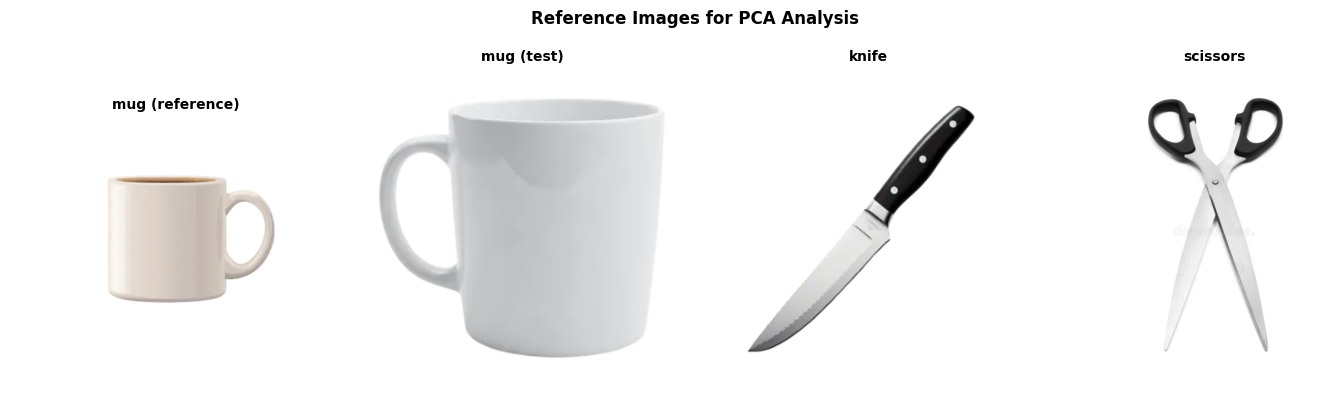

In [ ]:
from PIL import Image
import os

img_dir = f'{REPO_DIR}/data/pca_reference_images'

raw_files = {
    'mug_ref.png':  f'{img_dir}/mug1.webp',
    'mug_test.png': f'{img_dir}/mug2.webp',
    'knife.png':    f'{img_dir}/knife.webp',
    'scissors.png': f'{img_dir}/scissors-6378708.webp',
}

for out_name, src_path in raw_files.items():
    img = Image.open(src_path).convert('RGBA')
    # Paste onto white background to remove transparency
    background = Image.new('RGB', img.size, (255, 255, 255))
    background.paste(img, mask=img.split()[3])  # use alpha as mask
    out_path = f'{img_dir}/{out_name}'
    background.save(out_path)
    print(f"✅ Saved {out_name}")

# Verify they look right
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
labels = ['mug (reference)', 'mug (test)', 'knife', 'scissors']
files  = ['mug_ref.png', 'mug_test.png', 'knife.png', 'scissors.png']

for ax, label, fname in zip(axes, labels, files):
    ax.imshow(mpimg.imread(f'{img_dir}/{fname}'))
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle('Reference Images for PCA Analysis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

✅ mug_ref.png
✅ mug_test.png
✅ knife.png
✅ scissors.png


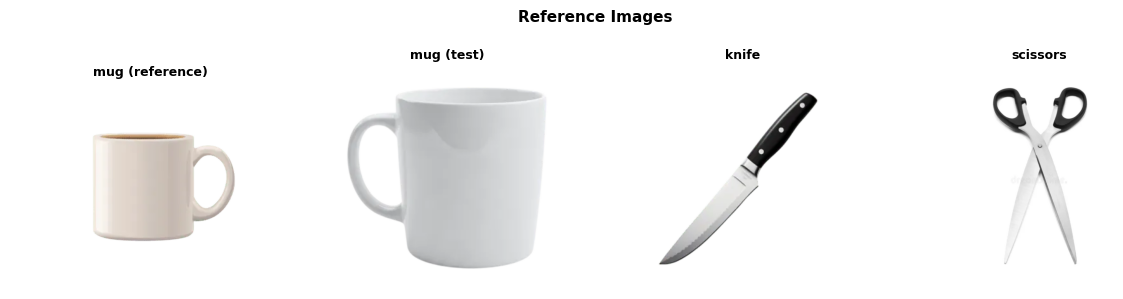

In [ ]:
from PIL import Image
import os, shutil
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img_dir = f'{REPO_DIR}/data/pca_reference_images'
os.makedirs(img_dir, exist_ok=True)

# ── Convert webp → PNG with white background ───────────────────────────────
raw_files = {
    'mug_ref.png':  f'{img_dir}/mug1.webp',
    'mug_test.png': f'{img_dir}/mug2.webp',
    'knife.png':    f'{img_dir}/knife.webp',
    'scissors.png': f'{img_dir}/scissors-6378708.webp',
}

for out_name, src_path in raw_files.items():
    img = Image.open(src_path).convert('RGBA')
    bg  = Image.new('RGB', img.size, (255, 255, 255))
    bg.paste(img, mask=img.split()[3])
    bg.save(f'{img_dir}/{out_name}')
    print(f"✅ {out_name}")

# ── Verify source images look correct ─────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
entries = [
    ('mug (reference)', 'mug_ref.png'),
    ('mug (test)',      'mug_test.png'),
    ('knife',          'knife.png'),
    ('scissors',       'scissors.png'),
]
for ax, (label, fname) in zip(axes, entries):
    ax.imshow(mpimg.imread(f'{img_dir}/{fname}'))
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.axis('off')
plt.suptitle('Reference Images', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
2026-04-22 03:32:25.077289: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-22 03:32:25.096248: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776828745.119243   22684 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776828745.126812   22684 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to regis

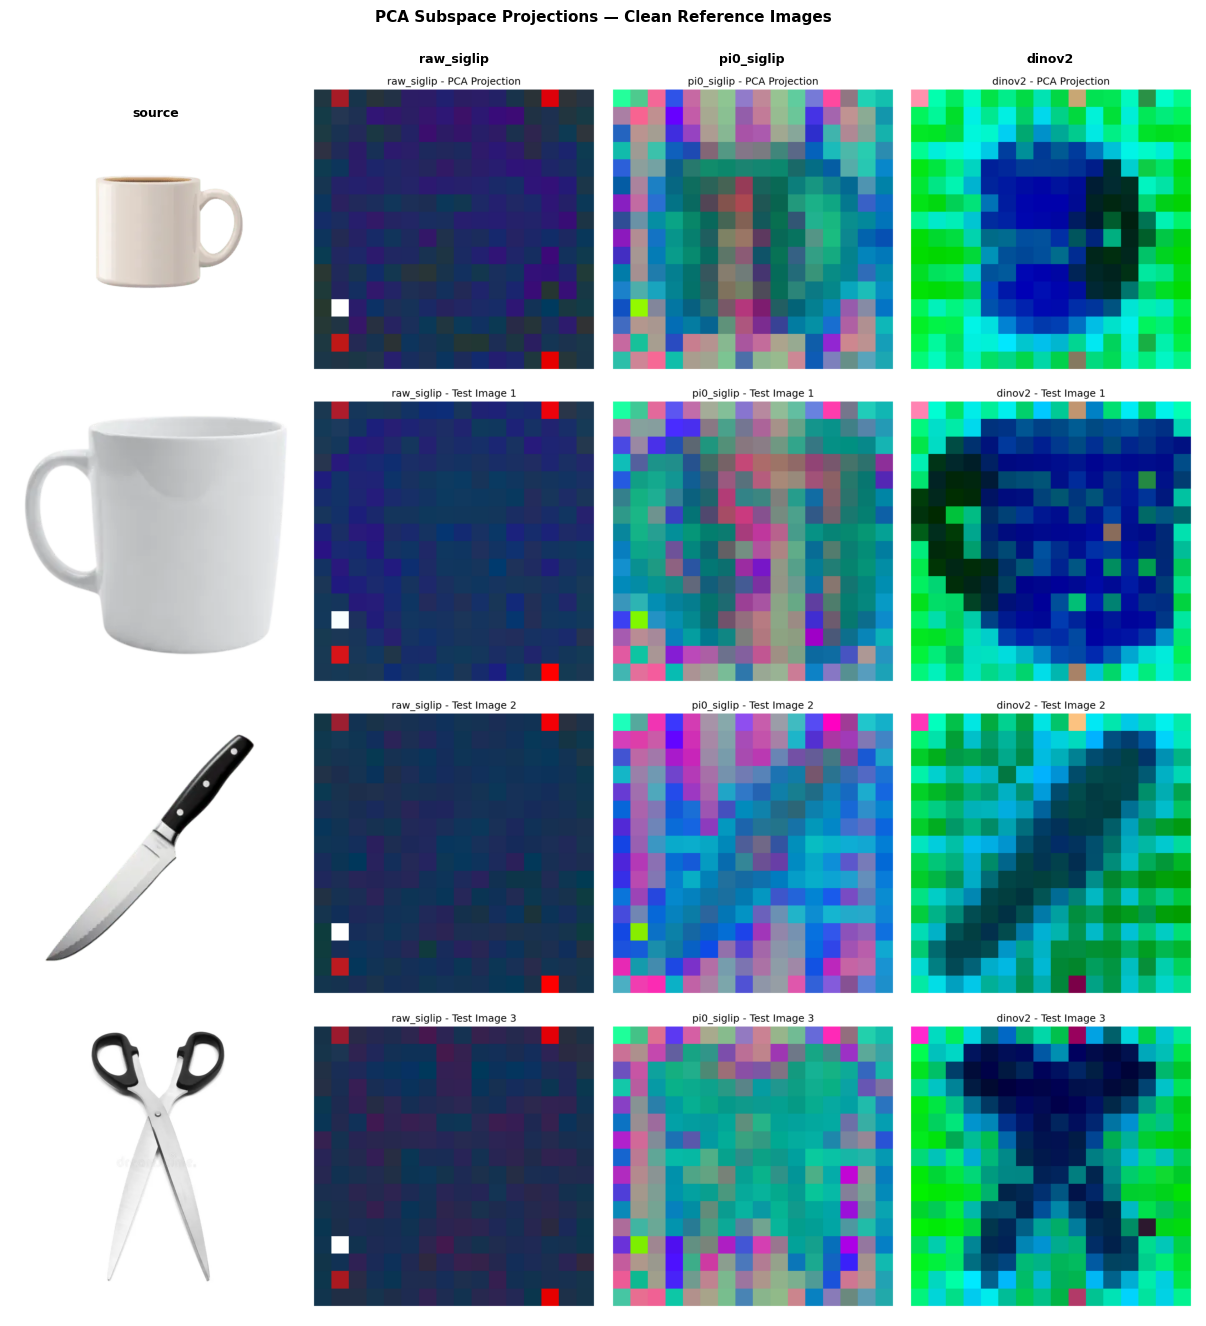

✅ Grid saved to Drive: /content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance/results/figures/clean/pca_clean_grid.png


In [ ]:
# ── Run PCA ───────────────────────────────────────────────────────────────
FIGURES_CLEAN = f'{REPO_DIR}/results/figures/clean'
os.makedirs(FIGURES_CLEAN, exist_ok=True)

REF   = f'{img_dir}/mug_ref.png'
TEST1 = f'{img_dir}/mug_test.png'
TEST2 = f'{img_dir}/knife.png'
TEST3 = f'{img_dir}/scissors.png'

os.chdir(REPO_DIR)
!python scripts/04_run_pca_analysis.py \
    --reference_image "{REF}" \
    --test_images "{TEST1}" "{TEST2}" "{TEST3}" \
    --figures_dir "{FIGURES_CLEAN}" \
    --encoders raw_siglip pi0_siglip dinov2

# ── Verify figures saved to Drive ─────────────────────────────────────────
saved = sorted(os.listdir(FIGURES_CLEAN))
print(f"\n{len(saved)} figures saved:")
for f in saved:
    print(f"  {f}")

# ── Display grid: source image + 3 encoder PCA projections ────────────────
source_map = {
    'mug\n(reference)': (REF,   'reference'),
    'mug\n(test)':      (TEST1, 'test_0'),
    'knife':            (TEST2, 'test_1'),
    'scissors':         (TEST3, 'test_2'),
}
encoders = ['raw_siglip', 'pi0_siglip', 'dinov2']

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(12, 13))

for row_idx, (row_label, (src_path, img_key)) in enumerate(source_map.items()):
    # Col 0: source image
    ax = axes[row_idx][0]
    ax.imshow(Image.open(src_path).convert('RGB'))
    ax.axis('off')
    ax.set_ylabel(row_label, fontsize=9, rotation=90, labelpad=8, va='center')
    if row_idx == 0:
        ax.set_title('source', fontsize=9, fontweight='bold')

    # Cols 1-3: PCA per encoder
    for col_idx, encoder in enumerate(encoders):
        ax = axes[row_idx][col_idx + 1]
        fpath = f'{FIGURES_CLEAN}/pca_{encoder}_{img_key}.png'
        ax.imshow(mpimg.imread(fpath))
        ax.axis('off')
        if row_idx == 0:
            ax.set_title(encoder, fontsize=9, fontweight='bold')

plt.suptitle('PCA Subspace Projections — Clean Reference Images',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout(pad=0.5)

save_path = f'{FIGURES_CLEAN}/pca_clean_grid.png'
plt.savefig(save_path, bbox_inches='tight', dpi=120)
plt.show()
print(f"✅ Grid saved to Drive: {save_path}")

In [ ]:
import os

cache_dir = os.path.expanduser("~/.cache/huggingface/hub")
if os.path.exists(cache_dir):
    for model_dir in sorted(os.listdir(cache_dir)):
        size = sum(
            os.path.getsize(os.path.join(root, f))
            for root, dirs, files in os.walk(os.path.join(cache_dir, model_dir))
            for f in files
        ) / 1e9
        print(f"  {model_dir}: {size:.2f} GB")
else:
    print("No HF cache found — models will re-download")

No HF cache found — models will re-download


Grid: 35×46 = 1610 patches | Device: cuda
Images loaded at (644, 490)

Loading raw_siglip...


config.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:805: UserWarning: Not enough free disk space to download the file. The expected file size is: 3509.55 MB. The target location /content/drive/MyDrive/VLA_Affordance_Project/hf_cache/models--google--siglip-so400m-patch14-224/blobs only has 2641.89 MB free disk space.
  )


model.safetensors:   0%|          | 0.00/3.51G [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]


  raw_siglip  |  35×46  |  1610 patches
  Extracting reference...
  Feature matrix: (1610, 4608)
  Variance ratios: [0.228 0.127 0.07 ]
  Test 1/3...
  Test 2/3...
  Test 3/3...

Loading dinov2...


config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]


  dinov2  |  35×46  |  1610 patches
  Extracting reference...
  Feature matrix: (1610, 3072)
  Variance ratios: [0.546 0.09  0.048]
  Test 1/3...
  Test 2/3...
  Test 3/3...

Encoder                 PC1    PC2    PC3  224×224 PC1  Δ
raw_siglip            0.228  0.127  0.070        0.281  -0.053  ✅ distributed
dinov2                0.546  0.090  0.048        0.404  +0.142  ⚡ moderate


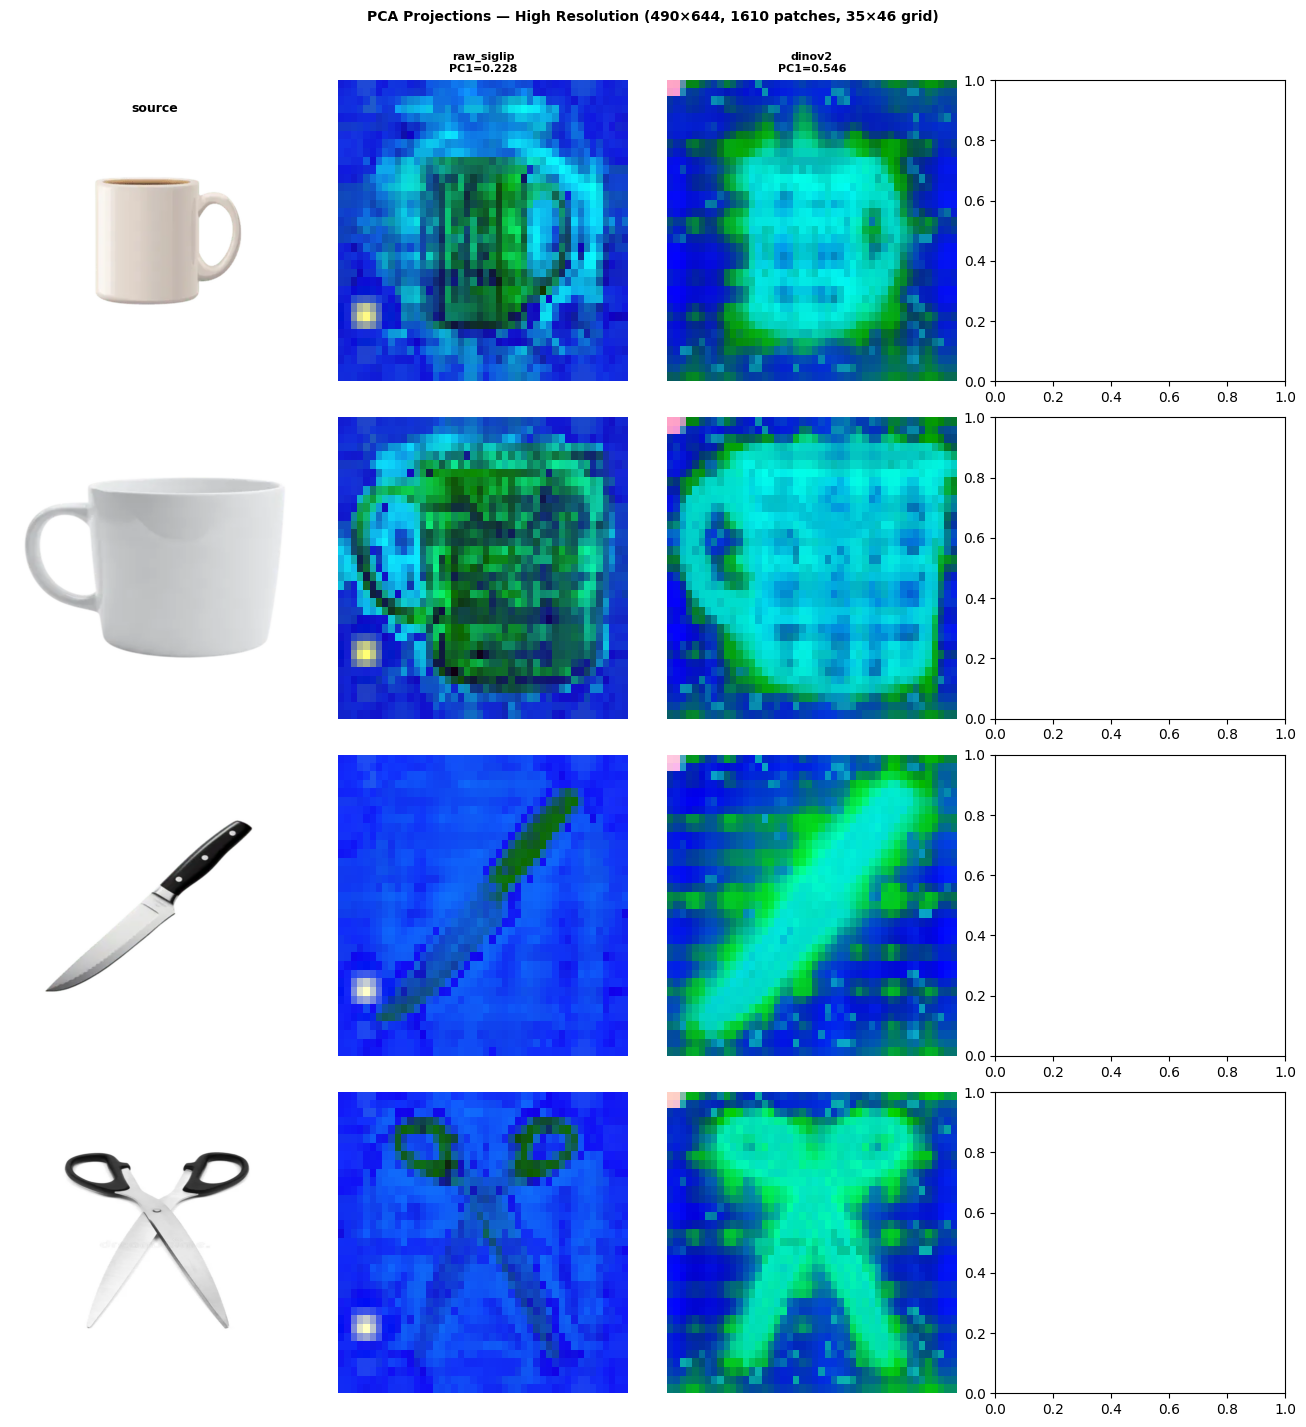


✅ Saved: /content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance/results/figures/hires/pca_hires_grid.png


In [ ]:
import torch, numpy as np, os, sys
from PIL import Image
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import torchvision.transforms.functional as TF

sys.path.insert(0, REPO_DIR)
from encoders.feature_extractor import UnifiedFeatureExtractor

# ── Config ─────────────────────────────────────────────────────────
PATCH_SIZE   = 14
IMG_H, IMG_W = 490, 644    # → 35×46 = 1610 patches (matches slides)
N_COMPONENTS = 3
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"
FIGURES_HIRES = f'{REPO_DIR}/results/figures/hires'
os.makedirs(FIGURES_HIRES, exist_ok=True)
H_grid = IMG_H // PATCH_SIZE   # 35
W_grid = IMG_W // PATCH_SIZE   # 46
N_patches = H_grid * W_grid    # 1610

print(f"Grid: {H_grid}×{W_grid} = {N_patches} patches | Device: {DEVICE}")

# ── Load images at target resolution ──────────────────────────────
img_dir = f'{REPO_DIR}/data/pca_reference_images'

def load_img(path):
    return Image.open(path).convert("RGB").resize(
        (IMG_W, IMG_H), Image.LANCZOS)  # PIL resize takes (W, H)

ref_image   = load_img(f'{img_dir}/mug_ref.png')
test_images = [
    load_img(f'{img_dir}/mug_test.png'),
    load_img(f'{img_dir}/knife.png'),
    load_img(f'{img_dir}/scissors.png'),
]
source_labels = ['mug (reference)', 'mug (test)', 'knife', 'scissors']
print(f"Images loaded at {ref_image.size}")  # should be (644, 490)

# ── Feature extraction at high resolution ─────────────────────────
def extract_hires_hidden(model, processor, image, device, encoder_type):
    """Override processor size and extract hidden states."""
    # Override size — handle both SigLIP and DINOv2 processor quirks
    processor.size = {"height": IMG_H, "width": IMG_W}
    if hasattr(processor, 'crop_size'):
        processor.crop_size = {"height": IMG_H, "width": IMG_W}
    if hasattr(processor, 'do_center_crop'):
        processor.do_center_crop = False

    inputs = processor(images=[image], return_tensors="pt").to(device)

    # Manual resize fallback if processor still outputs wrong size
    actual = tuple(inputs['pixel_values'].shape[-2:])
    if actual != (IMG_H, IMG_W):
        inputs['pixel_values'] = TF.resize(
            inputs['pixel_values'], [IMG_H, IMG_W]
        )
        print(f"  ↳ Manual resize applied → {tuple(inputs['pixel_values'].shape[-2:])}")

    with torch.no_grad():
        if encoder_type == "siglip":
            outputs = model(**inputs, return_dict=True,
                           output_hidden_states=True,
                           interpolate_pos_encoding=True)
        else:
            outputs = model(**inputs, return_dict=True,
                           output_hidden_states=True)

    return outputs.hidden_states


def hidden_to_flat(hidden_states, encoder_type):
    """Fuse 4 probe layers → (N_patches, C_fused) numpy array."""
    if encoder_type == "siglip":
        probe_indices = [6, 13, 20, 26]
        layers = [hidden_states[i][0] for i in probe_indices]
    else:
        probe_indices = [3, 6, 8, 11]
        layers = [hidden_states[i][0, 1:, :] for i in probe_indices]  # skip CLS

    fused = torch.cat(layers, dim=-1).cpu().numpy()  # (N_patches, C_fused)
    return fused


def run_pca_hires(model, processor, encoder_type, encoder_name):
    """Full PCA pipeline at high resolution."""
    print(f"\n{'='*55}")
    print(f"  {encoder_name}  |  {H_grid}×{W_grid}  |  {N_patches} patches")
    print(f"{'='*55}")

    # Reference
    print("  Extracting reference...")
    ref_hidden = extract_hires_hidden(
        model, processor, ref_image, DEVICE, encoder_type)
    ref_flat = hidden_to_flat(ref_hidden, encoder_type)
    print(f"  Feature matrix: {ref_flat.shape}")

    # Fit PCA
    pca = PCA(n_components=N_COMPONENTS, svd_solver='randomized')
    pca.fit(ref_flat)
    print(f"  Variance ratios: {pca.explained_variance_ratio_.round(3)}")

    ref_proj = pca.transform(ref_flat).reshape(H_grid, W_grid, N_COMPONENTS)

    # Test images
    test_projs = []
    for i, test_img in enumerate(test_images):
        print(f"  Test {i+1}/{len(test_images)}...")
        test_hidden = extract_hires_hidden(
            model, processor, test_img, DEVICE, encoder_type)
        test_flat = hidden_to_flat(test_hidden, encoder_type)
        proj = pca.transform(test_flat).reshape(H_grid, W_grid, N_COMPONENTS)
        test_projs.append(proj)

    return ref_proj, test_projs, pca.explained_variance_ratio_


# ── Run PCA for each encoder ───────────────────────────────────────
encoders_to_run = {
    "raw_siglip": "siglip",
    # "pi0_siglip":  "siglip",
    "dinov2":      "dinov2",
}

all_results    = {}
variance_table = {}

for encoder_name, encoder_type in encoders_to_run.items():
    print(f"\nLoading {encoder_name}...")
    ext       = UnifiedFeatureExtractor(encoder_name, device=DEVICE)
    model     = ext.model
    processor = ext.processor

    ref_proj, test_projs, var_ratios = run_pca_hires(
        model, processor, encoder_type, encoder_name)

    all_results[encoder_name]    = (ref_proj, test_projs, var_ratios)
    variance_table[encoder_name] = var_ratios

    del ext, model
    torch.cuda.empty_cache()


# ── Variance comparison table ──────────────────────────────────────
print("\n" + "="*65)
print(f"{'Encoder':<20} {'PC1':>6} {'PC2':>6} {'PC3':>6}  {'224×224 PC1':>11}  Δ")
print("="*65)
lowres = {'raw_siglip': 0.281, 'pi0_siglip': 0.821, 'dinov2': 0.404}
for enc, ratios in variance_table.items():
    delta = ratios[0] - lowres[enc]
    flag  = "⚠️  COLLAPSED" if ratios[0] > 0.70 else \
            "⚡ moderate"   if ratios[0] > 0.35 else "✅ distributed"
    print(f"{enc:<20} {ratios[0]:>6.3f} {ratios[1]:>6.3f} "
          f"{ratios[2]:>6.3f}  {lowres[enc]:>11.3f}  "
          f"{delta:+.3f}  {flag}")
print("="*65)


# ── Visualize ─────────────────────────────────────────────────────
def to_rgb(proj):
    rgb = proj.copy().astype(np.float32)
    for c in range(3):
        lo, hi = rgb[:,:,c].min(), rgb[:,:,c].max()
        rgb[:,:,c] = (rgb[:,:,c]-lo)/(hi-lo+1e-6)
    return rgb

all_source = [ref_image] + test_images
encoders   = list(all_results.keys())

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(13, 14))

for row_idx, (row_label, src_img) in enumerate(
        zip(source_labels, all_source)):

    # Col 0: source image
    ax = axes[row_idx][0]
    ax.imshow(src_img)
    ax.axis('off')
    ax.set_ylabel(row_label, fontsize=8, rotation=90,
                  labelpad=8, va='center')
    if row_idx == 0:
        ax.set_title('source', fontsize=9, fontweight='bold')

    # Cols 1-3: PCA projections
    for col_idx, enc_name in enumerate(encoders):
        ax = axes[row_idx][col_idx + 1]
        ref_proj, test_projs, _ = all_results[enc_name]
        proj = ref_proj if row_idx == 0 else test_projs[row_idx-1]
        ax.imshow(to_rgb(proj), interpolation='nearest', aspect='auto')
        ax.axis('off')
        if row_idx == 0:
            r = variance_table[enc_name]
            ax.set_title(
                f"{enc_name}\nPC1={r[0]:.3f}",
                fontsize=8, fontweight='bold')

plt.suptitle(
    f'PCA Projections — High Resolution '
    f'({IMG_H}×{IMG_W}, {N_patches} patches, {H_grid}×{W_grid} grid)',
    fontsize=10, fontweight='bold', y=1.01)
plt.tight_layout(pad=0.5)

save_path = f'{FIGURES_HIRES}/pca_hires_grid.png'
plt.savefig(save_path, bbox_inches='tight', dpi=120)
plt.show()
print(f"\n✅ Saved: {save_path}")

In [ ]:
# ── Run PCA for pi0_siglip only ───────────────────────────────────
print("Loading pi0_siglip...")
ext       = UnifiedFeatureExtractor("pi0_siglip", device=DEVICE)
model     = ext.model
processor = ext.processor

ref_proj_pi0, test_projs_pi0, var_ratios_pi0 = run_pca_hires(
    model, processor, "siglip", "pi0_siglip")

all_results["pi0_siglip"]    = (ref_proj_pi0, test_projs_pi0, var_ratios_pi0)
variance_table["pi0_siglip"] = var_ratios_pi0

del ext, model
torch.cuda.empty_cache()
print("✅ pi0_siglip done")

Loading pi0_siglip...
The PI0 model is a direct port of the OpenPI implementation. 
This implementation follows the original OpenPI structure for compatibility. 
Original implementation: https://github.com/Physical-Intelligence/openpi


config.json: 0.00B [00:00, ?B/s]

Loading model from: lerobot/pi0_base


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:805: UserWarning: Not enough free disk space to download the file. The expected file size is: 14005.62 MB. The target location /content/drive/MyDrive/VLA_Affordance_Project/hf_cache/models--lerobot--pi0_base/blobs only has 2641.60 MB free disk space.
  )


model.safetensors:   0%|          | 0.00/14.0G [00:00<?, ?B/s]

✓ Loaded state dict from model.safetensors
Remapped 777 state dict keys
	Missing key(s) in state_dict: "model.paligemma_with_expert.paligemma.model.language_model.embed_tokens.weight". 


preprocessor_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]


  pi0_siglip  |  35×46  |  1610 patches
  Extracting reference...
  Feature matrix: (1610, 4608)
  Variance ratios: [0.198 0.129 0.114]
  Test 1/3...
  Test 2/3...
  Test 3/3...
✅ pi0_siglip done



Encoder                 PC1    PC2    PC3  224×224       Δ
raw_siglip            0.228  0.127  0.070    0.281  -0.053  ✅ distributed
dinov2                0.546  0.090  0.048    0.404  +0.142  ⚡ moderate
pi0_siglip            0.198  0.129  0.114    0.821  -0.623  ✅ distributed


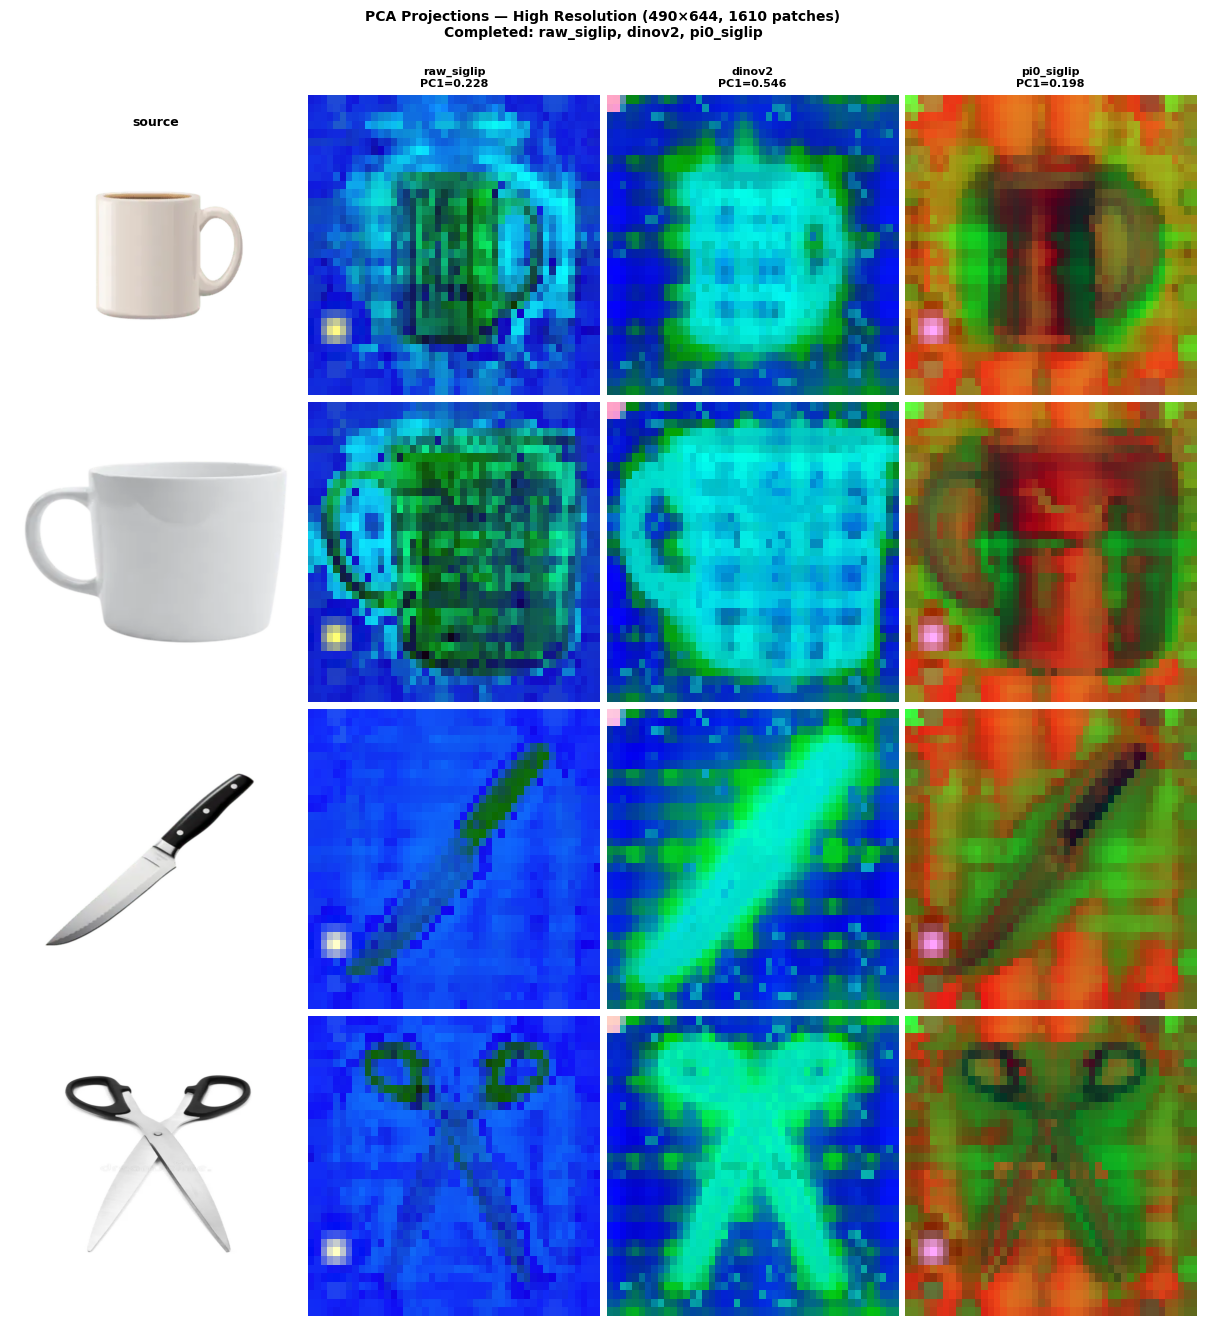


✅ Saved: /content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance/results/figures/hires/pca_hires_grid.png


In [ ]:
# ── Visualize all completed encoders ──────────────────────────────
completed  = list(all_results.keys())
all_source = [ref_image] + test_images
n_encoders = len(completed)

fig, axes = plt.subplots(
    nrows=4, ncols=n_encoders+1,
    figsize=(3*(n_encoders+1), 13)
)

for row_idx, (row_label, src_img) in enumerate(
        zip(source_labels, all_source)):

    # Col 0: source image
    ax = axes[row_idx][0]
    ax.imshow(src_img)
    ax.axis('off')
    ax.set_ylabel(row_label, fontsize=8, rotation=90,
                  labelpad=8, va='center')
    if row_idx == 0:
        ax.set_title('source', fontsize=9, fontweight='bold')

    # Remaining cols: one per completed encoder
    for col_idx, enc_name in enumerate(completed):
        ax = axes[row_idx][col_idx+1]
        ref_proj, test_projs, _ = all_results[enc_name]
        proj = ref_proj if row_idx == 0 else test_projs[row_idx-1]
        ax.imshow(to_rgb(proj), interpolation='nearest', aspect='auto')
        ax.axis('off')
        if row_idx == 0:
            r = variance_table[enc_name]
            ax.set_title(
                f"{enc_name}\nPC1={r[0]:.3f}",
                fontsize=8, fontweight='bold')

# Print variance table
print("\n" + "="*65)
print(f"{'Encoder':<20} {'PC1':>6} {'PC2':>6} {'PC3':>6}  "
      f"{'224×224':>7}  {'Δ':>6}")
print("="*65)
lowres = {'raw_siglip': 0.281, 'pi0_siglip': 0.821, 'dinov2': 0.404}
for enc in completed:
    r     = variance_table[enc]
    delta = r[0] - lowres.get(enc, 0)
    flag  = "⚠️  COLLAPSED"  if r[0] > 0.70 else \
            "⚡ moderate"    if r[0] > 0.35 else \
            "✅ distributed"
    print(f"{enc:<20} {r[0]:>6.3f} {r[1]:>6.3f} {r[2]:>6.3f}  "
          f"{lowres.get(enc,0):>7.3f}  {delta:>+6.3f}  {flag}")
print("="*65)

plt.suptitle(
    f'PCA Projections — High Resolution '
    f'({IMG_H}×{IMG_W}, {N_patches} patches)\n'
    f'Completed: {", ".join(completed)}',
    fontsize=10, fontweight='bold', y=1.01)
plt.tight_layout(pad=0.5)

save_path = f'{FIGURES_HIRES}/pca_hires_grid.png'
plt.savefig(save_path, bbox_inches='tight', dpi=120)
plt.show()
print(f"\n✅ Saved: {save_path}")

In [ ]:
# ── Load UMD images at high resolution ────────────────────────────
umd_ref = load_img(
    f'{DATA_PATH}/part-affordance-dataset/tools/mug_01/mug_01_00000050_rgb.jpg'
)
umd_tests = [
    load_img(f'{DATA_PATH}/part-affordance-dataset/tools/mug_02/mug_02_00000050_rgb.jpg'),
    load_img(f'{DATA_PATH}/part-affordance-dataset/tools/knife_01/knife_01_00000050_rgb.jpg'),
    load_img(f'{DATA_PATH}/part-affordance-dataset/tools/scissors_01/scissors_01_00000050_rgb.jpg'),
]
umd_labels = ['mug_01 (reference)', 'mug_02', 'knife_01', 'scissors_01']

# ── Load DINOv2 ────────────────────────────────────────────────────
print("Loading DINOv2...")
ext       = UnifiedFeatureExtractor("dinov2", device=DEVICE)
model     = ext.model
processor = ext.processor

# ── Extract features directly on UMD images ────────────────────────
H_grid = IMG_H // PATCH_SIZE   # 35
W_grid = IMG_W // PATCH_SIZE   # 46
N_patches = H_grid * W_grid    # 1610

print("Extracting reference (UMD mug)...")
ref_hidden = extract_hires_hidden(model, processor, umd_ref, DEVICE, "dinov2")
ref_flat   = hidden_to_flat(ref_hidden, "dinov2")

pca_umd = PCA(n_components=3, svd_solver='randomized')
pca_umd.fit(ref_flat)
print(f"Variance ratios: {pca_umd.explained_variance_ratio_.round(3)}")

umd_ref_proj = pca_umd.transform(ref_flat).reshape(H_grid, W_grid, 3)

umd_test_projs = []
for i, test_img in enumerate(umd_tests):
    print(f"Extracting test {i+1}/3...")
    hidden = extract_hires_hidden(model, processor, test_img, DEVICE, "dinov2")
    flat   = hidden_to_flat(hidden, "dinov2")
    proj   = pca_umd.transform(flat).reshape(H_grid, W_grid, 3)
    umd_test_projs.append(proj)

del ext, model
torch.cuda.empty_cache()
print("✅ Done")

Loading DINOv2...
Extracting reference (UMD mug)...
Variance ratios: [0.518 0.056 0.035]
Extracting test 1/3...
Extracting test 2/3...
Extracting test 3/3...
✅ Done


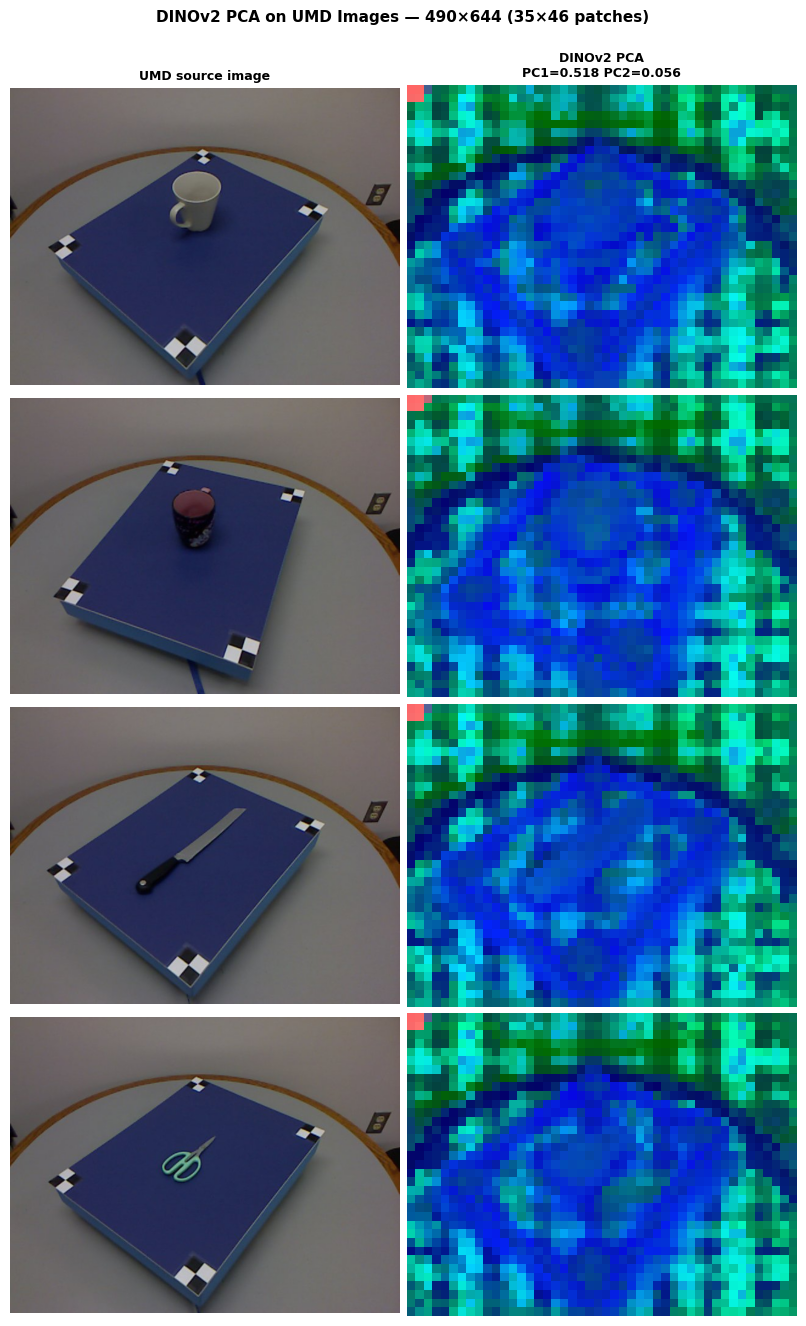

✅ Saved: /content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance/results/figures/hires/pca_dinov2_umd.png


In [ ]:
all_umd_source = [umd_ref] + umd_tests
all_umd_projs  = [umd_ref_proj] + umd_test_projs

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(8, 13))

for row_idx, (label, src_img, proj) in enumerate(
        zip(umd_labels, all_umd_source, all_umd_projs)):

    # Col 0: actual UMD image
    ax = axes[row_idx][0]
    ax.imshow(src_img)
    ax.axis('off')
    ax.set_ylabel(label, fontsize=8, rotation=90, labelpad=8, va='center')
    if row_idx == 0:
        ax.set_title('UMD source image', fontsize=9, fontweight='bold')

    # Col 1: DINOv2 PCA projection
    ax = axes[row_idx][1]
    ax.imshow(to_rgb(proj), interpolation='nearest', aspect='auto')
    ax.axis('off')
    if row_idx == 0:
        r = pca_umd.explained_variance_ratio_
        ax.set_title(
            f'DINOv2 PCA\nPC1={r[0]:.3f} PC2={r[1]:.3f}',
            fontsize=9, fontweight='bold')

plt.suptitle(
    f'DINOv2 PCA on UMD Images — {IMG_H}×{IMG_W} ({H_grid}×{W_grid} patches)',
    fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout(pad=0.5)

save_path = f'{FIGURES_HIRES}/pca_dinov2_umd.png'
plt.savefig(save_path, bbox_inches='tight', dpi=120)
plt.show()
print(f"✅ Saved: {save_path}")

In [ ]:
# ── Run PCA on UMD images for all 3 encoders ──────────────────────
encoders_umd = {
    "raw_siglip": "siglip",
    "pi0_siglip":  "siglip",
    "dinov2":      "dinov2",
}

umd_results = {}  # encoder_name -> (ref_proj, test_projs, variance_ratios)

for encoder_name, encoder_type in encoders_umd.items():
    print(f"\nLoading {encoder_name}...")
    ext       = UnifiedFeatureExtractor(encoder_name, device=DEVICE)
    model     = ext.model
    processor = ext.processor

    print(f"  Extracting reference...")
    ref_hidden = extract_hires_hidden(model, processor, umd_ref, DEVICE, encoder_type)
    ref_flat   = hidden_to_flat(ref_hidden, encoder_type)

    pca = PCA(n_components=3, svd_solver='randomized')
    pca.fit(ref_flat)
    print(f"  Variance: {pca.explained_variance_ratio_.round(3)}")

    ref_proj = pca.transform(ref_flat).reshape(H_grid, W_grid, 3)

    test_projs = []
    for i, test_img in enumerate(umd_tests):
        print(f"  Test {i+1}/3...")
        hidden = extract_hires_hidden(model, processor, test_img, DEVICE, encoder_type)
        flat   = hidden_to_flat(hidden, encoder_type)
        test_projs.append(pca.transform(flat).reshape(H_grid, W_grid, 3))

    umd_results[encoder_name] = (ref_proj, test_projs, pca.explained_variance_ratio_)

    del ext, model
    torch.cuda.empty_cache()
    print(f"  ✅ {encoder_name} done")

In [ ]:
# ── Visualize: source + 3 encoder PCA projections ─────────────────
all_umd_source = [umd_ref] + umd_tests
encoders       = list(umd_results.keys())

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(13, 14))

for row_idx, (label, src_img) in enumerate(
        zip(umd_labels, all_umd_source)):

    # Col 0: source image
    ax = axes[row_idx][0]
    ax.imshow(src_img)
    ax.axis('off')
    ax.set_ylabel(label, fontsize=8, rotation=90, labelpad=8, va='center')
    if row_idx == 0:
        ax.set_title('UMD source', fontsize=9, fontweight='bold')

    # Cols 1-3: PCA per encoder
    for col_idx, enc_name in enumerate(encoders):
        ax = axes[row_idx][col_idx + 1]
        ref_proj, test_projs, ratios = umd_results[enc_name]
        proj = ref_proj if row_idx == 0 else test_projs[row_idx - 1]
        ax.imshow(to_rgb(proj), interpolation='nearest', aspect='auto')
        ax.axis('off')
        if row_idx == 0:
            ax.set_title(
                f'{enc_name}\nPC1={ratios[0]:.3f}',
                fontsize=8, fontweight='bold')

plt.suptitle(
    f'PCA on UMD Images — {IMG_H}×{IMG_W} ({H_grid}×{W_grid} patches)',
    fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout(pad=0.5)

save_path = f'{FIGURES_HIRES}/pca_umd_all_encoders.png'
plt.savefig(save_path, bbox_inches='tight', dpi=120)
plt.show()
print(f"✅ Saved: {save_path}")

In [ ]:
umd_results['dinov2'] = (umd_ref_proj, umd_test_projs, pca_umd.explained_variance_ratio_)
print("✅ DINOv2 added to umd_results")
print("Available:", list(umd_results.keys()))

✅ DINOv2 added to umd_results
Available: ['raw_siglip', 'dinov2']


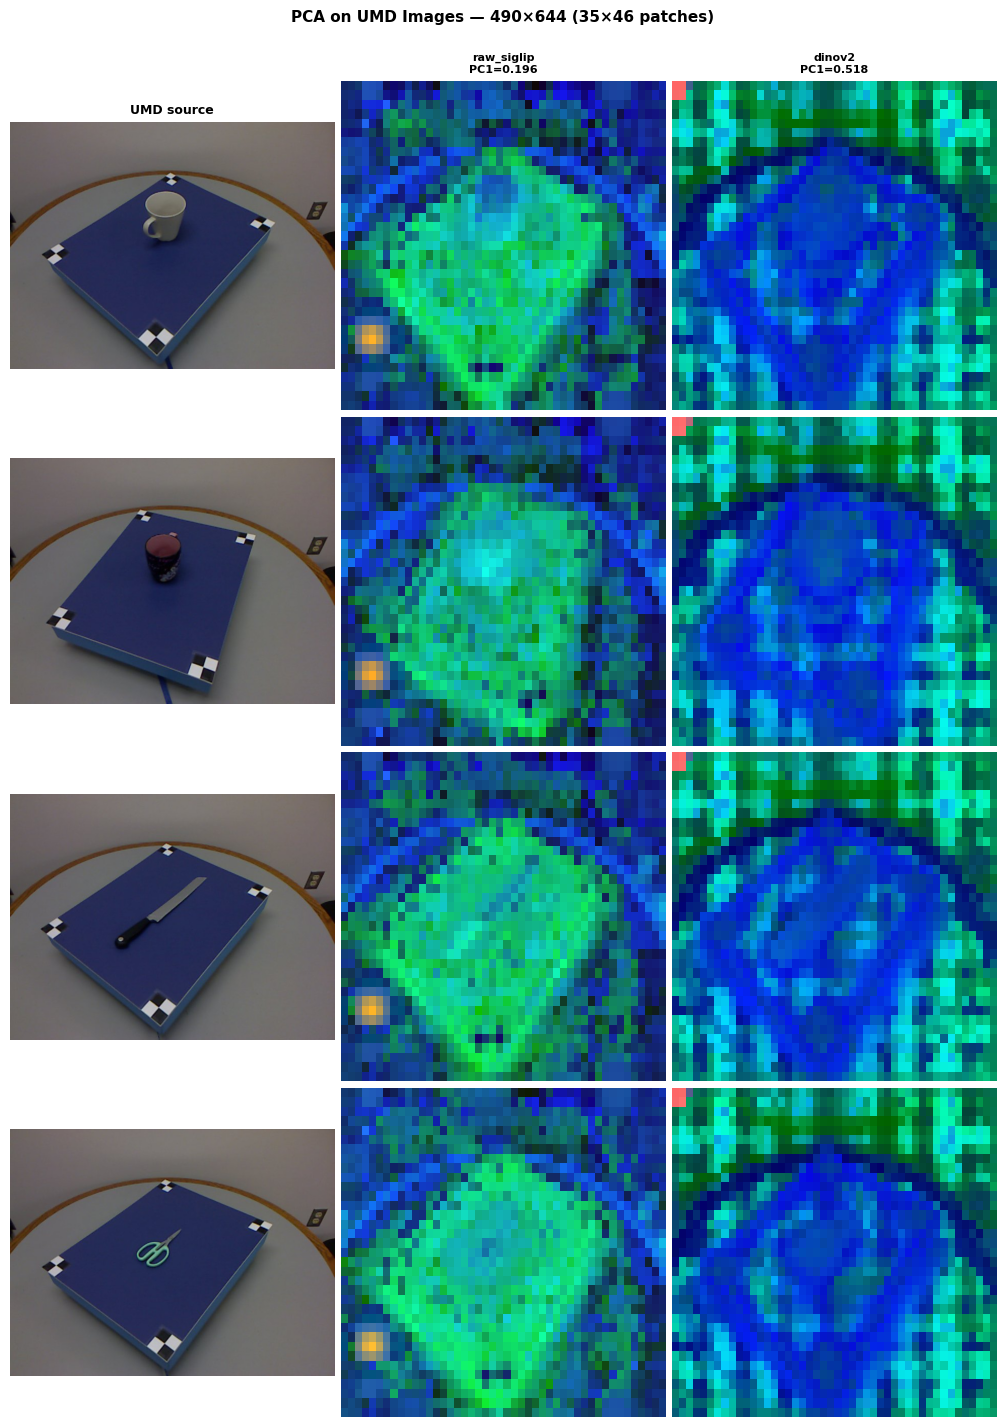

✅ Saved: /content/drive/MyDrive/VLA_Affordance_Project/VLA-affordance/results/figures/hires/pca_umd_siglip_dinov2.png


In [ ]:
# ── Just raw_siglip and dinov2 — already extracted above ──────────
encoders_to_show = ["raw_siglip", "dinov2"]

all_umd_source = [umd_ref] + umd_tests

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(10, 14))

for row_idx, (label, src_img) in enumerate(
        zip(umd_labels, all_umd_source)):

    # Col 0: source image
    ax = axes[row_idx][0]
    ax.imshow(src_img)
    ax.axis('off')
    ax.set_ylabel(label, fontsize=8, rotation=90, labelpad=8, va='center')
    if row_idx == 0:
        ax.set_title('UMD source', fontsize=9, fontweight='bold')

    # Cols 1-2: raw_siglip and dinov2
    for col_idx, enc_name in enumerate(encoders_to_show):
        ax = axes[row_idx][col_idx + 1]
        ref_proj, test_projs, ratios = umd_results[enc_name]
        proj = ref_proj if row_idx == 0 else test_projs[row_idx - 1]
        ax.imshow(to_rgb(proj), interpolation='nearest', aspect='auto')
        ax.axis('off')
        if row_idx == 0:
            ax.set_title(
                f'{enc_name}\nPC1={ratios[0]:.3f}',
                fontsize=8, fontweight='bold')

plt.suptitle(
    f'PCA on UMD Images — {IMG_H}×{IMG_W} ({H_grid}×{W_grid} patches)',
    fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout(pad=0.5)

save_path = f'{FIGURES_HIRES}/pca_umd_siglip_dinov2.png'
plt.savefig(save_path, bbox_inches='tight', dpi=120)
plt.show()
print(f"✅ Saved: {save_path}")

This generates the PCA subspace visualizations. Output goes to results/figures/.

Script 05 — Extract Depth/Normal Features

In [ ]:
os.chdir(REPO_DIR)
!python scripts/05_extract_depth_normal.py

Runs DPT depth + surface normal estimation over the dataset. This also caches to disk.

Script 06 — Depth Augmentation Experiment

In [ ]:
os.chdir(REPO_DIR)
!python scripts/06_run_depth_augmentation.py

Target: DINOv2's mIoU delta with depth/normals should be ~0 (confirming its inherent geometric priors). SigLIP variants may show larger deltas.

Script 07 — Weight Divergence

In [ ]:
os.chdir(REPO_DIR)
!python scripts/07_weight_divergence.py

Computes L2/cosine distance between raw SigLIP → PaliGemma → π0 → π0.5 weight checkpoints. Minimal divergence = finding in itself (encoder barely changes during VLA fine-tuning).

Cell 20: Script 08 — Generate Final Report

In [ ]:
os.chdir(REPO_DIR)
!python scripts/08_generate_report.py

The Survival Pattern (Memorize This)
Every time you start a new session:

Select A100 runtime
Run Cell 1 (mount Drive)
Run Cell 2 (set working directory)
Run Cell 3 (git pull latest from teammates)
Run Cells 5–8 (reinstall dependencies — takes ~3 min)
Run Cell 9 (HF login)
Skip Cells 10–12 if already done (dataset and config persist in Drive)
Skip Cells 13–14 if features are already cached (they're in Drive)
Jump to whatever script you need

1.   Verify encoders load correctly 2 min
2.   Extract + cache all features 30-40 min
3.   Linear probing (mIoU) 15-20 min
4.   PCA visualization 5 min
5.   Extract depth/normals 20 min
6.   Depth augmentation experiment 10 min
7.   Weight divergence analysis 5 min
8.   Generate final report 2 min